# Building Energy Performance Through Machine Learning

In the context of climate change and rising energy demands, designing energy-efficient residential buildings has become a critical challenge — especially in regions with hot-summer humid subtropical climates like the Köppen Cfa zone, where high cooling needs are often accompanied by significant heating demands during colder periods. Architects and engineers face the complex task of balancing multiple design variables to minimize energy consumption without compromising comfort or cost.

While multi-objective optimization algorithms such as NSGA-II can identify Pareto-optimal solutions for building performance, they do not inherently explain which architectural parameters most influence energy outcomes or how these variables interact. This creates a gap between technical results and practical decision-making in early-stage design.

Research Question: Which architectural design parameters, most significantly impact heating and cooling energy demand in residential buildings under Cfa climate conditions? 

Context: This analysis is based on a dataset generated during my doctoral research, consisting of 480,000 simulated residential building configurations optimized using the NSGA-II evolutionary algorithm. The dataset includes the following architectural variables:

Building shape (L or H)
Window-to-Wall Ratio (WWR: 10, 15, 20 and 25%)
Insulation thickness by orientation (north, south, east, west): use of rockwoll (mm)
Uvalue for each wall orientation and the overall (W/m2K)
Roof insulation thickness: use of rockwoll (mm)
Uvalue from the roof (W/m2K)
Solar absorptance of walls and roof (without unit: goes by more dark colors or brigdet)
Glazing thickness (single glass - mm)
Natural ventilation setpoint (AFN - C)

For each configuration, the simulation outputs two primary energy performance indicators: Heating demand (kWh/m²·year) and Cooling demand (kWh/m²·year).

Main Objective: is to go beyond optimization and build interpretable predictive models that reveal:

Which design parameters have the greatest influence on energy use and in more details the Uvalues that impact the most.Capture non-linear effects and synergies, quantify variable importance rigorously, provide intuitive explanations for model predictions. This approach bridges the gap between computational design and real-world application, supporting faster, evidence-based decision-making in sustainable architecture.

Main Goals:
This project is structured around three clear objectives:

1. Understand the Data
Perform exploratory data analysis (EDA) to visualize distributions, correlations, and the Pareto front of optimal solutions.
2. Build Predictive Models
Train and predict heating and cooling demands from architectural inputs.
3. Derive Actionable Insights
Apply SHAP (SHapley Additive exPlanations) to interpret model predictions, identifying which parameters and interactions drive energy performance.

# 1) Import libraries

In [5]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import os
import plotly
import plotly.express as px
import matplotlib.colors as mcolors
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from scipy.stats import shapiro
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess  
import warnings

warnings.filterwarnings("ignore")

# 2) Loading data

In [6]:
# The main rute from the files (the archive has to be in the same directory that is the notebook)
ruta = "Database_Pareto Front" # Adjusted 

def converter_float(valor):
    try:
        return float(str(valor).replace(",", ".").strip())
    except:
        return valor

pareto_front = {}

for subruta, _, archivos in os.walk(ruta):
    for archivo in archivos:
        if archivo.endswith(".csv"):
            caminho_arquivo = os.path.join(subruta, archivo)
            nome_base = os.path.splitext(archivo)[0]

            try:
                df = pd.read_csv(caminho_arquivo, sep=";")

                for col in df.columns:
                    if col != "Shape":
                        df[col] = df[col].apply(converter_float)

                # Here the main difference, because we have two files in the directory Database_Pareto Front.
                if "H" in subruta:
                    df["Shape"] = "H"
                elif "L" in subruta:
                    df["Shape"] = "L"

                pareto_front[nome_base] = df

            except Exception as e:
                print(f"Erro ao ler {archivo}: {e}")

optimizations = pd.concat(pareto_front.values(), ignore_index=True)

print(pareto_front.keys())

dict_keys(['22072025_HW10', '22072025_HW15', '22072025_HW20', '30072025_HW25', '22072025_LW10', '22072025_LW15', '22072025_LW20', '22072025_LW25'])


In [7]:
optimizations

,ID_Optimization,Gen,WWR,Shape,IT North,Unorth,IT South,Usouth,IT East,Ueast,...,Uwall,IT Roof,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Cooling demand,Heating demand,Total demand
0,HW10_01,0.0,0.10,H,0.030,0.96,0.000,2.50,0.004,2.09,...,2.16,0.005,1.85,0.23,0.20,0.004,22.01,28.29,19.70,47.99
1,HW10_02,1.0,0.10,H,0.136,0.29,0.141,0.30,0.147,0.27,...,0.36,0.145,0.27,0.75,0.66,0.009,24.58,59.75,0.38,60.13
2,HW10_03,2.0,0.10,H,0.030,0.95,0.008,1.80,0.007,1.88,...,1.82,0.004,1.90,0.24,0.25,0.005,22.00,29.66,16.48,46.14
3,HW10_04,3.0,0.10,H,0.118,0.33,0.131,0.30,0.150,0.27,...,0.38,0.149,0.27,0.58,0.64,0.009,24.99,57.98,0.48,58.46
4,HW10_05,4.0,0.10,H,0.149,0.27,0.091,0.40,0.149,0.27,...,0.37,0.132,0.30,0.55,0.79,0.010,22.88,47.45,0.50,47.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,LW25_33,32.0,0.25,L,0.080,0.46,0.091,0.41,0.020,1.20,...,0.56,0.132,0.30,0.28,0.27,0.007,22.25,32.59,2.20,34.79
316,LW25_34,33.0,0.25,L,0.146,0.28,0.133,0.30,0.134,0.30,...,0.29,0.136,0.29,0.59,0.74,0.009,24.37,68.06,0.63,68.69
317,LW25_35,34.0,0.25,L,0.042,0.75,0.086,0.44,0.016,1.34,...,0.73,0.032,0.88,0.24,0.31,0.007,21.78,28.96,6.09,35.05
318,LW25_36,35.0,0.25,L,0.144,0.28,0.092,0.41,0.052,0.64,...,0.52,0.064,0.54,0.41,0.26,0.005,22.04,32.67,2.02,34.68


# 3) Exploratory data analysis (EDA)

## Display data information

In [8]:
optimizations.info()

# Missing values:
nan = optimizations.isnull().sum() # Count the number of null values in each column.
print('NaN values per column:')
if nan.sum() == 0:
    print('Without NaN')
else:
    print(nan[nan > 0].rename('NaN').to_frame())
    print('Recommended .drpna() before modeling')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Optimization  320 non-null    object 
 1   Gen              320 non-null    float64
 2   WWR              320 non-null    float64
 3   Shape            320 non-null    object 
 4   IT North         320 non-null    float64
 5   Unorth           320 non-null    float64
 6   IT South         320 non-null    float64
 7   Usouth           320 non-null    float64
 8   IT East          320 non-null    float64
 9   Ueast            320 non-null    float64
 10  IT West          320 non-null    float64
 11  Uwest            320 non-null    float64
 12  Uwall            320 non-null    float64
 13  IT Roof          320 non-null    float64
 14  Uroof            320 non-null    float64
 15  SA Walls         320 non-null    float64
 16  SA Roof          320 non-null    float64
 17  IT Glazing      

## Basic Descriptive Statistics

In [9]:
optimizations.describe(include='all') # include all, show categorical columns.

,ID_Optimization,Gen,WWR,Shape,IT North,Unorth,IT South,Usouth,IT East,Ueast,...,Uwall,IT Roof,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Cooling demand,Heating demand,Total demand
count,320,320.000000,320.000000,320,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,...,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.00000,320.000000,320.000000
unique,320,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,LW25_21,NaN,NaN,L,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,165,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,19.693750,0.171406,NaN,0.082047,0.719406,0.083028,0.635219,0.079725,0.688125,...,0.749313,0.089759,0.576469,0.375594,0.401531,0.006525,22.196594,38.40175,7.090156,45.491844
std,NaN,11.877112,0.056570,NaN,0.053477,0.574184,0.046165,0.490344,0.046878,0.519613,...,0.443985,0.047744,0.435955,0.190079,0.186762,0.002267,1.159900,12.01198,12.590559,12.518048
min,NaN,0.000000,0.100000,NaN,0.000000,0.270000,0.000000,0.270000,0.000000,0.270000,...,0.270000,0.000000,0.270000,0.200000,0.200000,0.003000,18.390000,22.47000,0.060000,31.630000
25%,NaN,9.750000,0.100000,NaN,0.029750,0.300000,0.042000,0.310000,0.034000,0.330000,...,0.380000,0.047000,0.300000,0.220000,0.250000,0.004000,21.720000,30.03750,0.650000,35.872500
50%,NaN,19.500000,0.150000,NaN,0.083000,0.450000,0.086000,0.435000,0.085000,0.450000,...,0.585000,0.102000,0.370000,0.290000,0.325000,0.007000,22.080000,34.44000,2.140000,40.900000
75%,NaN,29.250000,0.200000,NaN,0.135000,0.962500,0.127250,0.702500,0.118000,0.882500,...,1.035000,0.131000,0.680000,0.540000,0.522500,0.009000,22.652500,42.95750,6.782500,47.757500


## Constant variables and layout

In [10]:
# H and Linear Labels:
shape_labels = {'H': 'H Building', 'L': 'Linear Building'}

# H and Linear colors:
shape_colors = {'H': '#4CAF50', 'L': '#FF9800'}

# Cooling color:
color_cooling = '#17becf' 

# Heating color:
color_heating = '#FF6B6B' 

# Common feature lists
all_features = ['Gen', 'WWR', 'Shape','Unorth', 'Usouth', 'Ueast', 'Uwest','Uwall', 'Uroof', 'SA Walls', 'SA Roof', 
                'IT Glazing', 'Setpoint']
u_features = ['Unorth','Usouth','Ueast','Uwest','Uwall','Uroof']
targets = ['Cooling demand', 'Heating demand']
# Features without shape (for numeric only graphs)
features_without_shape = [f for f in all_features if f != 'Shape']

# Separate building shapes
H_buildings = optimizations[optimizations['Shape'] == 'H']
L_buildings = optimizations[optimizations['Shape'] == 'L']

## Boxplots by similiar variables to verify data outliers and dimensions

In [11]:
def grouped_boxplot(df, figsize_per_plot=(10, 6)):
    
    # Group by dimension:
    group = {
        'Insulation Thickness: Rockwool [mm]': ['IT North', 'IT South', 'IT East', 'IT West', 'IT Roof'],
        'Energy Demand [kWh/m²·year]': ['Cooling demand', 'Heating demand', 'Total demand'],
        'Thermal Transmittance (U-Value) [W/m²·K]': ['Unorth', 'Usouth', 'Ueast', 'Uwest', 'Uwall', 'Uroof'],
        'Setpoint Temperature [°C]': ['Setpoint'],
        'Glazing Thickness [mm]': ['IT Glazing']
    }

    for title, columns in group.items():
        exist_columns = [col for col in columns if col in df.columns]
        
        if not exist_columns:
            print(f'{title}: The columns are not finded.')
            continue
        
        dados = df[exist_columns].select_dtypes(include=[np.number]).dropna(how='all')
           
        dados_melt = dados.melt(var_name='Variable', value_name='Value')

        # Boxplots:
        plt.figure(figsize=figsize_per_plot)
        
        # Apply specific color schemes based on the group
        if title == 'Energy Demand [kWh/m²·year]':
            palette_dict = {
                'Cooling demand': color_cooling,
                'Heating demand': color_heating,
                'Total demand': 'purple'  
            }
            # Ensure all variables in the data have colors defined
            unique_vars = dados_melt['Variable'].unique()
            palette = [palette_dict.get(var, 'gray') for var in unique_vars]
            sns.boxplot(data=dados_melt, x='Variable', y='Value', palette=palette, showfliers=True)
        elif title == 'Insulation Thickness: Rockwool [mm]':
            # Monochromatic blue for insulation thickness
            sns.boxplot(data=dados_melt, x='Variable', y='Value', color='#4682B4', showfliers=True)
        elif title == 'Thermal Transmittance (U-Value) [W/m²·K]':
            # Monochromatic green for thermal transmittance
            sns.boxplot(data=dados_melt, x='Variable', y='Value', color='#32CD32', showfliers=True)
        elif title == 'Setpoint Temperature [°C]':
            # Monochromatic orange for setpoint temperature
            sns.boxplot(data=dados_melt, x='Variable', y='Value', color='#FF8C00', showfliers=True)
        elif title == 'Glazing Thickness [mm]':
            # Monochromatic purple for glazing thickness
            sns.boxplot(data=dados_melt, x='Variable', y='Value', color='#9370DB', showfliers=True)
        else:
            # Default palette for any other groups
            sns.boxplot(data=dados_melt, x='Variable', y='Value', palette='viridis', showfliers=True)
            
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Variable')
        plt.ylabel('Value') 
        plt.tight_layout()
        plt.show()

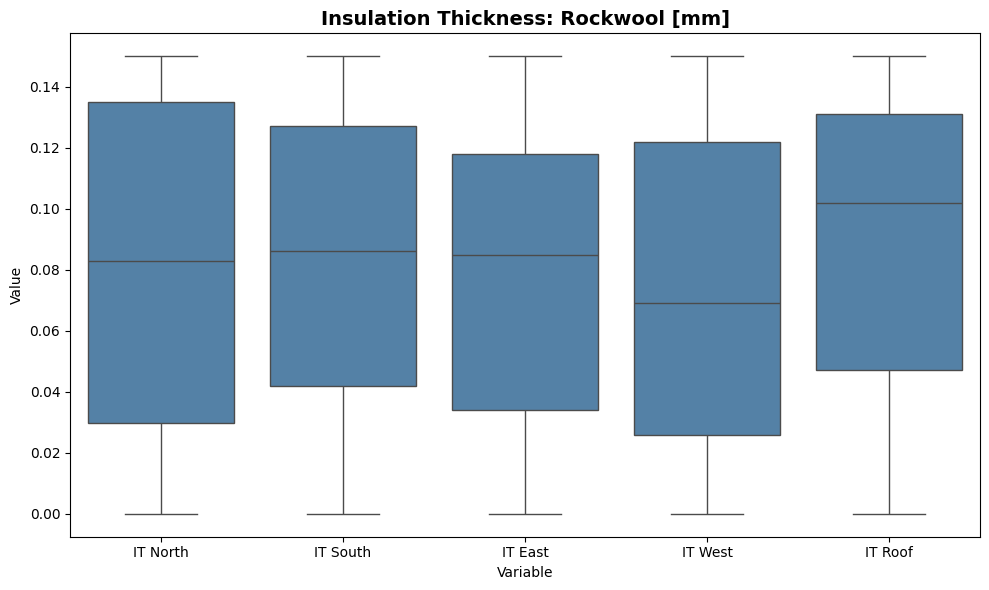

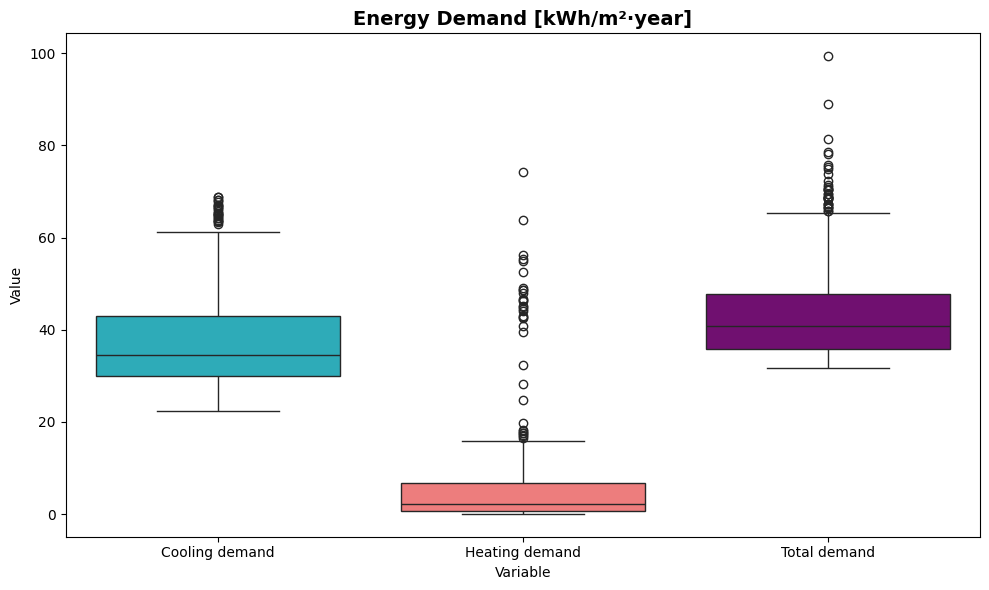

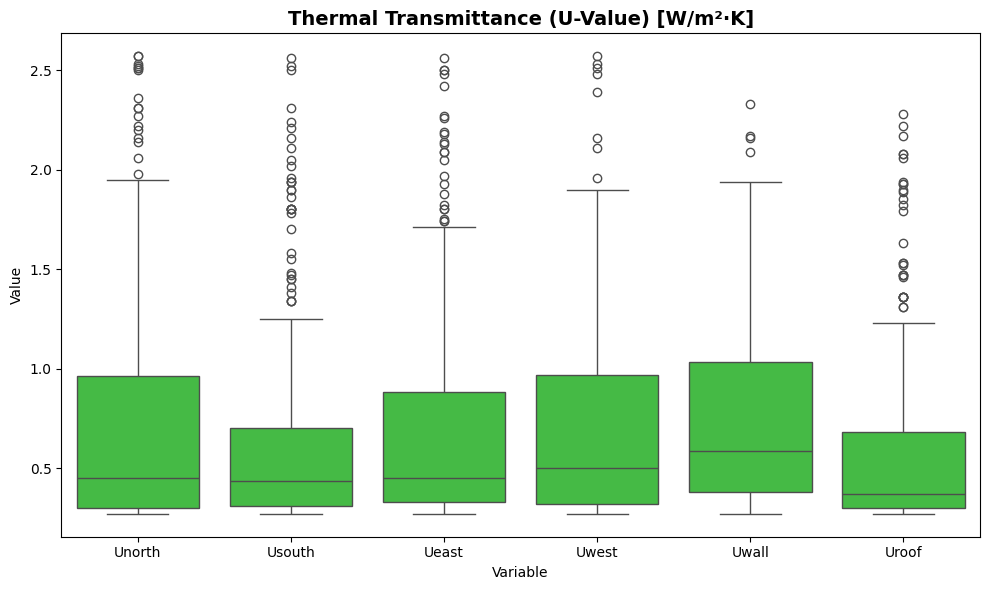

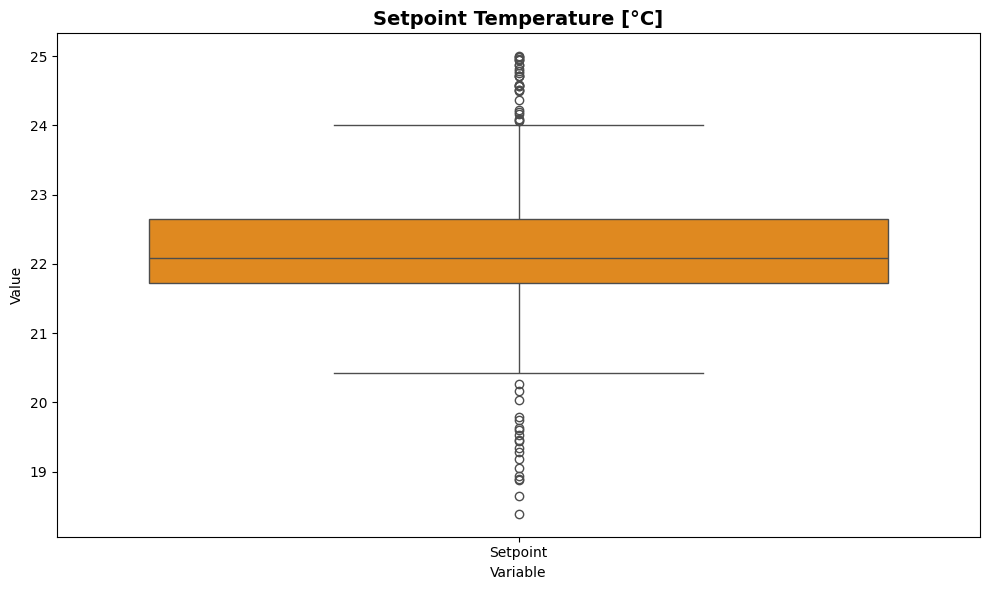

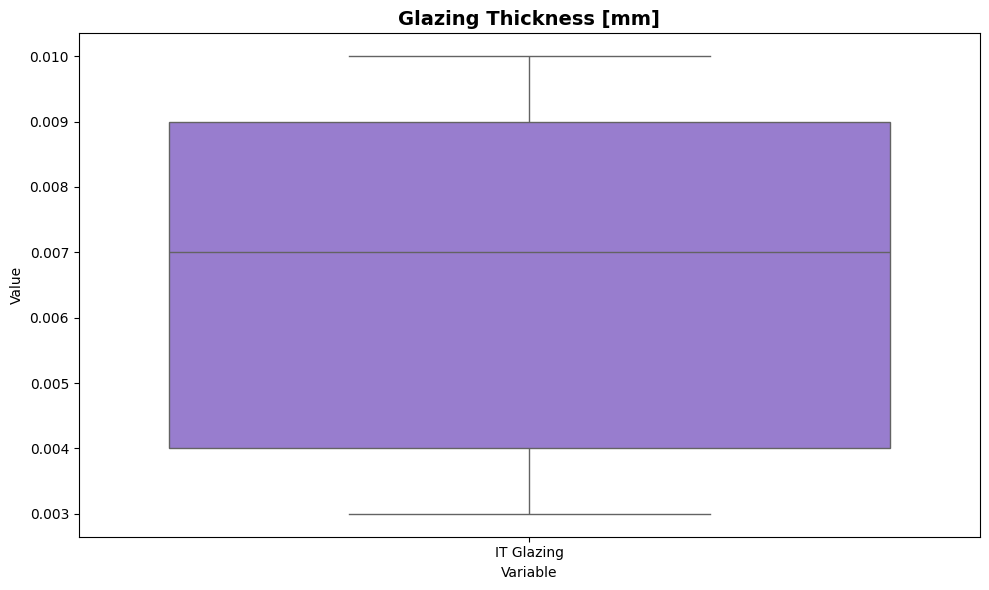

In [12]:
grouped_boxplot(optimizations, figsize_per_plot=(10, 6))

These boxplots display the statistical distribution (median, quartiles, and outliers) for key architectural variables and energy performance metrics across the entire dataset. The plots for 'Total demand' and 'Heating demand' reveal a number of significant outliers, indicating building configurations with exceptionally high energy consumption. These outliers are addressed in the subsequent data cleaning steps to prevent them from skewing the analysis. 

In [13]:
H_buildings.head()

,ID_Optimization,Gen,WWR,Shape,IT North,Unorth,IT South,Usouth,IT East,Ueast,...,Uwall,IT Roof,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Cooling demand,Heating demand,Total demand
0,HW10_01,0.0,0.1,H,0.030,0.96,0.000,2.5,0.004,2.09,...,2.16,0.005,1.85,0.23,0.20,0.004,22.01,28.29,19.70,47.99
1,HW10_02,1.0,0.1,H,0.136,0.29,0.141,0.3,0.147,0.27,...,0.36,0.145,0.27,0.75,0.66,0.009,24.58,59.75,0.38,60.13
2,HW10_03,2.0,0.1,H,0.030,0.95,0.008,1.8,0.007,1.88,...,1.82,0.004,1.90,0.24,0.25,0.005,22.00,29.66,16.48,46.14
3,HW10_04,3.0,0.1,H,0.118,0.33,0.131,0.3,0.150,0.27,...,0.38,0.149,0.27,0.58,0.64,0.009,24.99,57.98,0.48,58.46
4,HW10_05,4.0,0.1,H,0.149,0.27,0.091,0.4,0.149,0.27,...,0.37,0.132,0.30,0.55,0.79,0.010,22.88,47.45,0.50,47.94


In [14]:
L_buildings.head()

,ID_Optimization,Gen,WWR,Shape,IT North,Unorth,IT South,Usouth,IT East,Ueast,...,Uwall,IT Roof,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Cooling demand,Heating demand,Total demand
155,LW10_01,0.0,0.1,L,0.000,2.57,0.030,0.94,0.045,0.73,...,1.53,0.102,0.37,0.20,0.27,0.004,20.47,24.38,46.51,70.89
156,LW10_02,1.0,0.1,L,0.149,0.27,0.103,0.38,0.132,0.30,...,0.32,0.150,0.27,0.80,0.77,0.010,24.81,66.58,0.06,66.63
157,LW10_03,2.0,0.1,L,0.008,1.80,0.014,1.45,0.024,1.08,...,1.51,0.034,0.84,0.21,0.22,0.004,19.60,24.92,39.44,64.36
158,LW10_04,3.0,0.1,L,0.002,2.31,0.032,0.91,0.091,0.41,...,1.34,0.032,0.87,0.24,0.26,0.004,21.42,25.74,18.19,43.92
159,LW10_05,4.0,0.1,L,0.147,0.27,0.068,0.53,0.118,0.33,...,0.38,0.150,0.27,0.80,0.49,0.009,22.93,46.43,0.09,46.52


### Heating and Cooling Demands: Pareto Front solutions differenciate by shape (H and L)

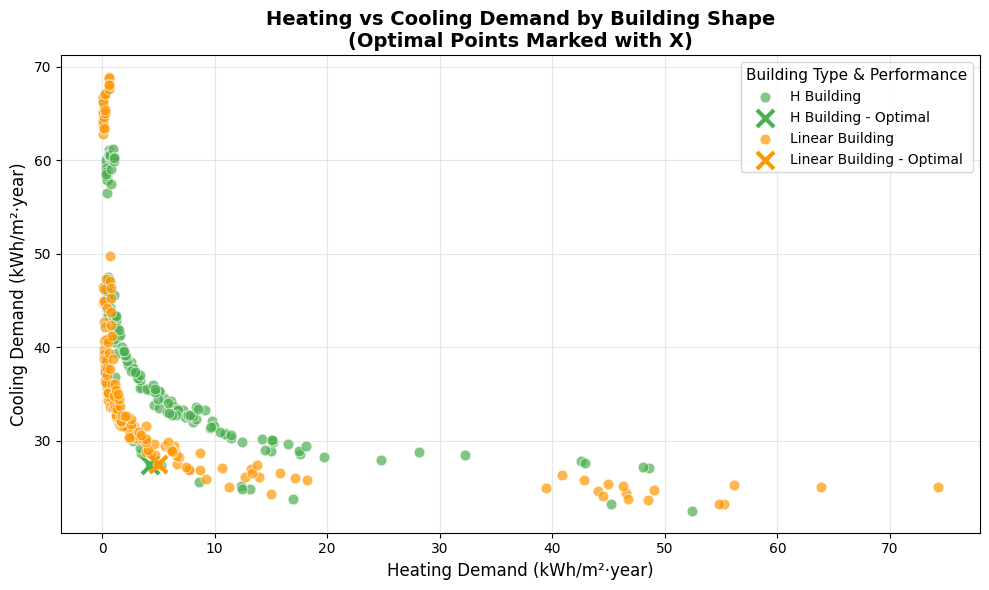

In [15]:
plt.figure(figsize=(10, 6))

# Plot each building type
for shape in optimizations['Shape'].dropna().unique():  
    subset = optimizations[optimizations['Shape'] == shape]
    label = shape_labels[shape]
    color = shape_colors[shape]
    
    # Scatter of Pareto Front points
    sns.scatterplot(
        data=subset,
        x='Heating demand',
        y='Cooling demand',
        color=color,
        alpha=0.7,
        s=60,
        label=label
    )
    
    # Pareto front that minimizes cooling and heating
    subset_copy = subset.copy()
    subset_copy['Combined_Demand'] = subset_copy['Heating demand'] + subset_copy['Cooling demand']
    best_point = subset_copy.loc[subset_copy['Combined_Demand'].idxmin()]

    plt.scatter(
        best_point['Heating demand'],
        best_point['Cooling demand'],
        color=color,           
        s=150,                 
        marker='x', 
        linewidth=3,
        edgecolor='darkred',   
        label=f"{label} - Optimal"
    )

plt.title('Heating vs Cooling Demand by Building Shape\n(Optimal Points Marked with X)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Heating Demand (kWh/m²·year)', fontsize=12)
plt.ylabel('Cooling Demand (kWh/m²·year)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.legend(title='Building Type & Performance', 
           title_fontsize=11, fontsize=10, loc='upper right', 
           frameon=True, fancybox=True, shadow=False)

plt.tight_layout()
plt.show()

H buildings demonstrates slightly better energy performance, particularly in cooling demand, while maintaining very low heating demand. Both building typologies achieve high efficiency, with optimal solutions clustered around 5–6 kWh/m²·y (heating) and 27–28 kWh/m²·y (cooling).This indicates that shape impacts thermal balance, but both designs can reach near-optimal energy performance in Cfa climates.

### Correlation between Construction Variables vs Energy Demands (Pearson vs Spearman)

### Comparison with all variables

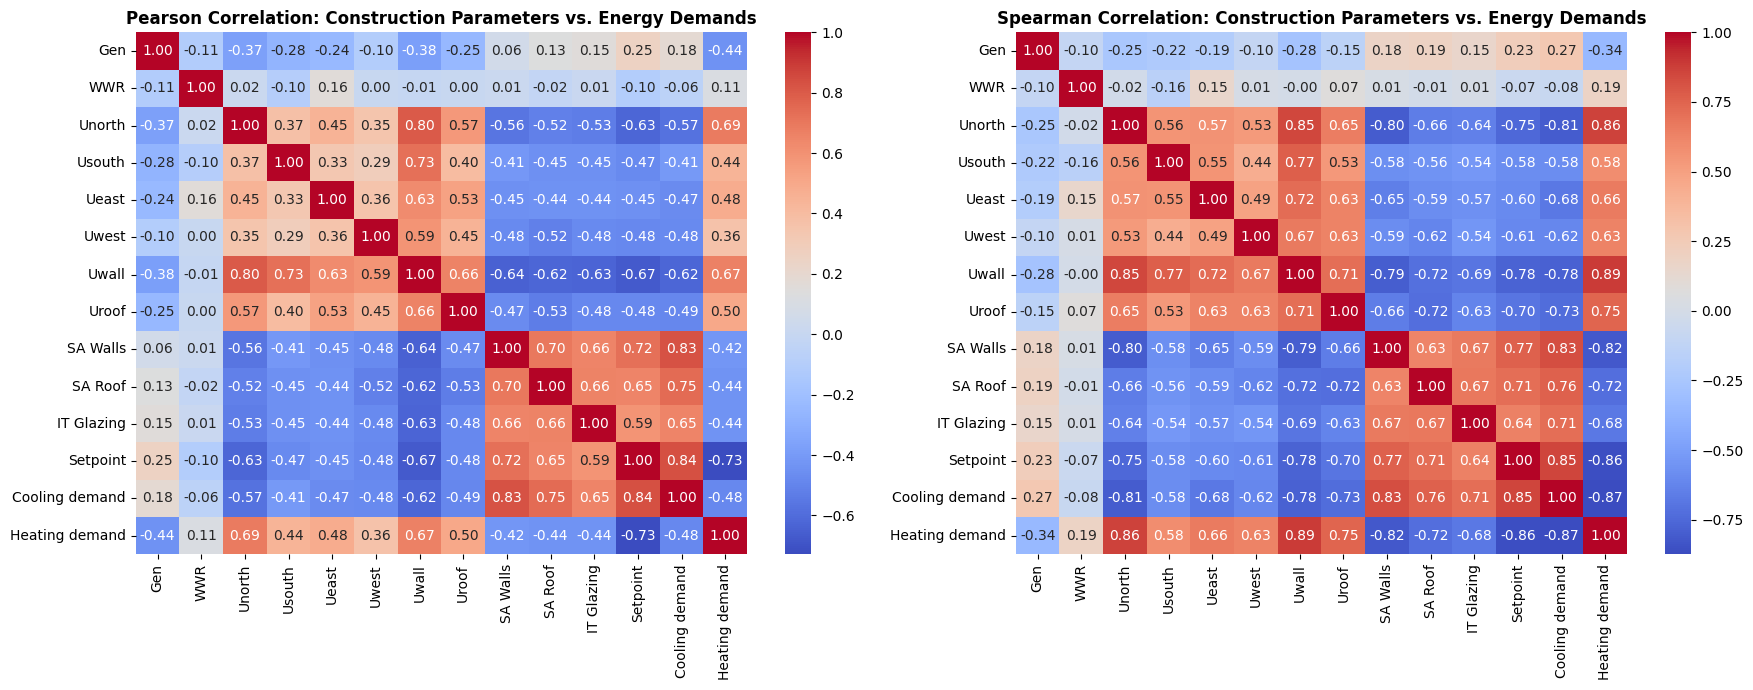

Top 5 most correlated features with Cooling demand (Pearson):
Setpoint      0.837811
SA Walls      0.828432
SA Roof       0.745263
IT Glazing    0.654267
Uwall         0.623123
Name: Cooling demand, dtype: float64
Top 5 most correlated features with Cooling demand (Spearman):
Setpoint    0.854747
SA Walls    0.827994
Unorth      0.807078
Uwall       0.783820
SA Roof     0.762651
Name: Cooling demand, dtype: float64
Top 5 most correlated features with Heating demand (Pearson):
Setpoint    0.728768
Unorth      0.686073
Uwall       0.668904
Uroof       0.501488
Ueast       0.481820
Name: Heating demand, dtype: float64
Top 5 most correlated features with Heating demand (Spearman):
Uwall       0.885647
Unorth      0.862751
Setpoint    0.859734
SA Walls    0.822712
Uroof       0.750661
Name: Heating demand, dtype: float64


In [16]:
# Calculate correlation:
corr_pearson = optimizations[features_without_shape + targets].corr(method='pearson') # Assume that all variables are normals.
corr_spearman = optimizations[features_without_shape + targets].corr(method='spearman') # capture nonlinear monotonic effects, usually better in building energy datasets.

# heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=axes[0]) 
axes[0].set_title("Pearson Correlation: Construction Parameters vs. Energy Demands", fontsize=12, fontweight="bold")

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=axes[1])
axes[1].set_title("Spearman Correlation: Construction Parameters vs. Energy Demands", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Top 5 strongest features per target (Pearson vs Spearman)
for target in targets:
    print(f"Top 5 most correlated features with {target} (Pearson):")
    print(corr_pearson[target][features_without_shape].abs().sort_values(ascending=False).head(5))

    print(f"Top 5 most correlated features with {target} (Spearman):")
    print(corr_spearman[target][features_without_shape].abs().sort_values(ascending=False).head(5))

Graphical explanation:
A way too if the relationships are strictly linear (Pearson stronger) or monotonic but nonlinear (Spearman stronger). Insulation thickness (IT) and thermal transmittance (U-value) are strongly correlated with energy demand, with higher insulation reducing both heating and cooling loads. Solar absorptance (SA) shows strong positive correlations with cooling demand, darker surfaces increase heat gain. Setpoint temperature has moderate to strong negative correlation with heating demand, indicating better control reduces heating needs.

Architectural conclusions:
Prioritize insulation on the roof and south wall for maximum energy savings. North-facing walls receive significant solar gain in summer and should be shaded, not over-insulated. This aligns with bioclimatic design principles in Cfa climates of the Southern Hemisphere: control summer overheating (via roof and northern shading) while minimizing winter heat loss (via south wall insulation).

### Spearman comparison between all variables differentiated by shape

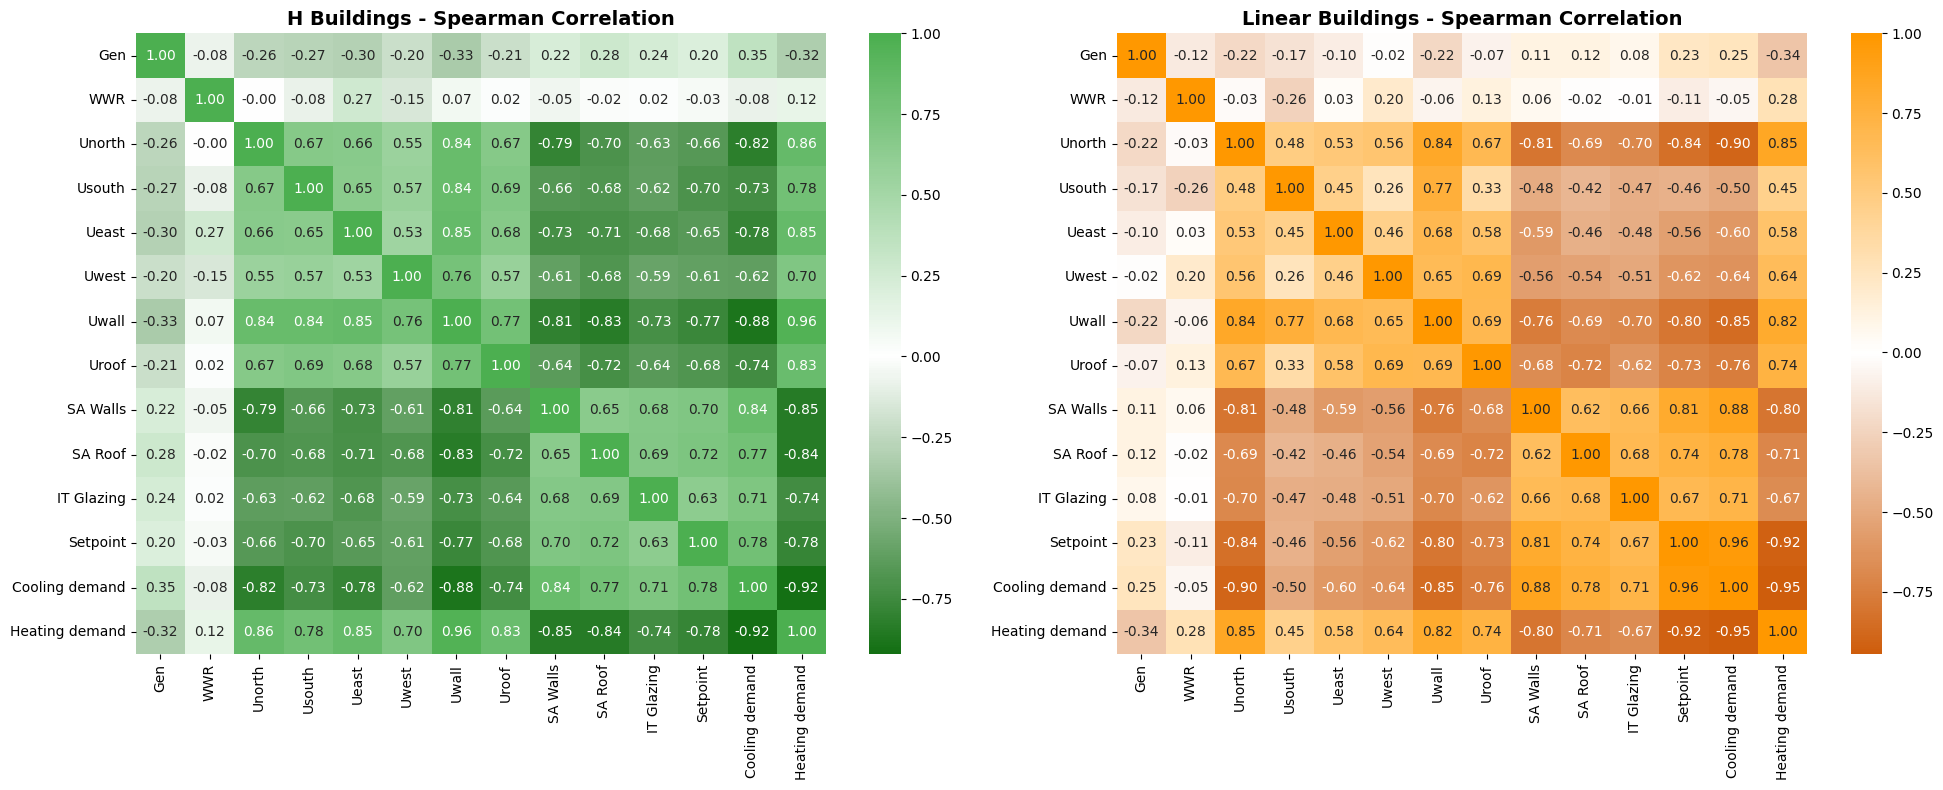

In [17]:
# H Building colormap
colors_H = ['#006400', '#ffffff', '#4CAF50'] 
custom_H_cmap = LinearSegmentedColormap.from_list('H_shape_divergent', colors_H, N=256)

# Linear colormap
colors_L = ['#CC5500', '#ffffff', '#FF9800']  
custom_L_cmap = LinearSegmentedColormap.from_list('L_shape_divergent', colors_L, N=256)

# Calculate correlations for H and Linear buildings
H_spearman = H_buildings[features_without_shape + targets].corr(method='spearman')
L_spearman = L_buildings[features_without_shape + targets].corr(method='spearman')

# H and Linear building heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(H_spearman, annot=True, fmt=".2f", cmap=custom_H_cmap, cbar=True, ax=axes[0], center=0)
axes[0].set_title("H Buildings - Spearman Correlation", fontsize=14, fontweight="bold")
sns.heatmap(L_spearman, annot=True, fmt=".2f", cmap=custom_L_cmap, cbar=True, ax=axes[1], center=0)
axes[1].set_title("Linear Buildings - Spearman Correlation", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

For H buildings higher U-values in walls and roof strongly increase cooling demand, while better insulation reduces heating needs. The north wall has a strong negative correlation with cooling demand, indicating that lower U-values (better insulation) reduce heat gain. Setpoint shows a strong positive link to cooling and negative to heating, confirming its dual role in energy use. Overall, thermal performance of the envelope dominates energy behavior, especially in controlling summer overheating.

For Linear buildings wall and roof U-values show stronger correlations with both cooling and heating demands compared to H buildings. High U-values in the north wall and walls overall significantly increase cooling load due to solar exposure and poor insulation. Setpoint has a very strong influence on both demands, higher values sharply increase cooling and decrease heating. Solar absorptance (Walls/Roof) also plays a major role, with higher values increasing cooling demand, highlighting the importance of reflective surfaces.

While both building types benefit from good insulation, linear buildings are more sensitive to envelope performance, especially in the north façade and wall/roof insulation. This suggests that passive design strategies must be tailored to shape: linear forms require tighter control over thermal transmittance and surface reflectivity to achieve energy efficiency.

### Top 5 features by shape and cooling and heating

In [18]:
comparison_data = []

for target in targets:
    H_spearman_top5 = H_spearman[target][features_without_shape].abs().sort_values(ascending=False).head(5)
    L_spearman_top5 = L_spearman[target][features_without_shape].abs().sort_values(ascending=False).head(5)
    
    # Create comparison data for this target
    target_comparison_data = []
    
    # H building comparison
    for i in range(5):
        row_data = {
            'Target': target,
            'Building_Shape': 'H',
            'Rank': i + 1,
            'Spearman_Feature': H_spearman_top5.index[i],
            'Spearman_Corr': round(H_spearman_top5.values[i], 3)
        }
        target_comparison_data.append(row_data)
        comparison_data.append(row_data)
    
    # L building comparison
    for i in range(5):
        row_data = {
            'Target': target,
            'Building_Shape': 'L',
            'Rank': i + 1,
            'Spearman_Feature': L_spearman_top5.index[i],
            'Spearman_Corr': round(L_spearman_top5.values[i], 3)
        }
        target_comparison_data.append(row_data)
        comparison_data.append(row_data)
    
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Target,Building_Shape,Rank,Spearman_Feature,Spearman_Corr
0,Cooling demand,H,1,Uwall,0.879
1,Cooling demand,H,2,SA Walls,0.839
2,Cooling demand,H,3,Unorth,0.824
3,Cooling demand,H,4,Ueast,0.784
4,Cooling demand,H,5,Setpoint,0.780
5,Cooling demand,L,1,Setpoint,0.959
6,Cooling demand,L,2,Unorth,0.899
7,Cooling demand,L,3,SA Walls,0.877
8,Cooling demand,L,4,Uwall,0.855
9,Cooling demand,L,5,SA Roof,0.778


### Top 3 most influential features (Spearman)

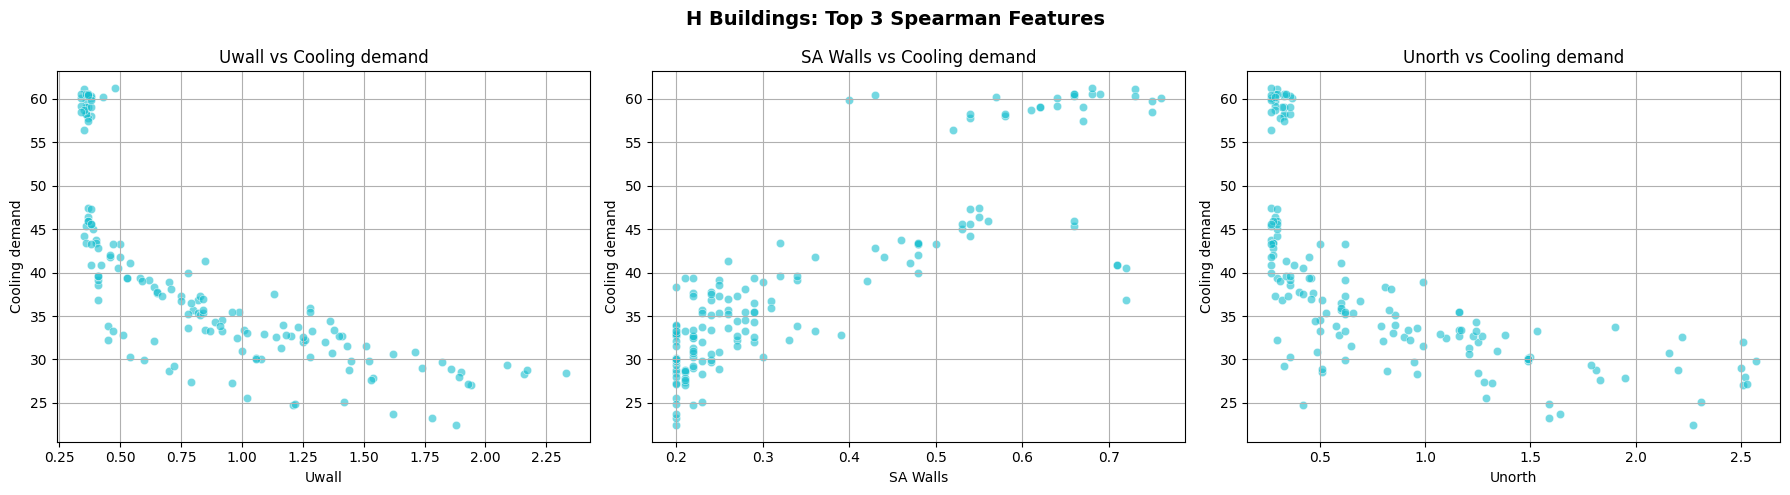

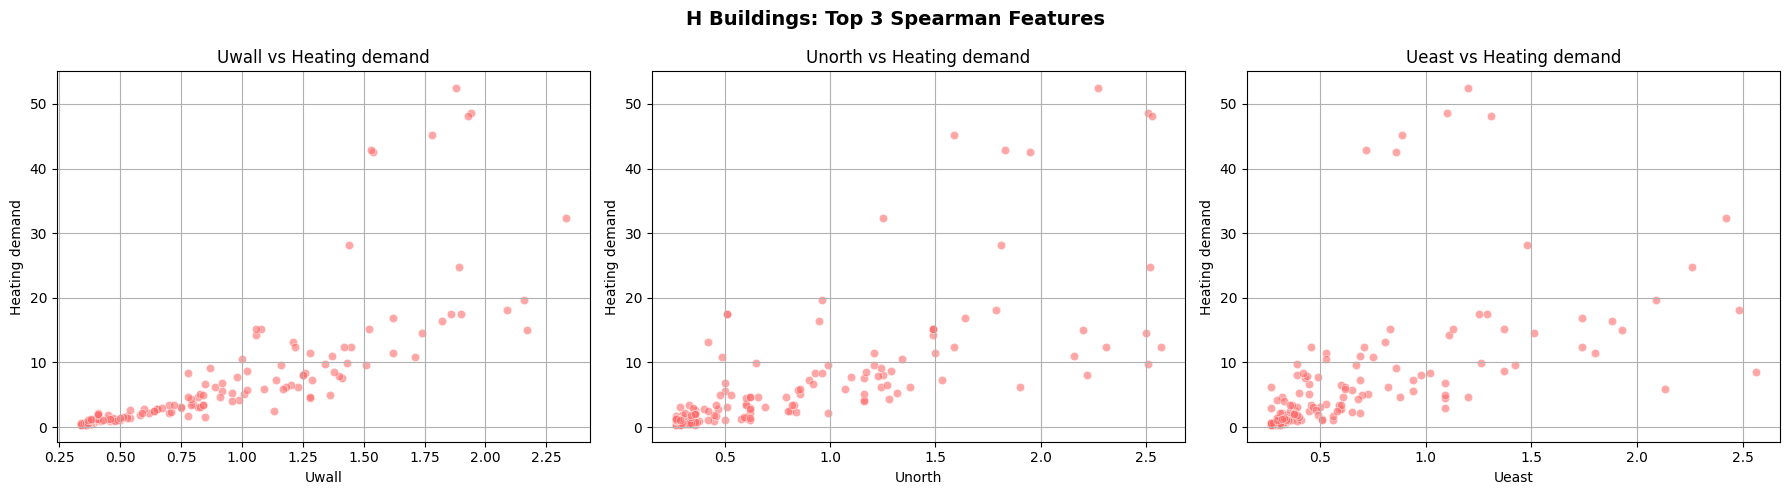

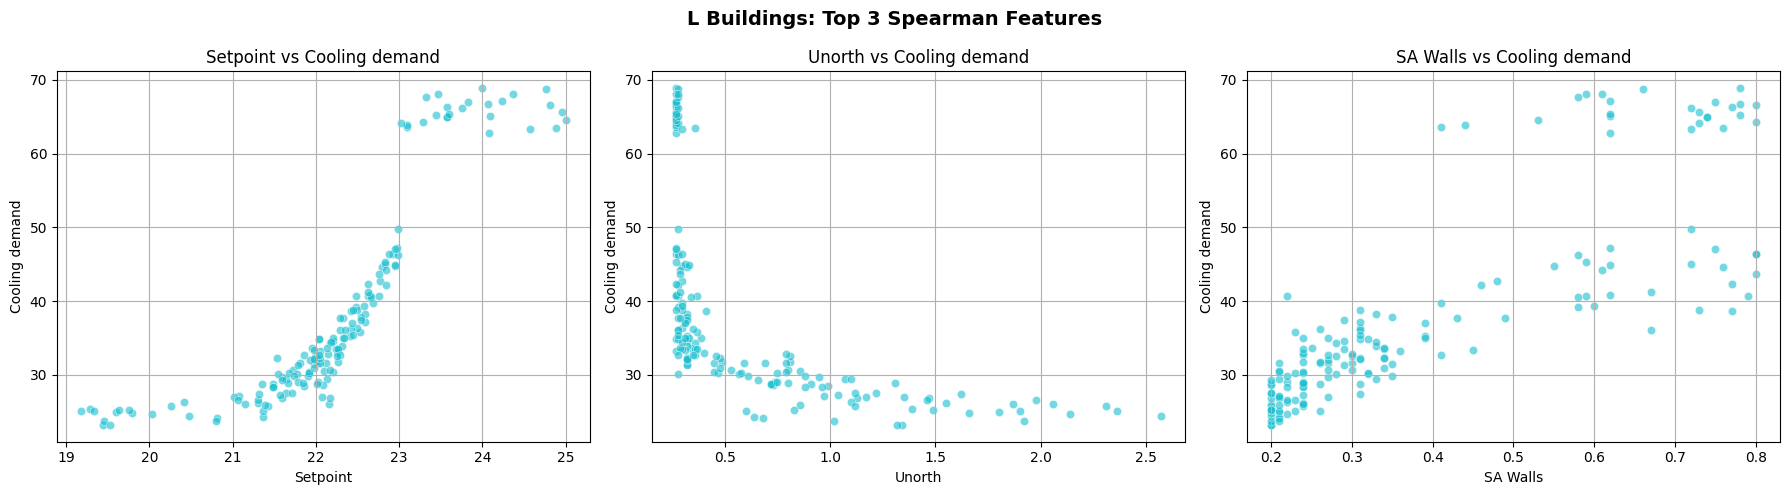

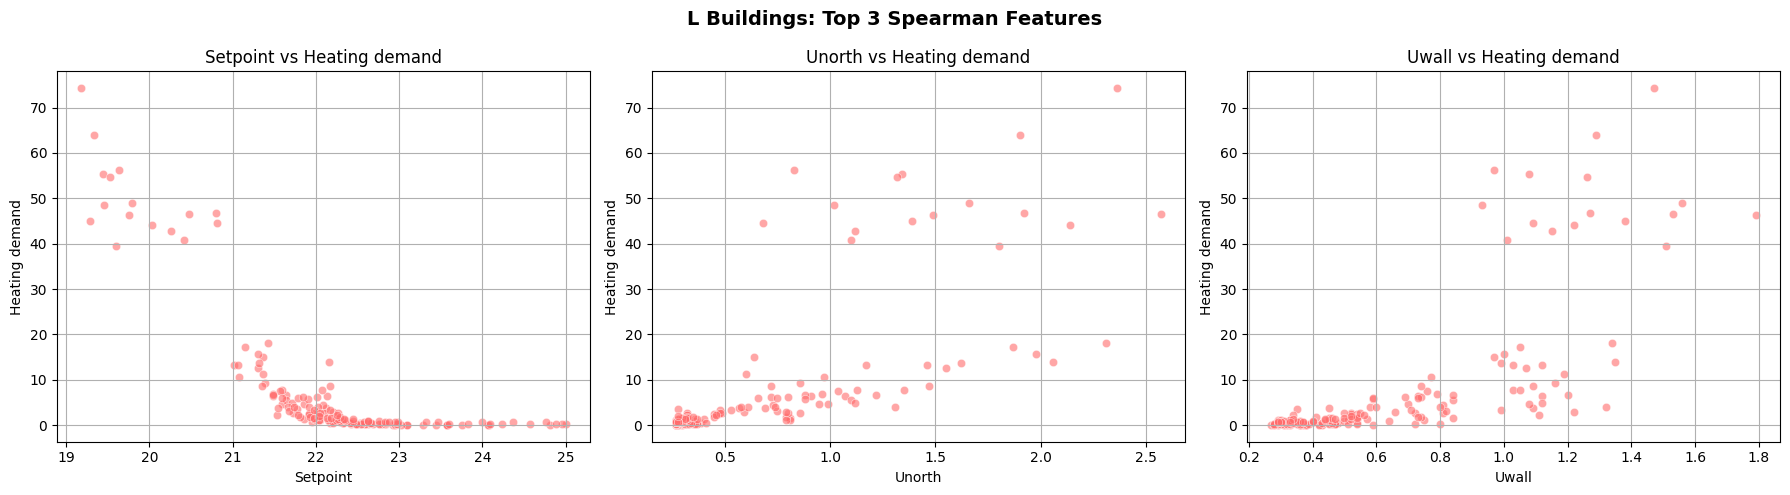

In [19]:
# Top 3 Spearman features for each building shape
top_features_dict = {}

for shape in ['H', 'L']:
    for target in targets:
        # Filter for specific building shape and target
        shape_target_data = comparison_df[
            (comparison_df['Building_Shape'] == shape) & 
            (comparison_df['Target'] == target)
        ].head(3)  # Top 3 ranks
        
        top_features_dict[(shape, target)] = shape_target_data['Spearman_Feature'].tolist()

# Plot scatterplots for each building shape
for shape_name in ['H', 'L']:
    shape_data = H_buildings if shape_name == 'H' else L_buildings
    
    # Create separate plots for each target
    for target in targets:
        top_3_features = top_features_dict[(shape_name, target)]
        
        # Define color according to target
        target_color = color_cooling if "cooling" in target.lower() else color_heating
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{shape_name} Buildings: Top 3 Spearman Features", 
                     fontsize=14, fontweight="bold")

        for i, feat in enumerate(top_3_features):
            sns.scatterplot(
                data=shape_data,
                x=feat,
                y=target,
                alpha=0.6,
                ax=axes[i],
                color=target_color
            )
            axes[i].set_title(f"{feat} vs {target}")
            axes[i].grid(True)
            axes[i].set_xlabel(feat)
            axes[i].set_ylabel(target)

        plt.tight_layout()
        plt.show()

For cooling demand, setpoint is the dominant factor in Linear buildings (0.959), while wall insulation (Uwall) leads in H-shaped buildings (0.879). This suggests that Linear buildings are more sensitive to indoor temperature settings, likely due to less thermal mass or compactness, whereas H-shaped buildings benefit more from envelope performance.

In heating demand, both building types prioritize setpoint and wall insulation, but with different rankings: Uwall is most influential in H-shape (0.959), while setpoint leads in Linear (0.919). This highlights that H-shaped buildings are more responsive to wall thermal performance, possibly due to larger surface area exposure.

Solar absorptance (SA Walls/Roof) appears consistently in both shapes, indicating that surface reflectivity matters for both cooling and heating loads, especially in Linear buildings where SA Walls ranks high for cooling.

Overall, H-shaped buildings are more influenced by envelope properties (U-values, SA), while Linear buildings show stronger sensitivity to operational factors like setpoint, reflecting differences in geometry, compactness, and thermal behavior.

H-shape: Optimize insulation and solar control (envelope-focused).

Linear: Prioritize occupant behavior (setpoint) and north-facing design (climate-responsive).

### Spearman correlation between Uvalues vs Energy Demands by shape

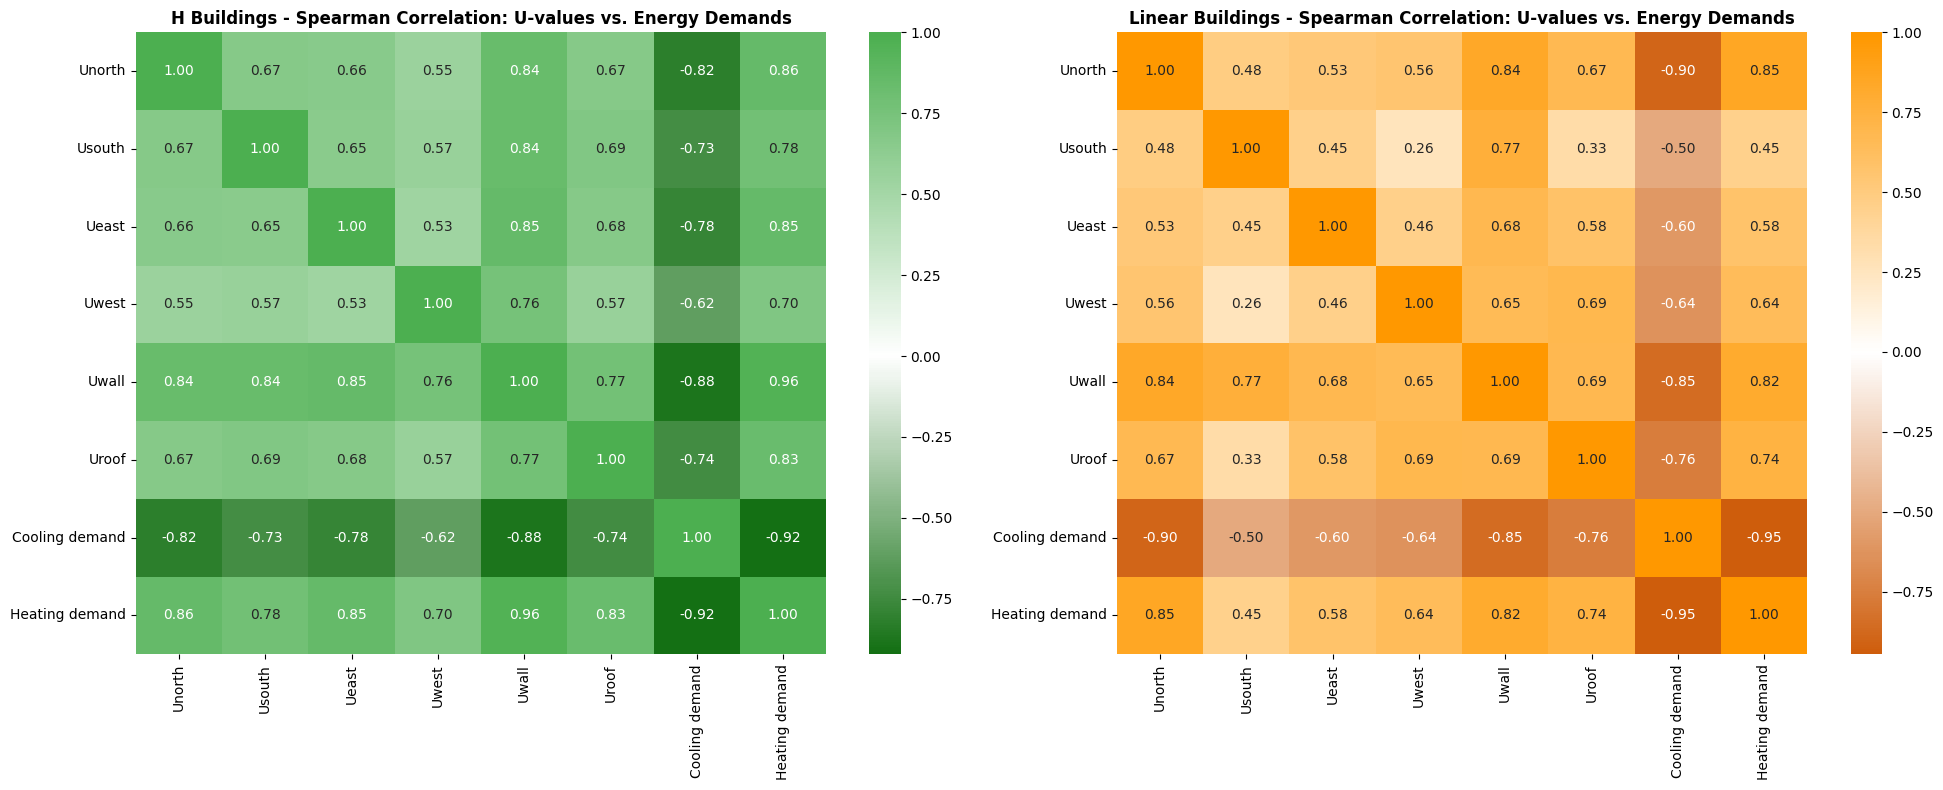

In [20]:
# Spearman correlations for H and L buildings
H_spearman = H_buildings[u_features + targets].corr(method='spearman')
L_spearman = L_buildings[u_features + targets].corr(method='spearman')

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(H_spearman, annot=True, fmt=".2f", cmap=custom_H_cmap, cbar=True, ax=axes[0], center=0)
axes[0].set_title("H Buildings - Spearman Correlation: U-values vs. Energy Demands", fontsize=12, fontweight="bold")
sns.heatmap(L_spearman, annot=True, fmt=".2f", cmap=custom_L_cmap, cbar=True, ax=axes[1], center=0)
axes[1].set_title("Linear Buildings - Spearman Correlation: U-values vs. Energy Demands", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [21]:
comparison_data_U = []

for target in targets:  
    H_spearman_top5 = H_spearman[target][u_features].abs().sort_values(ascending=False).head(5)
    L_spearman_top5 = L_spearman[target][u_features].abs().sort_values(ascending=False).head(5)
    
    # H building comparison
    for i in range(5):
        row_data = {
            'Target': target,
            'Building_Shape': 'H',
            'Rank': i + 1,
            'Spearman_Feature': H_spearman_top5.index[i],
            'Spearman_Corr': round(H_spearman_top5.values[i], 3)
        }
        comparison_data_U.append(row_data)
    
    # L building comparison
    for i in range(5):
        row_data = {
            'Target': target,
            'Building_Shape': 'L',
            'Rank': i + 1,
            'Spearman_Feature': L_spearman_top5.index[i],
            'Spearman_Corr': round(L_spearman_top5.values[i], 3)
        }
        comparison_data_U.append(row_data)
    
comparison_uvalues = pd.DataFrame(comparison_data_U)
comparison_uvalues

,Target,Building_Shape,Rank,Spearman_Feature,Spearman_Corr
0,Cooling demand,H,1,Uwall,0.879
1,Cooling demand,H,2,Unorth,0.824
2,Cooling demand,H,3,Ueast,0.784
3,Cooling demand,H,4,Uroof,0.740
4,Cooling demand,H,5,Usouth,0.727
5,Cooling demand,L,1,Unorth,0.899
6,Cooling demand,L,2,Uwall,0.855
7,Cooling demand,L,3,Uroof,0.757
8,Cooling demand,L,4,Uwest,0.636
9,Cooling demand,L,5,Ueast,0.601


### Top 3 most influential Uvalues by orientation (Spearman)

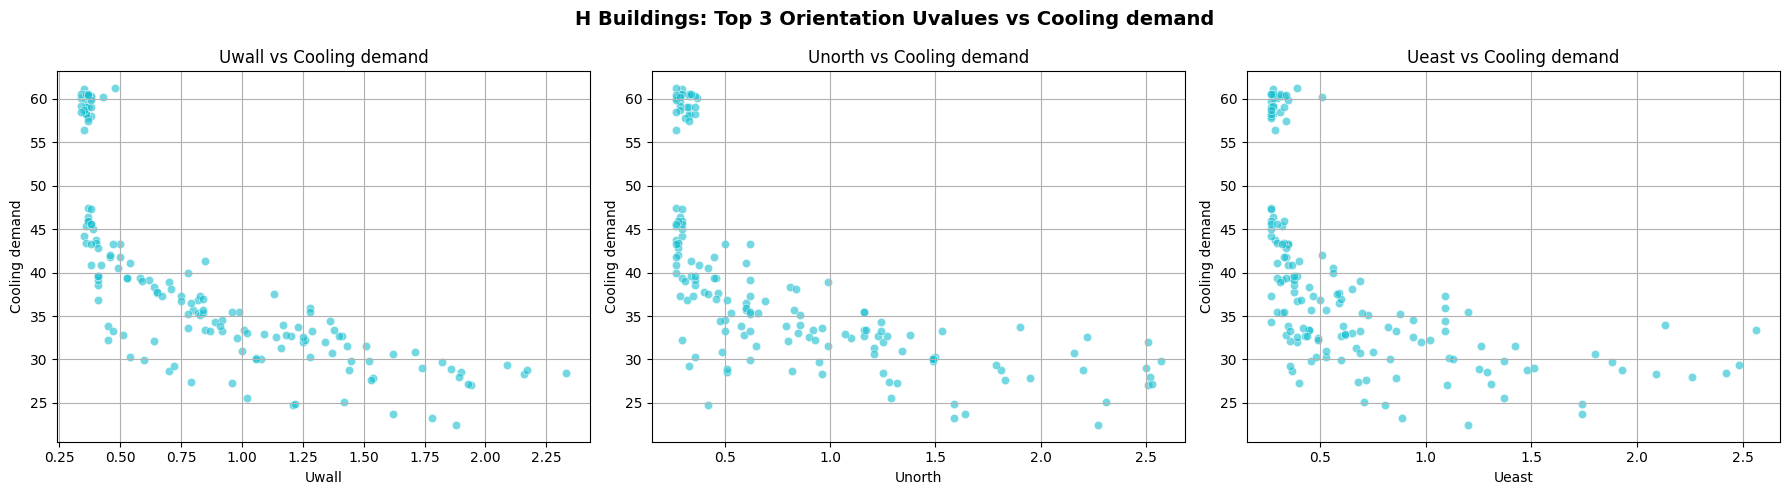

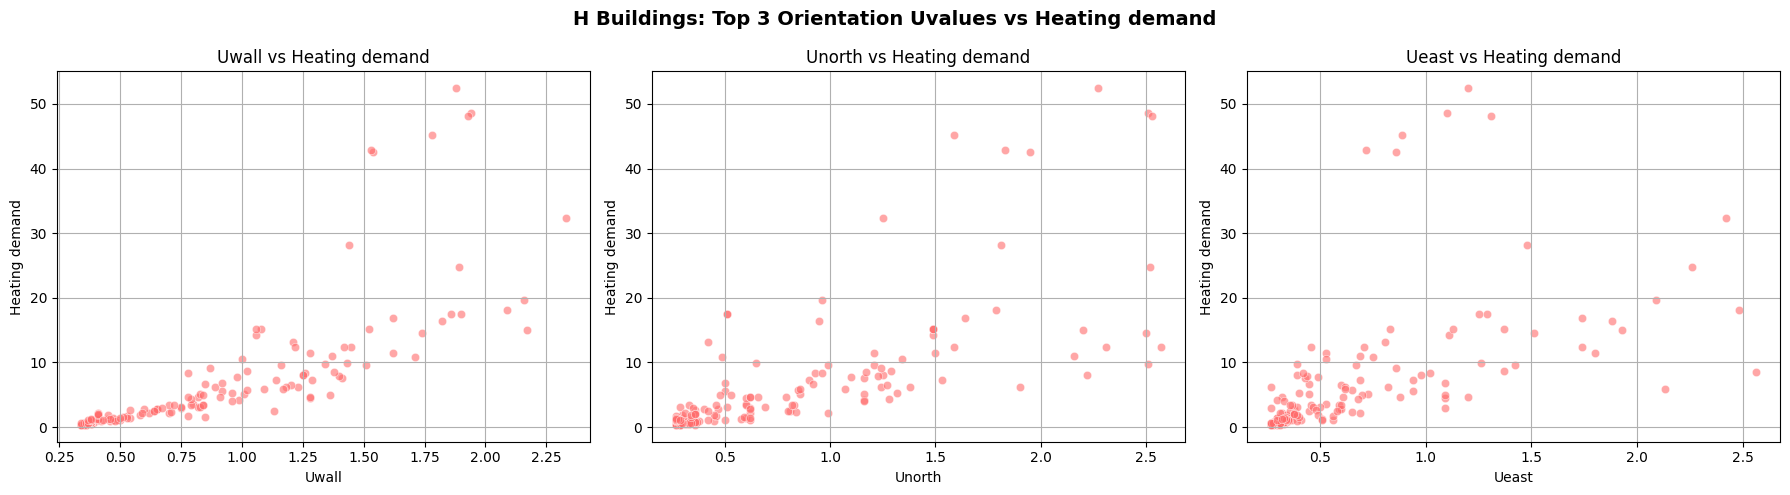

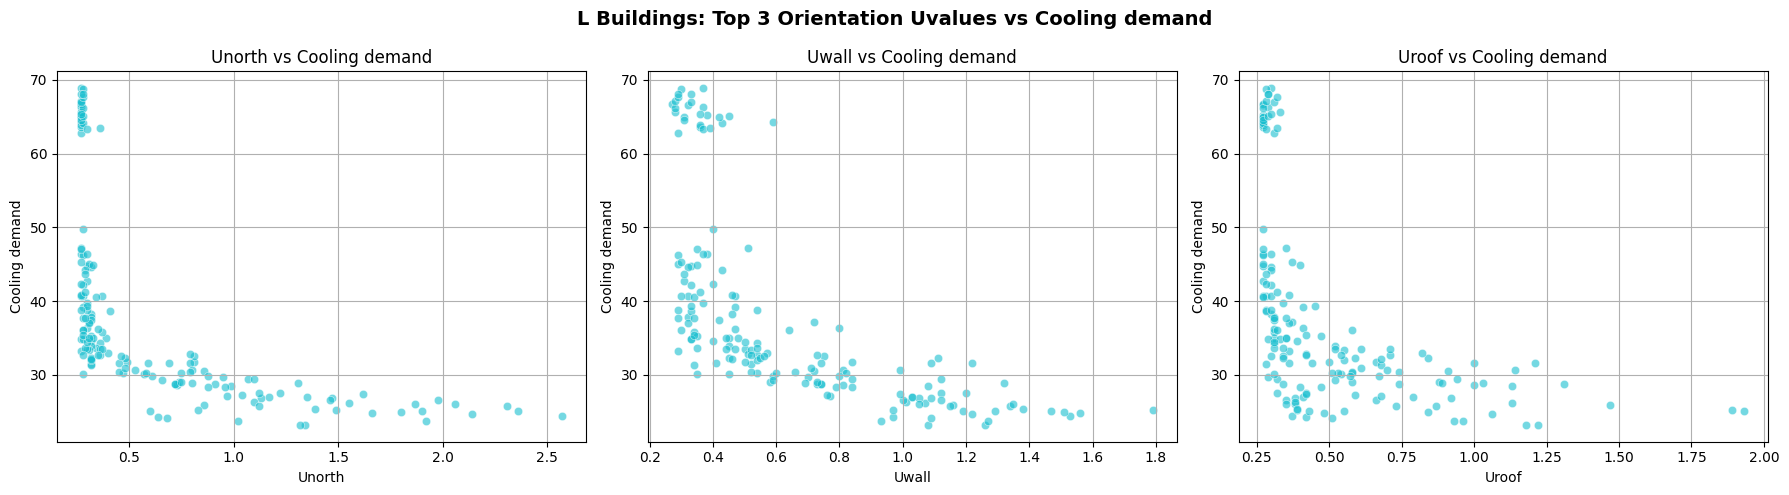

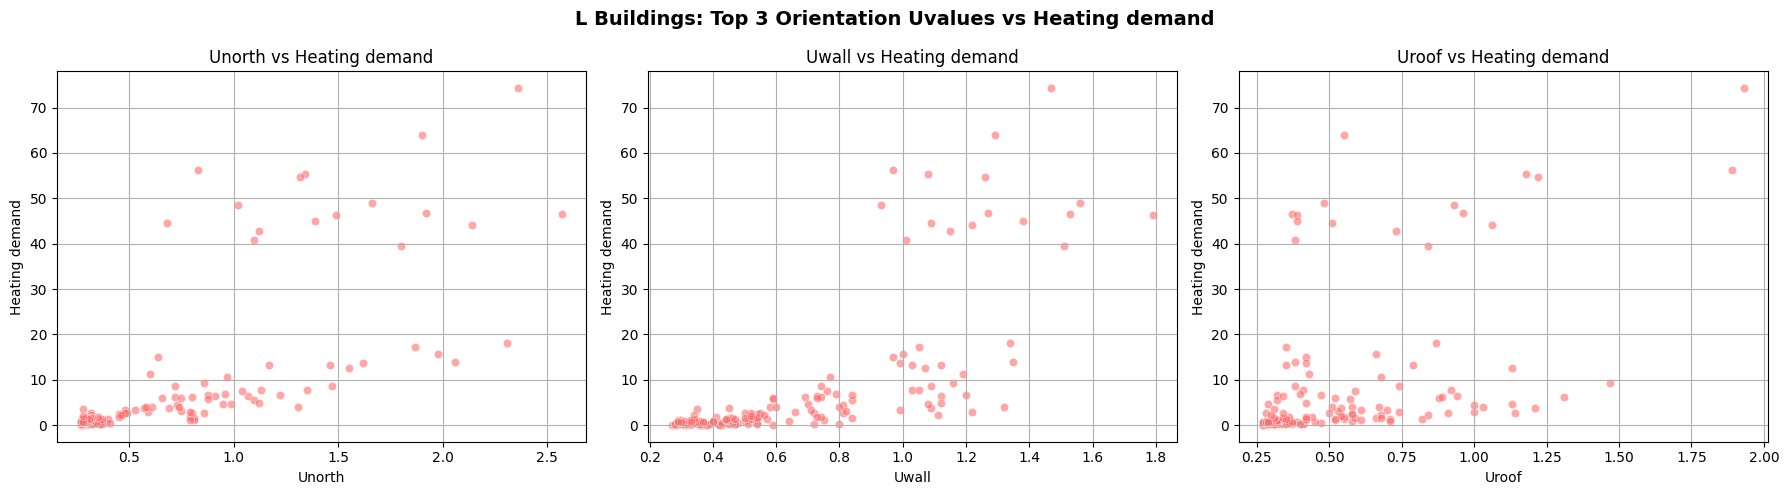

In [22]:
top_features_dict_Uvalues = {}

for shape in ['H', 'L']:
    for target in targets:
        # Filter for specific building shape and target
        shape_target_data = comparison_uvalues[
            (comparison_uvalues['Building_Shape'] == shape) & 
            (comparison_uvalues['Target'] == target)
        ].head(3)  # Top 3 ranks
        
        top_features_dict_Uvalues[(shape, target)] = shape_target_data['Spearman_Feature'].tolist()

# Plot scatterplots for each building shape
for shape_name in ['H', 'L']:
    shape_data = H_buildings if shape_name == 'H' else L_buildings
    
    for target in targets:
        top_3_features = top_features_dict_Uvalues[(shape_name, target)]
        
        # Define color according to target
        target_color = color_cooling if "cooling" in target.lower() else color_heating
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{shape_name} Buildings: Top 3 Orientation Uvalues vs {target}", 
                     fontsize=14, fontweight="bold")

        for i, feat in enumerate(top_3_features):
            sns.scatterplot(
                data=shape_data,
                x=feat,
                y=target,
                alpha=0.6,
                ax=axes[i],
                color=target_color
            )
            axes[i].set_title(f"{feat} vs {target}")
            axes[i].grid(True)
            axes[i].set_xlabel(feat)
            axes[i].set_ylabel(target)

        plt.tight_layout()
        plt.show()

For cooling demand, Uwall is the most influential factor in H buildings (0.879), indicating that wall insulation is critical to reduce heat gain. In Linear buildings, Unorth leads (0.899), suggesting that north-facing walls play a key role in controlling summer overheating due to solar exposure.

For heating demand, Uwall dominates in both building typologies, with a very strong correlation in H buildings (0.959) and high influence in Linear (0.816). This highlights that wall thermal performance is the primary driver of heat loss in winter, regardless of shape.

The consistent ranking of Uwall, Unorth, and Uroof across both shapes shows that vertical envelope insulation is essential for energy efficiency. However, the higher sensitivity of H buildings to Uwall suggests they are more vulnerable to heat transfer through walls, likely due to larger surface area or less compact form.

Prioritize wall insulation (Uwall) for maximum impact on both cooling and heating loads.
For Linear buildings, also focus on north façade (Unorth) to manage solar gains.

### Parallel Coordinates by Shape

In [23]:
# H Buildings
plotly.offline.init_notebook_mode(connected=True)
fig = px.parallel_coordinates(H_buildings,color="Heating demand", dimensions=["Unorth","Usouth","Ueast","Uwest", "Uwall", 'Uroof',"Cooling demand","Heating demand" ],
    color_continuous_scale=px.colors.diverging.Temps,  title="ParallelGroup Coordinates: H Building")
fig.show()

In [24]:
# H Building Optimal Solution
min_total_demand = H_buildings['Total demand'].min()
bestone = H_buildings[H_buildings['Total demand'] == min_total_demand].copy()
bestone = bestone.sort_values(by='Heating demand', ascending=True).reset_index(drop=True)
bestone

,ID_Optimization,Gen,WWR,Shape,IT North,Unorth,IT South,Usouth,IT East,Ueast,...,Uwall,IT Roof,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Cooling demand,Heating demand,Total demand
0,HW20_14,13.0,0.2,H,0.018,1.28,0.093,0.41,0.048,0.68,...,0.79,0.103,0.37,0.21,0.24,0.003,21.67,27.36,4.28,31.63


In [25]:
# Linear Building 
plotly.offline.init_notebook_mode(connected=True)
fig = px.parallel_coordinates(L_buildings,color="Heating demand", dimensions=["Unorth","Usouth","Ueast","Uwest", "Uwall", 'Uroof',"Cooling demand","Heating demand" ],
    color_continuous_scale=px.colors.diverging.Temps,  title="ParallelGroup Coordinates: Linear Building")
fig.show()

In [26]:
# Linear Building Optimal Solution
min_total_demand = L_buildings['Total demand'].min()
bestone = L_buildings[L_buildings['Total demand'] == min_total_demand].copy()
bestone = bestone.sort_values(by='Heating demand', ascending=True).reset_index(drop=True)
bestone

,ID_Optimization,Gen,WWR,Shape,IT North,Unorth,IT South,Usouth,IT East,Ueast,...,Uwall,IT Roof,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Cooling demand,Heating demand,Total demand
0,LW15_12,11.0,0.15,L,0.032,1.12,0.023,1.48,0.013,0.5,...,1.12,0.088,0.42,0.2,0.22,0.005,21.71,27.53,4.94,32.47


### Violin Plot of U-values by Orientation + Stripplot Colored by Total Energy Demand

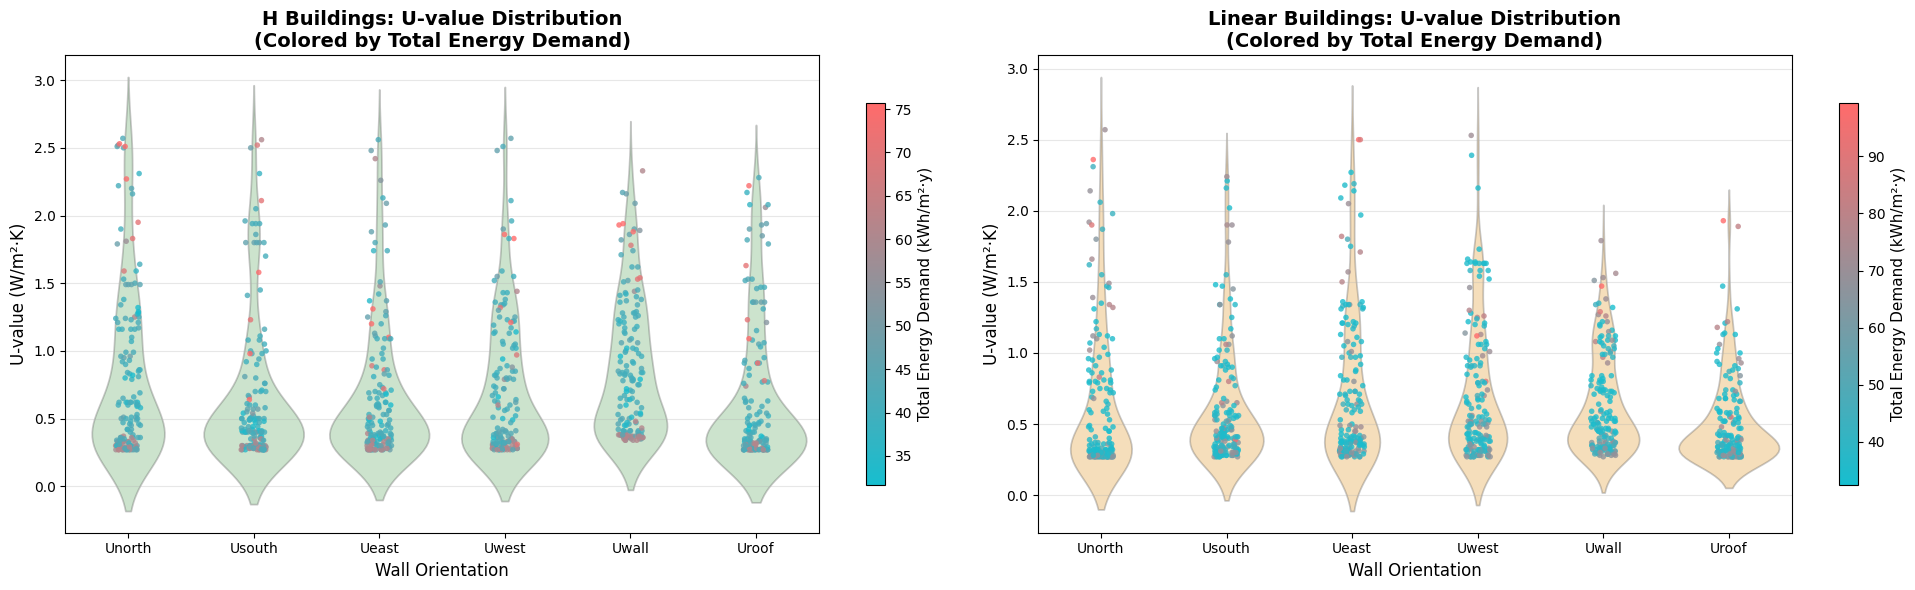

In [27]:
custom_cmap = LinearSegmentedColormap.from_list('energy', [color_cooling, color_heating])

prepared_data = {}
for shape_name, shape_data in [('H', H_buildings), ('L', L_buildings)]:
    shape_data_copy = shape_data.copy()
    shape_data_copy['Total Demand'] = shape_data_copy['Heating demand'] + shape_data_copy['Cooling demand']
    
    # Melt the data for plotting
    melted_u_values = shape_data_copy.melt(
        id_vars=['Total Demand'],
        value_vars=u_features,
        var_name='Wall',
        value_name='U-value'
    )
    prepared_data[shape_name] = melted_u_values

# Create side-by-side comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left plot: H-shaped buildings
sns.violinplot(
    data=prepared_data['H'],
    x='Wall',
    y='U-value',
    inner=None,
    color=shape_colors['H'],
    alpha=0.3,
    ax=ax1
)

sns.stripplot(
    data=prepared_data['H'],
    x='Wall',
    y='U-value',
    hue='Total Demand',
    palette=custom_cmap,
    size=4,
    alpha=0.8,
    edgecolor='k',
    jitter=True,      
    legend=False,
    ax=ax1
)

ax1.set_title('H Buildings: U-value Distribution\n(Colored by Total Energy Demand)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Wall Orientation', fontsize=12)
ax1.set_ylabel('U-value (W/m²·K)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add colorbar for H-building
sm1 = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(
    vmin=prepared_data['H']['Total Demand'].min(),
    vmax=prepared_data['H']['Total Demand'].max()
))
sm1.set_array([])
cbar1 = plt.colorbar(sm1, ax=ax1, shrink=0.8)
cbar1.set_label('Total Energy Demand (kWh/m²·y)', rotation=90, fontsize=11)

# Right plot: L-shaped buildings
sns.violinplot(
    data=prepared_data['L'],
    x='Wall',
    y='U-value',
    inner=None,
    color=shape_colors['L'],
    alpha=0.3,
    ax=ax2
)

sns.stripplot(
    data=prepared_data['L'],
    x='Wall',
    y='U-value',
    hue='Total Demand',
    palette=custom_cmap,
    size=4,
    alpha=0.8,
    edgecolor='k',
    jitter=True,      
    legend=False,
    ax=ax2
)

ax2.set_title('Linear Buildings: U-value Distribution\n(Colored by Total Energy Demand)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Wall Orientation', fontsize=12)
ax2.set_ylabel('U-value (W/m²·K)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Add colorbar for L-building
sm2 = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(
    vmin=prepared_data['L']['Total Demand'].min(),
    vmax=prepared_data['L']['Total Demand'].max()
))
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax2, shrink=0.8)
cbar2.set_label('Total Energy Demand (kWh/m²·y)', rotation=90, fontsize=11)

plt.tight_layout()
plt.show()

The left graph shows H buildings: most U-values are low (good insulation), but higher values (especially in walls and roof) are linked to higher energy use (red dots). The right graph shows linear buildings: they have similar U-value ranges, but total energy demand is generally higher, with more red points at higher U-values. In both cases, better insulation (lower U-values) leads to lower energy demand. This means that improving insulation in key areas can save energy — and this effect is stronger in linear buildings.

### Comparison between Uwall by WWR

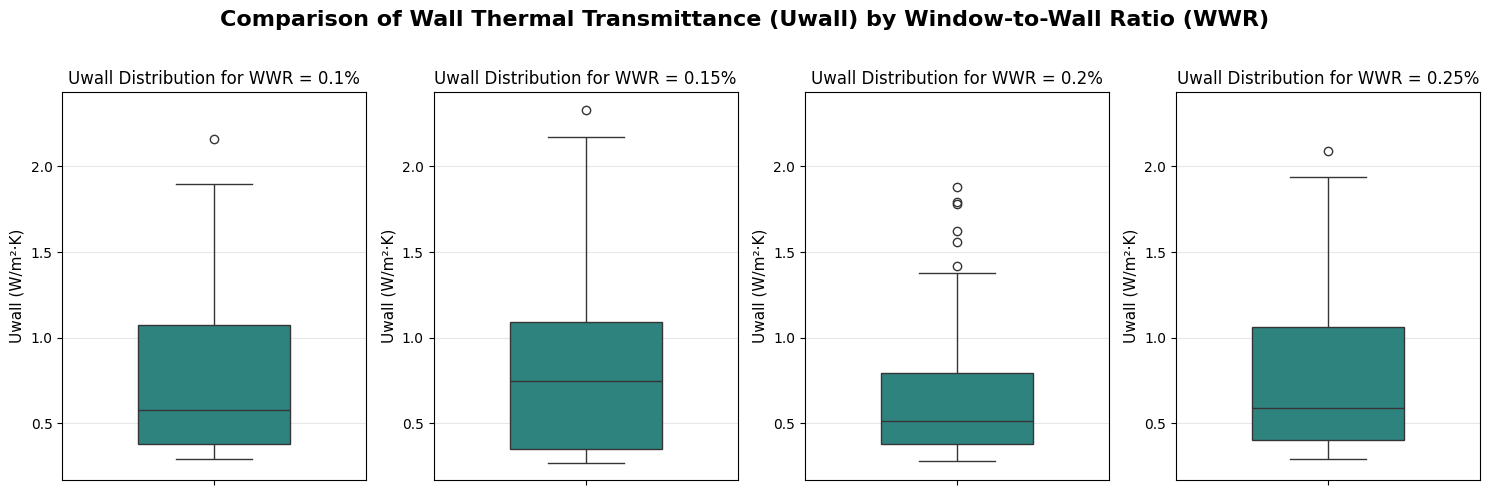

In [28]:
# Define WWR values and subplot layout
wwr_values = sorted(optimizations['WWR'].unique())
n_wwrs = len(wwr_values)
cols = 4
rows = (n_wwrs + cols - 1) // cols 

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
if n_wwrs == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# y-axis limits with some padding
ymin = optimizations["Uwall"].min()
ymax = optimizations["Uwall"].max()
y_range = ymax - ymin
padding = y_range * 0.05  
ymin -= padding
ymax += padding

# Create a boxplot for each WWR value
for i, wwr in enumerate(wwr_values):
    data_subset = optimizations[optimizations['WWR'] == wwr]
    sns.boxplot(data=data_subset, y='Uwall', ax=axes[i], palette='viridis', width=0.5)
    axes[i].set_title(f'Uwall Distribution for WWR = {wwr}%', fontsize=12)
    axes[i].set_ylabel('Uwall (W/m²·K)', fontsize=11)
    axes[i].grid(True, axis='y', alpha=0.3) 
    
    # Set the same y-axis limits for all subplots
    axes[i].set_ylim(ymin, ymax)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
plt.suptitle('Comparison of Wall Thermal Transmittance (Uwall) by Window-to-Wall Ratio (WWR)',
             fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make space for suptitle
plt.show()

The boxplots show that higher WWR values are associated with lower Uwall values, indicating better wall insulation in buildings with larger windows. This suggests a design trend where high glazing ratios are paired with improved thermal performance to compensate for increased heat gain. At 20% WWR, the median Uwall drops to ~0.5 W/m²·K, while maintaining a tight distribution, suggesting a deliberate focus on energy efficiency in this range. For WWR = 0.1%, 0.15%, and 0.25%, the distributions are broader and have higher medians (~0.6–0.7), indicating more variability and less optimal insulation.

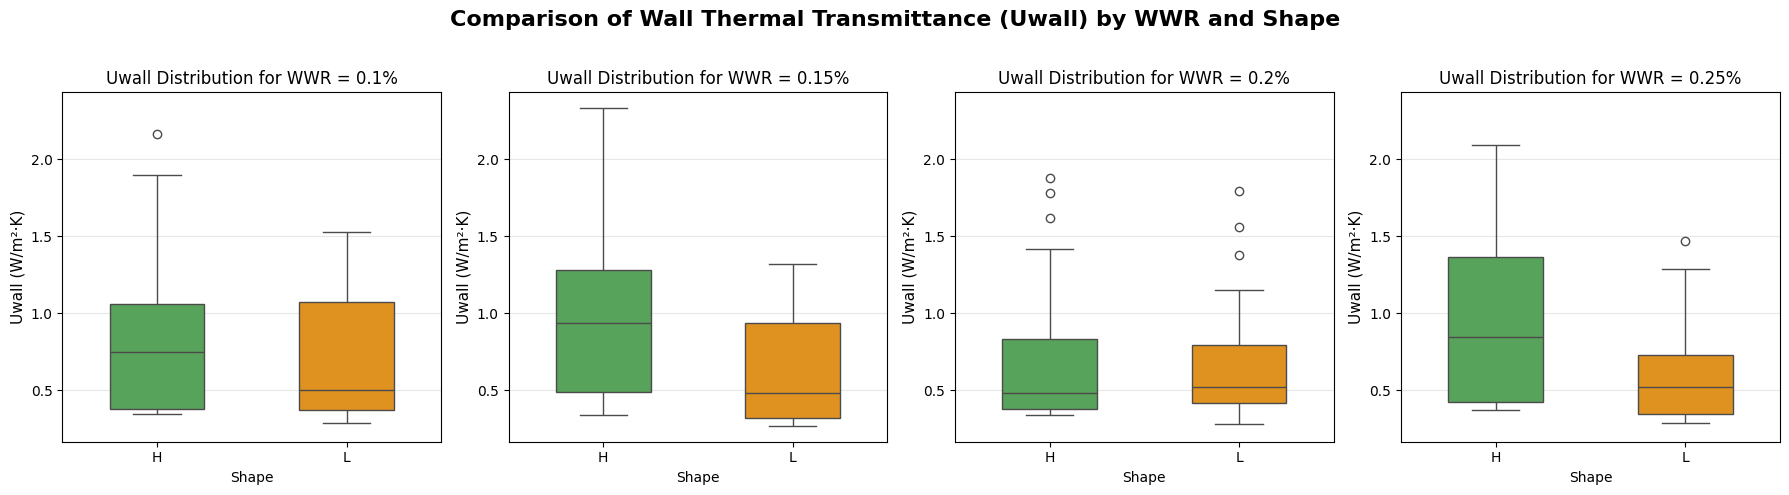

In [29]:
# Define WWR values and subplot layout
wwr_values = sorted(optimizations['WWR'].unique())
n_wwrs = len(wwr_values)
cols = 4
rows = (n_wwrs + cols - 1) // cols  

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
if n_wwrs == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Calculate y-axis limits with padding using the entire dataset
ymin = optimizations["Uwall"].min()
ymax = optimizations["Uwall"].max()
y_range = ymax - ymin
padding = y_range * 0.05  # 5% padding
ymin_padded = ymin - padding
ymax_padded = ymax + padding

# Boxplot for each WWR value
for i, wwr in enumerate(wwr_values):
    data_subset = optimizations[optimizations['WWR'] == wwr]

    sns.boxplot(
        data=data_subset,
        x="Shape",        
        y="Uwall",
        ax=axes[i],
        palette=shape_colors,
        width=0.5
    )

    axes[i].set_title(f"Uwall Distribution for WWR = {wwr}%", fontsize=12)
    axes[i].set_xlabel("Shape")
    axes[i].set_ylabel("Uwall (W/m²·K)", fontsize=11)
    axes[i].grid(True, axis='y', alpha=0.3)  
    
    # Set the same y-axis limits for all subplots with padding
    axes[i].set_ylim(ymin_padded, ymax_padded)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Title
plt.suptitle(
    "Comparison of Wall Thermal Transmittance (Uwall) by WWR and Shape",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

The boxplots show that for all WWR values, Linear (L) buildings have lower Uwall values than H buildings, indicating better wall insulation. This trend becomes more pronounced at higher WWRs, where Linear buildings maintain tighter distributions and lower medians. At 20% WWR, the median Uwall drops to ~0.5 W/m²·K for Linear buildings, while H buildings remains around 0.8–0.9, suggesting a design strategy favoring thermal performance in linear forms with larger glazing. Also, the H building in the 25% WWR can indicate some issue in the simulation, due the great difference between other WWRs. This indicates that building shape influences envelope quality: Linear buildings tend to prioritize insulation when glazing increases, likely due to greater exposure or solar gain sensitivity.

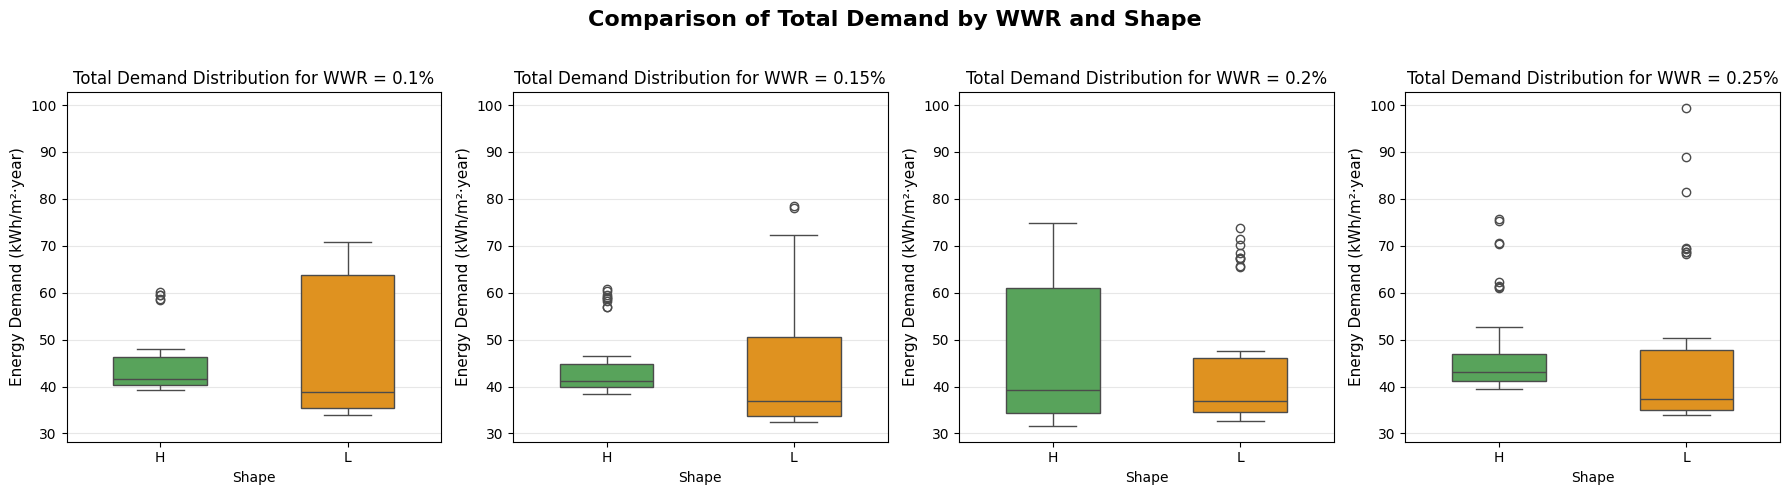

In [30]:
# Define WWR values and subplot layout
wwr_values = sorted(optimizations['WWR'].unique())
n_wwrs = len(wwr_values)
cols = 4
rows = (n_wwrs + cols - 1) // cols 

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
if n_wwrs == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Calculate y-axis limits with padding using the entire dataset
ymin = optimizations["Total demand"].min()
ymax = optimizations["Total demand"].max()
y_range = ymax - ymin
padding = y_range * 0.05  # 5% padding
ymin_padded = ymin - padding
ymax_padded = ymax + padding

# Boxplot for each WWR value
for i, wwr in enumerate(wwr_values):
    data_subset = optimizations[optimizations['WWR'] == wwr]

    sns.boxplot(
        data=data_subset,
        x="Shape",          
        y="Total demand",   
        ax=axes[i],
        palette=shape_colors,
        width=0.5
    )

    axes[i].set_title(f"Total Demand Distribution for WWR = {wwr}%", fontsize=12)
    axes[i].set_xlabel("Shape")
    axes[i].set_ylabel("Energy Demand (kWh/m²·year)", fontsize=11)
    axes[i].grid(True, axis='y', alpha=0.3)  
    
    # Set the same y-axis limits for all subplots with padding
    axes[i].set_ylim(ymin_padded, ymax_padded)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Title
plt.suptitle(
    "Comparison of Total Demand by WWR and Shape",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()

H buildings consistently have lower total energy demand than Linear buildings across all WWR values, with the difference being most pronounced at 20 % WWR (this dismatch value is suspected to be some energyplus simulation error during the multi-objective phase), where H building median demand is ~38 kWh/m²·year vs. ~45 kWh/m²·year for Linear building. At low WWRs (10%, 15%), Linear buildings exhibit higher variability and outliers, suggesting less consistent performance. As WWR increases, both shapes show rising demand, but H buildings maintain better control over energy use, likely due to more favorable solar exposure and compactness.

H buildings are more energy-efficient, especially at moderate to high WWRs. This supports the idea that building geometry significantly impacts energy performance, with H building offering better thermal balance and reduced demand. 

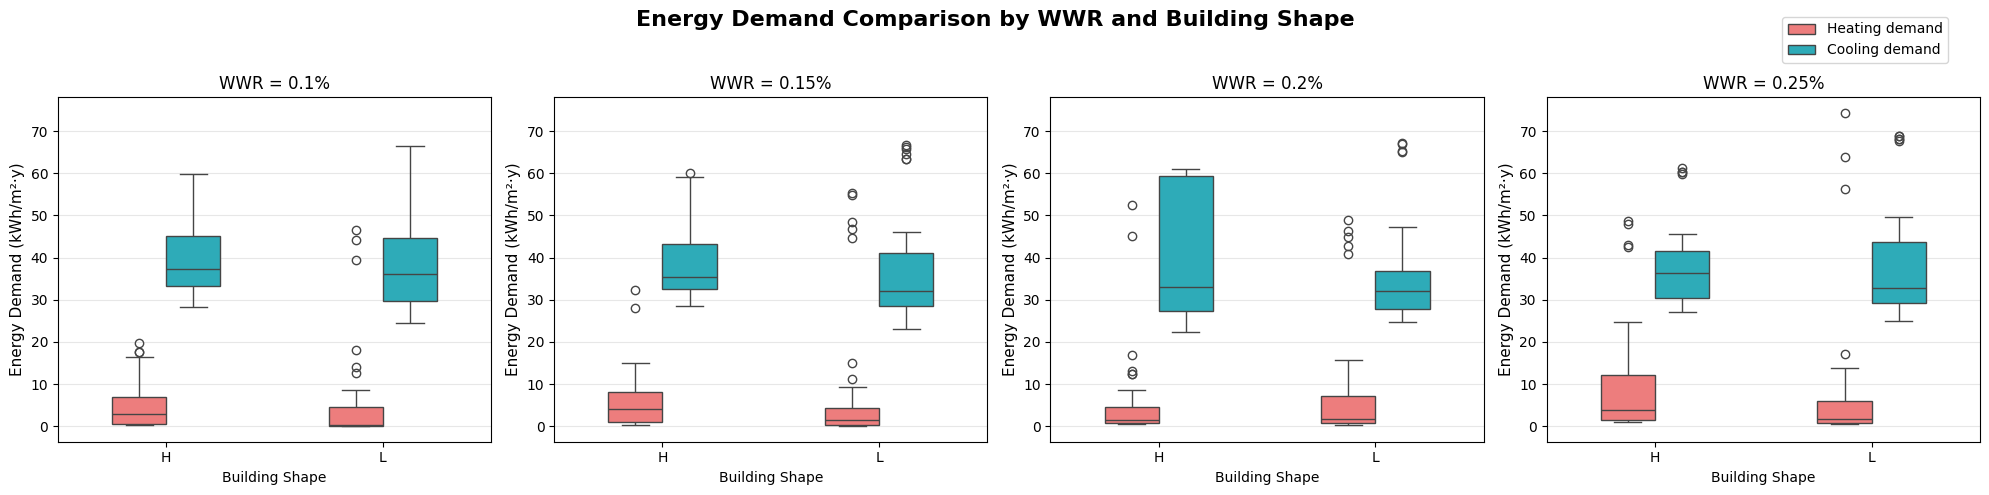

In [31]:
demand_colors = {'Heating demand': '#FF6B6B', 'Cooling demand': '#17becf'}

# WWR values 
wwr_values = sorted(optimizations['WWR'].unique())
n_wwrs = len(wwr_values)
cols = 4
rows = (n_wwrs + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
if n_wwrs == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Calculate y-axis limits with padding using the entire dataset for both heating and cooling
heating_data = optimizations["Heating demand"]
cooling_data = optimizations["Cooling demand"]
all_demand_data = pd.concat([heating_data, cooling_data])
ymin = all_demand_data.min()
ymax = all_demand_data.max()
y_range = ymax - ymin
padding = y_range * 0.05  # 5% padding
ymin_padded = ymin - padding
ymax_padded = ymax + padding

# Boxplot for each WWR value
for i, wwr in enumerate(wwr_values):
    data_subset = optimizations[optimizations['WWR'] == wwr]

    # Melt data into long format for Heating and Cooling, keeping Shape
    melted = data_subset.melt(
        id_vars=["Shape"],
        value_vars=["Heating demand", "Cooling demand"],
        var_name="Demand",
        value_name="Value"
    )

    # Plot: x = Shape, hue = Demand
    sns.boxplot(
        data=melted,
        x="Shape",
        y="Value",
        hue="Demand",
        ax=axes[i],
        palette=demand_colors,
        width=0.5
    )

    axes[i].set_title(f"WWR = {wwr}%", fontsize=12)
    axes[i].set_xlabel("Building Shape")
    axes[i].set_ylabel("Energy Demand (kWh/m²·y)", fontsize=11)
    axes[i].grid(True, axis='y', alpha=0.3)  
    
    # Set the same y-axis limits for all subplots with padding
    axes[i].set_ylim(ymin_padded, ymax_padded)

    # Remove legend from all subplots
    axes[i].get_legend().remove()

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Title
plt.suptitle(
    "Energy Demand Comparison by WWR and Building Shape",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()

H buildings have higher cooling demand than Linear buildings, especially at WWR = 20%, where H building median cooling demand reaches to almost 60 kWh/m²·y vs. almost 35 kWh/m²·y for Linear building indicating greater solar exposure or less effective shading. In contrast, heating demand is similar across both shapes, with medians around 5–10 kWh/m²·y, suggesting comparable thermal performance in winter. As WWR increases, cooling demand rises more sharply in H buildings, likely due to larger surface area and orientation effects, while Linear maintains better control over heat gain.

Building shape significantly affects cooling performance, with H buildings being more vulnerable to overheating at higher WWRs.
This supports the use of Linear layouts for high-WWR designs in warm climates to reduce cooling loads. 

### Evaluation of the evolution of the demand by the constructive parameters

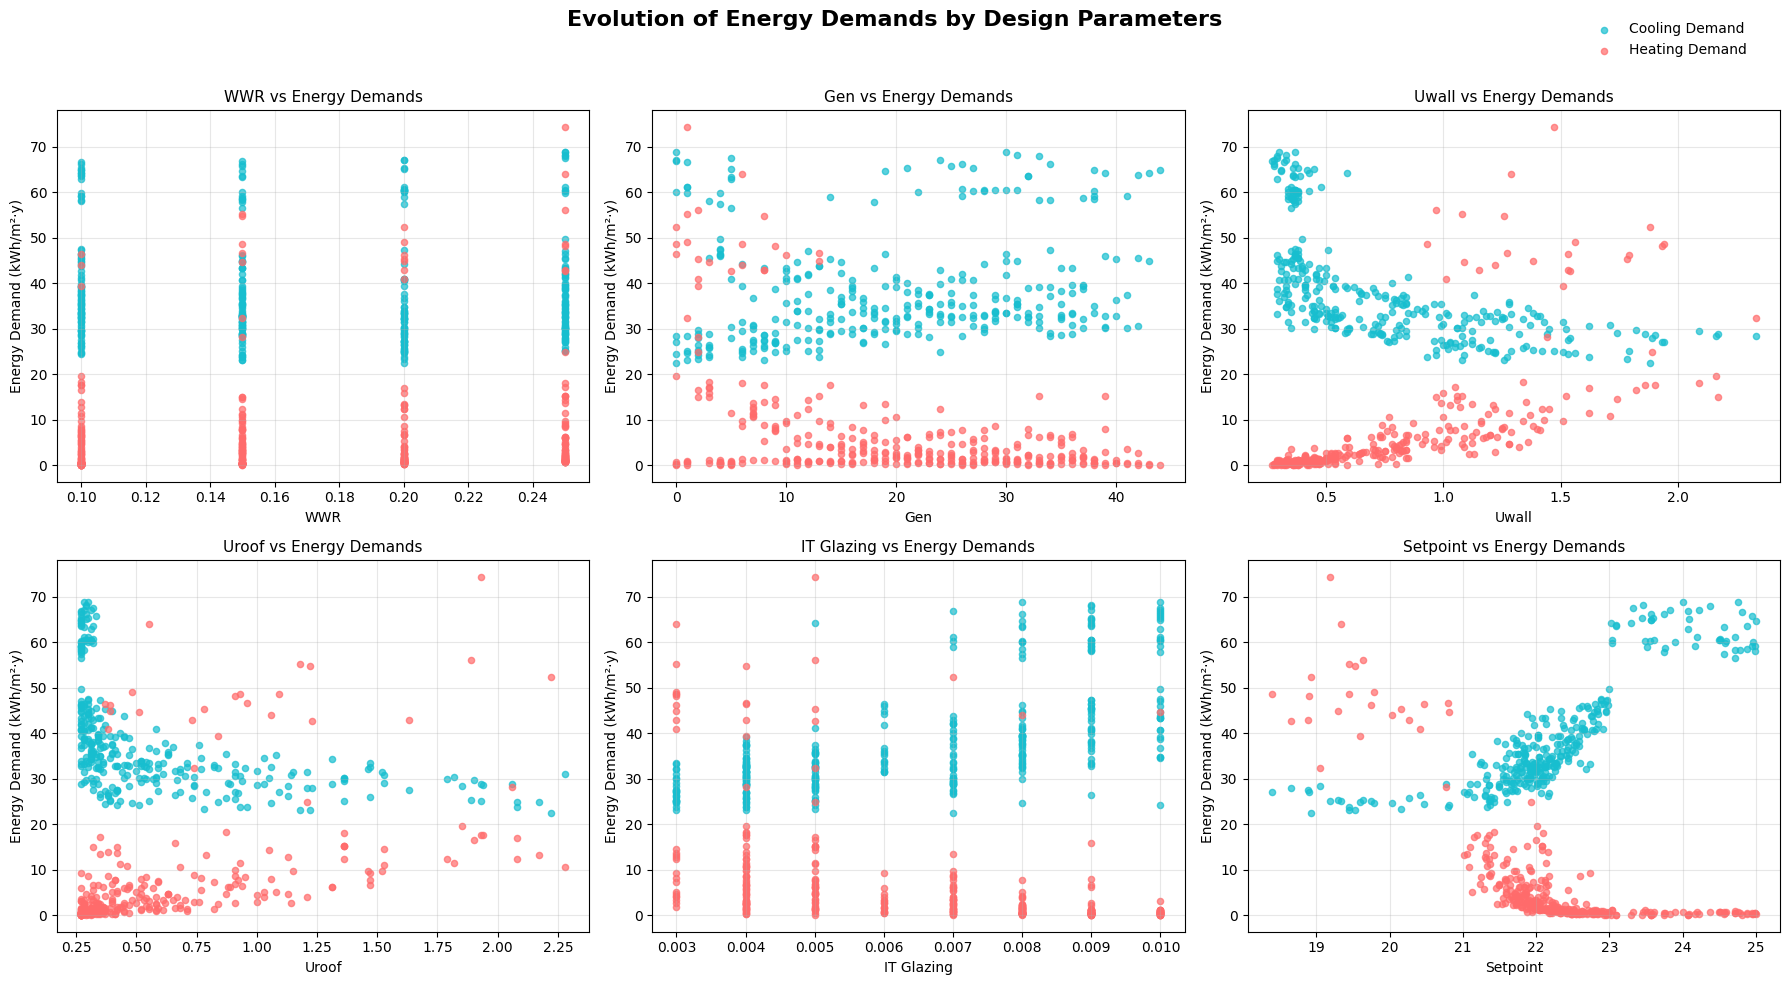

In [32]:
# Variables
variables = ['WWR', 'Gen', 'Uwall', 'Uroof', 'IT Glazing', 'Setpoint']

# Data is numeric
df_plot = optimizations[variables + ['Heating demand', 'Cooling demand']].copy()
for col in variables + ['Heating demand', 'Cooling demand']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
df_plot.dropna(inplace=True)

# 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Evolution of Energy Demands by Design Parameters', fontsize=16, fontweight='bold')
axes = axes.flatten()

# Loop through each variable
for i, var in enumerate(variables):
    ax = axes[i]
    
    ax.scatter(df_plot[var], df_plot['Cooling demand'], 
               alpha=0.7, color=color_cooling, s=20, label='Cooling Demand')
    ax.scatter(df_plot[var], df_plot['Heating demand'], 
               alpha=0.7, color=color_heating, s=20, label='Heating Demand')
    ax.set_title(f'{var} vs Energy Demands', fontsize=11)
    ax.set_xlabel(var)
    ax.set_ylabel('Energy Demand (kWh/m²·y)')
    ax.grid(True, alpha=0.3)
    ax.legend().remove()

# Add single legend outside the plots
fig.legend(['Cooling Demand', 'Heating Demand'], 
           loc="upper right", 
           bbox_to_anchor=(0.98, 0.98),
           frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()

The plots reveal that WWR and Uroof have strong nonlinear effects: high WWR increases cooling demand, while low Uroof reduces it significantly.
Setpoint is critical — heating demand drops sharply above 22°C, indicating passive cooling strategies dominate.
Gen shows convergence after ~15 generations, suggesting the algorithm stabilizes early.
IT Glazing has limited impact on energy use, implying that window thickness alone is not a key driver.

### Sensitivy analysis by Uvalue orientation and roof

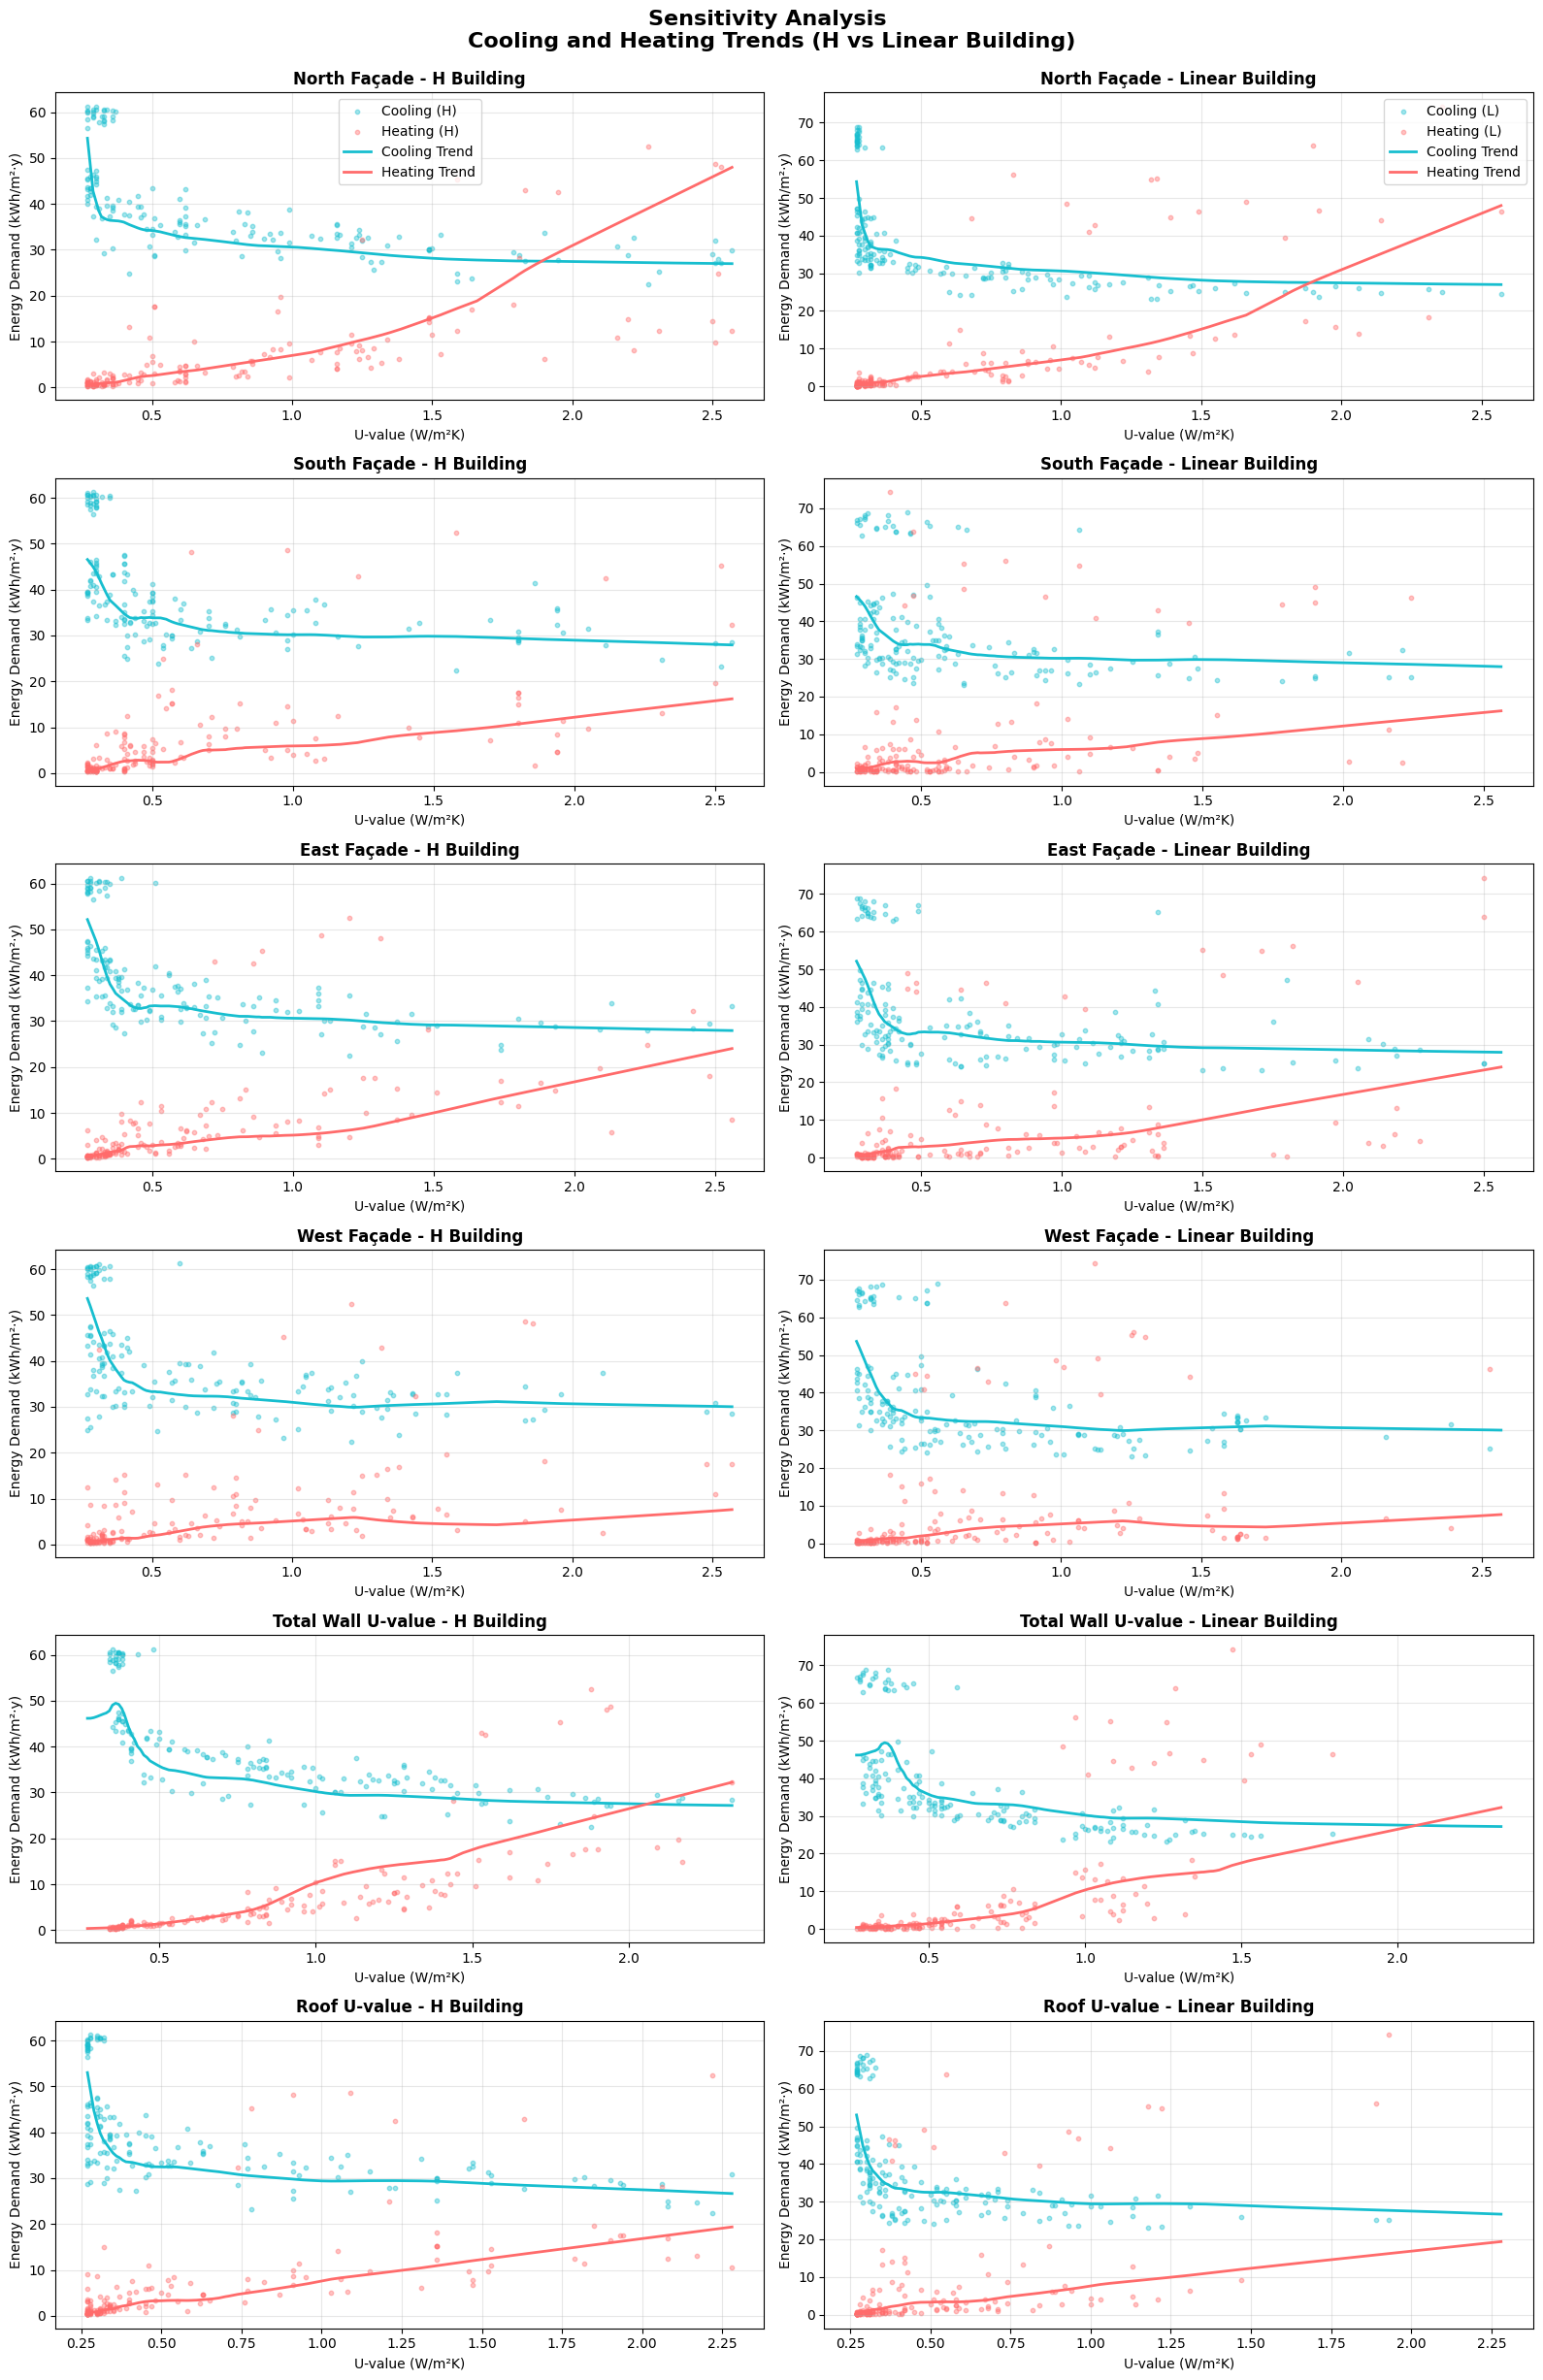

In [33]:
titles = [
    'North Façade',
    'South Façade',
    'East Façade',
    'West Façade',
    'Total Wall U-value',
    'Roof U-value'
]

# Grid 2 columns = total of 12 graphics
fig, axes = plt.subplots(6, 2, figsize=(16, 24))
axes = axes.ravel()

for i, (var, title) in enumerate(zip(u_features, titles)):

    # H building
    ax_H = axes[2*i]
    
    # Cooling and Heating division
    uvalue = optimizations[var].values
    cool = optimizations['Cooling demand'].values
    heat = optimizations['Heating demand'].values
 
    lowess_cool = lowess(cool, uvalue, frac=0.3)
    lowess_heat = lowess(heat, uvalue, frac=0.3)
    
    ax_H.scatter(H_buildings[var], H_buildings['Cooling demand'],
                 color=color_cooling, alpha=0.4, s=10, label="Cooling (H)")
    ax_H.scatter(H_buildings[var], H_buildings['Heating demand'],
                 color=color_heating, alpha=0.4, s=10, label="Heating (H)")

    # LOWESS H building
    ax_H.plot(lowess_cool[:, 0], lowess_cool[:, 1],
              color=color_cooling, linewidth=2, label="Cooling Trend")
    ax_H.plot(lowess_heat[:, 0], lowess_heat[:, 1],
              color=color_heating, linewidth=2, label="Heating Trend")

    ax_H.set_title(f"{title} - H Building", fontsize=12, fontweight="bold")
    ax_H.set_xlabel("U-value (W/m²K)")
    ax_H.set_ylabel("Energy Demand (kWh/m²·y)")
    ax_H.grid(True, alpha=0.3)
    if i == 0:
        ax_H.legend()   

    # Linear building 
    ax_L = axes[2*i + 1]
    ax_L.scatter(L_buildings[var], L_buildings['Cooling demand'],
                 color=color_cooling, alpha=0.4, s=10, label="Cooling (L)")
    ax_L.scatter(L_buildings[var], L_buildings['Heating demand'],
                 color=color_heating, alpha=0.4, s=10, label="Heating (L)")

    # LOWESS Linear Building
    ax_L.plot(lowess_cool[:, 0], lowess_cool[:, 1],
              color=color_cooling, linewidth=2, label="Cooling Trend")
    ax_L.plot(lowess_heat[:, 0], lowess_heat[:, 1],
              color=color_heating, linewidth=2, label="Heating Trend")

    ax_L.set_title(f"{title} - Linear Building", fontsize=12, fontweight="bold")
    ax_L.set_xlabel("U-value (W/m²K)")
    ax_L.set_ylabel("Energy Demand (kWh/m²·y)")
    ax_L.grid(True, alpha=0.3)
    if i == 0:
        ax_L.legend()

plt.tight_layout()
plt.suptitle("Sensitivity Analysis \nCooling and Heating Trends (H vs Linear Building)",
             fontsize=16, fontweight="bold", y=1.02)
plt.show()

This sensitivity analysis reveals that both H and Linear buildings show strong nonlinear relationships between U-value and energy demand, with cooling demand decreasing sharply at low U-values (high insulation), while heating demand increases gradually. For all façades, cooling demand drops rapidly as U-value decreases below 0.5 W/m²·K, indicating that insulating walls and roof beyond this point yields diminishing returns. In contrast, heating demand rises steadily with higher U-values, showing that poor insulation directly increases winter losses. The SOUTH façade shows the steepest cooling trend in both shapes, highlighting its critical role in solar heat gain control.
H buildings exhibit higher cooling demand than Linear across all U-values, likely due to greater surface exposure and less compactness. Roof insulation has the strongest impact on cooling, especially when U < 0.7 W/m²·K.Insulating walls and roofs below 0.5–0.7 W/m²·K provides the greatest energy savings, particularly for cooling.

Design Implications:
Prioritize roof and south wall insulation for maximum cooling savings. Use moderate U-values (0.3–0.7). For H buildings, consider additional shading or passive strategies to offset higher cooling loads. For Linear buildings, leverage their inherent efficiency with slightly higher WWRs if daylight is desired.

# 4) Data Preprocessing

## Statistical and graphical analysis of numerical columns

To characterize the variables in the study, the following techniques were applied:

Shapiro-Wilk Test: Assesses whether a variable follows a normal distribution. A p-value < 0.05 indicates non-normality.

Skewness: Measures the asymmetry of the distribution. High values indicate significant skew.

IQR Method (Interquartile Range): Detects outliers using quartiles:

An outlier is defined as any value below Q1−1.5⋅IQR or above Q3+1.5⋅IQR

Visualization: Histograms (with KDE), boxplots, and index-based scatter plots were used to identify patterns and detect anomalies.

This approach enables a comprehensive analysis of variable distributions, effective detection of outliers, and deeper insight into the behavior of the optimization solutions.

In [34]:
def analyze_outliers_and_normality(df):
     
    # Create copy and basic cleaning
    df_clean = df.copy()
    columns_to_exclude = ['ID_Optimization', 'Shape']
    columns_to_exclude = [col for col in columns_to_exclude if col in df_clean.columns]
    df_clean = df_clean.drop(columns=columns_to_exclude)

    # Select only numeric columns
    numeric_columns = df_clean.select_dtypes(include=[np.number]).columns

    if len(numeric_columns) == 0:
        print("No numeric columns found.")
        return None

    # Set style for plots
    sns.set_style("whitegrid")

    # Threshold for Shapiro-Wilk (avoid on very large samples)
    sample_threshold = 5000

    # List to store results
    results = []

    # Analyze each numeric column
    for column in numeric_columns:    
        data = df_clean[column].dropna()
        n_total = len(df_clean)
        n_valid = len(data)

        if n_valid == 0:
            print("Column is empty.")
            results.append({
                'Column': column,
                'Sample_Size': 0,
                'Skewness': np.nan,
                'Shapiro_p': 'Not applicable',
                'Normal': 'Not applicable',
                'Outliers': 0,
                'Outlier_Percentage': 0.0
            })
            continue

        # Normality Assessment
        skewness = data.skew()
        p_value = np.nan
        is_normal = None
        shapiro_info = ""

        if n_valid < 3:
            print("Sample too small for analysis.")
            is_normal = False
            shapiro_info = "Not applicable"
        elif n_valid < sample_threshold:
            try:
                stat, p_value = shapiro(data)
                is_normal = p_value > 0.05
                shapiro_info = f"p = {p_value:.4f}"
            except Exception as e:
                print(f"Shapiro-Wilk failed: {e}")
                is_normal = abs(skewness) < 0.5  # Fallback using skewness
                shapiro_info = "Error"
        else:
            # For large samples, Shapiro can be overly sensitive; use skewness rule of thumb
            is_normal = abs(skewness) < 0.5
            shapiro_info = f"Ignored (n > {sample_threshold})"

        print(f"Shapiro-Wilk: {shapiro_info}")
        print(f"Skewness: {skewness:.3f}")

        # Outlier Detection (IQR Method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)]
        n_outliers = len(outliers)
        outlier_percentage = (n_outliers / n_total) * 100

        print(f"Outliers (IQR): {n_outliers} ({outlier_percentage:.1f}%)")
        print(f"Bounds: [{lower_bound:.3f}, {upper_bound:.3f}]")

        # Show outlier values
        if n_outliers > 0:
            print("\n   Outlier data points:")
            print(outliers[[column]].to_string(index=True))

        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # Histogram with KDE
        sns.histplot(data, kde=True, bins=25, ax=axes[0], color='skyblue', alpha=0.8)
        axes[0].axvline(lower_bound, color='red', linestyle='--', linewidth=1.2,
                        label=f'Lower bound: {lower_bound:.2f}')
        axes[0].axvline(upper_bound, color='red', linestyle='--', linewidth=1.2,
                        label=f'Upper bound: {upper_bound:.2f}')
        axes[0].set_title(f'Distribution of {column}')
        axes[0].legend(fontsize=9)

        # Boxplot
        sns.boxplot(y=data, ax=axes[1], color='salmon')
        axes[1].set_title(f'Boxplot of {column}')

        # Scatter plot by index (highlighting outliers)
        df_plot = df_clean.reset_index()
        colors = ['red' if (val < lower_bound or val > upper_bound) else 'gray' for val in df_plot[column]]
        axes[2].scatter(df_plot.index, df_plot[column], c=colors, s=25, alpha=0.7)
        axes[2].axhline(lower_bound, color='red', linestyle='--', linewidth=1)
        axes[2].axhline(upper_bound, color='red', linestyle='--', linewidth=1)
        axes[2].set_title(f'{column} by Index (outliers in red)')
        axes[2].set_xlabel('Index')
        axes[2].set_ylabel(column)

        plt.tight_layout()
        plt.show()

        # Store results
        results.append({
            'Column': column,
            'Sample_Size': n_valid,
            'Skewness': round(skewness, 3),
            'Shapiro_p': round(p_value, 4) if not pd.isna(p_value) else shapiro_info,
            'Normal': 'Yes' if is_normal else 'No' if is_normal is not None else 'Not evaluated',
            'Outliers': n_outliers,
            'Outlier_Percentage': round(outlier_percentage, 1)
        })

    # Final Summary (outside loop!)
    df_summary = pd.DataFrame(results)
    df_display = df_summary.copy()
    df_display['Outlier_Percentage'] = df_display['Outlier_Percentage'].astype(str) + '%'

    # Print full table
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        print(df_display.to_string(index=False))

    return df_summary

Shapiro-Wilk: p = 0.0000
Skewness: 0.081
Outliers (IQR): 0 (0.0%)
Bounds: [-19.500, 58.500]


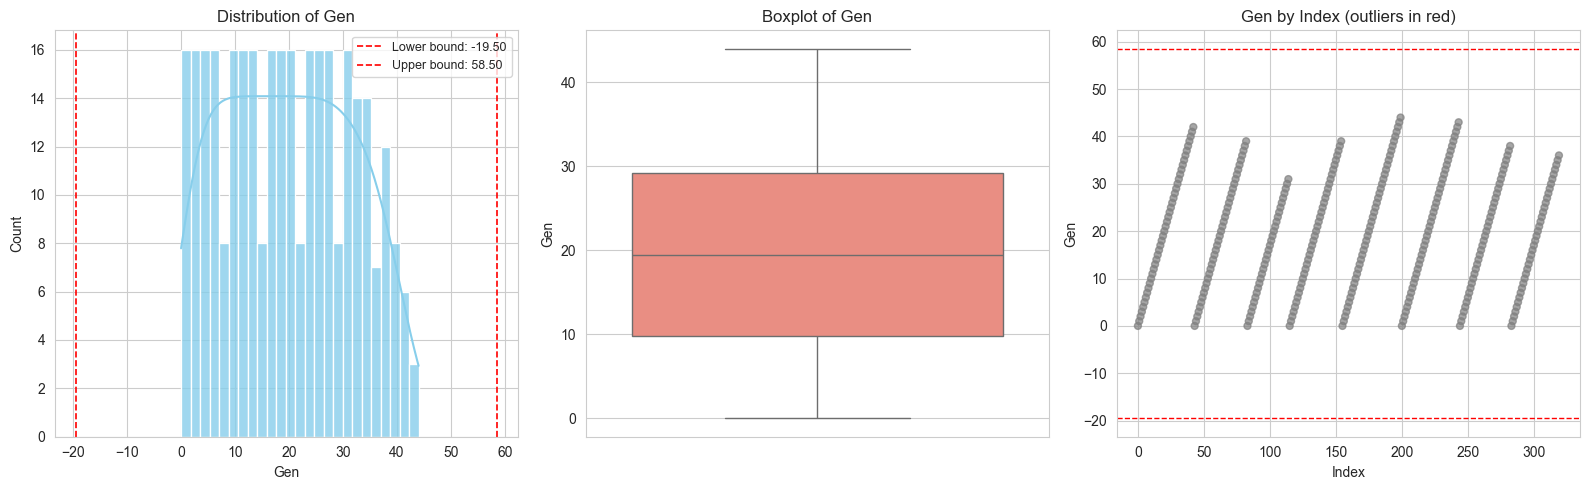

Shapiro-Wilk: p = 0.0000
Skewness: 0.108
Outliers (IQR): 0 (0.0%)
Bounds: [-0.050, 0.350]


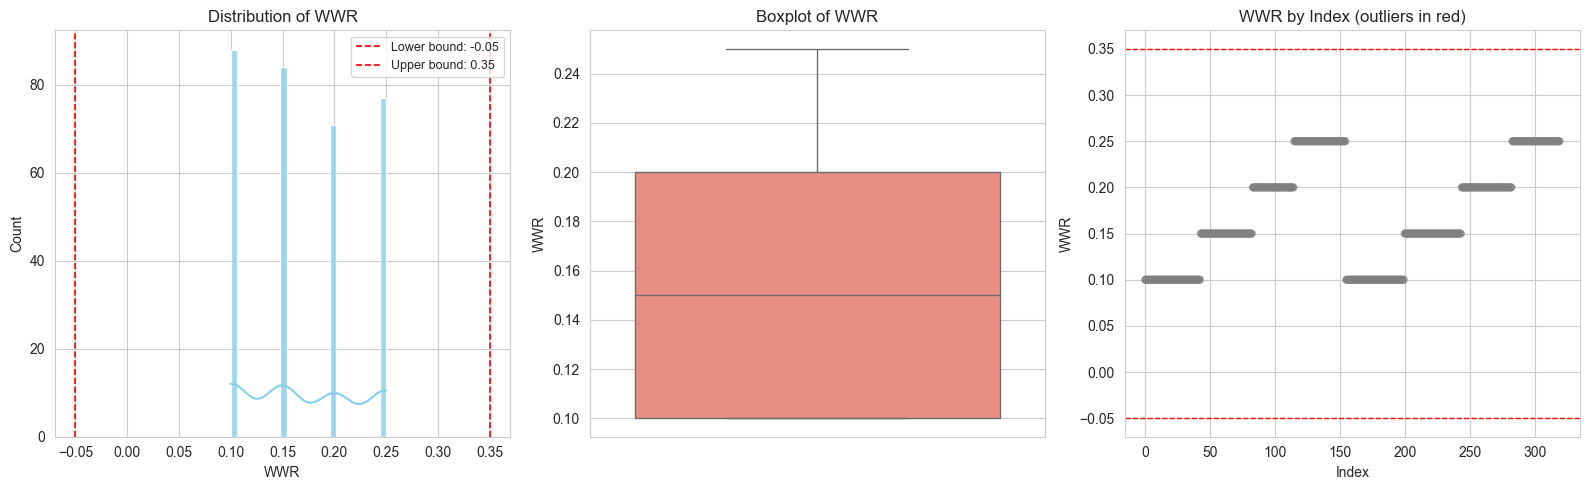

Shapiro-Wilk: p = 0.0000
Skewness: -0.135
Outliers (IQR): 0 (0.0%)
Bounds: [-0.128, 0.293]


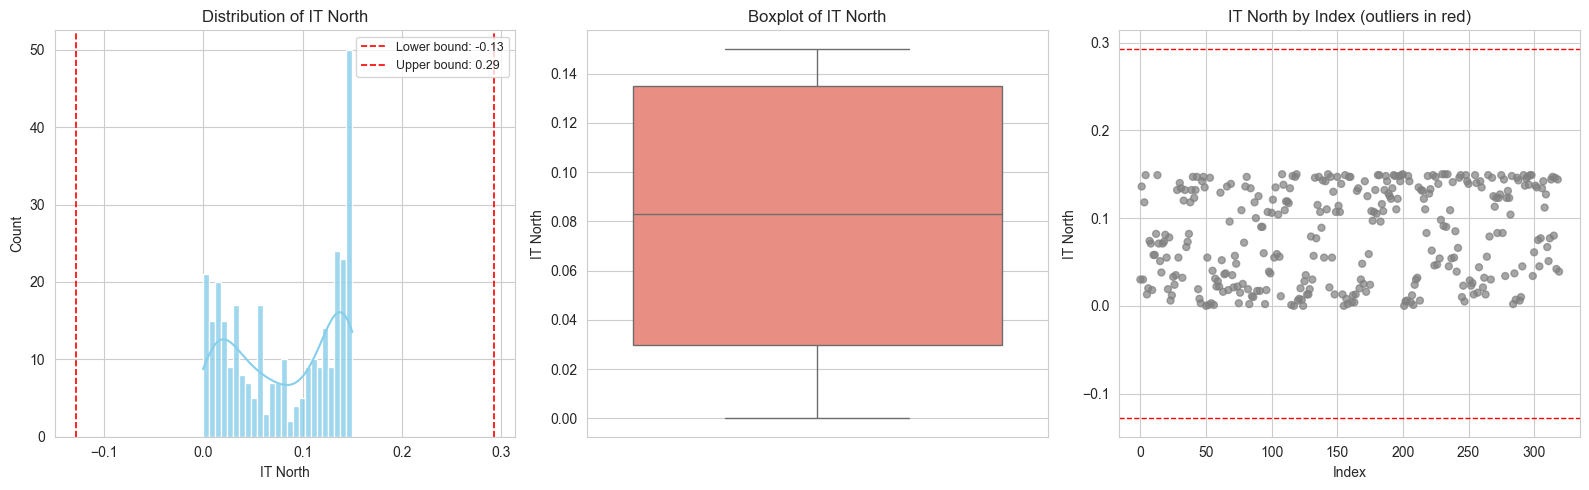

Shapiro-Wilk: p = 0.0000
Skewness: 1.495
Outliers (IQR): 17 (5.3%)
Bounds: [-0.694, 1.956]

   Outlier data points:
     Unorth
46     2.20
50     2.57
52     2.50
54     2.16
56     2.51
75     2.22
83     2.27
95     2.31
115    2.51
117    2.52
124    2.53
155    2.57
158    2.31
161    2.14
163    2.06
247    1.98
284    2.36


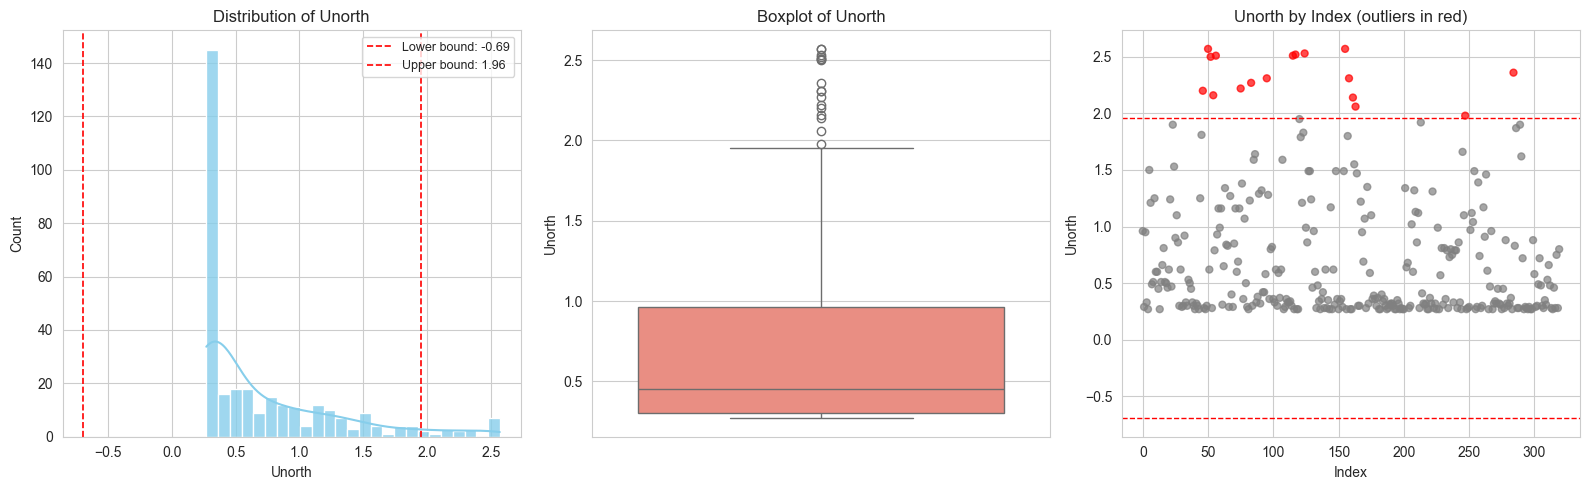

Shapiro-Wilk: p = 0.0000
Skewness: -0.141
Outliers (IQR): 0 (0.0%)
Bounds: [-0.086, 0.255]


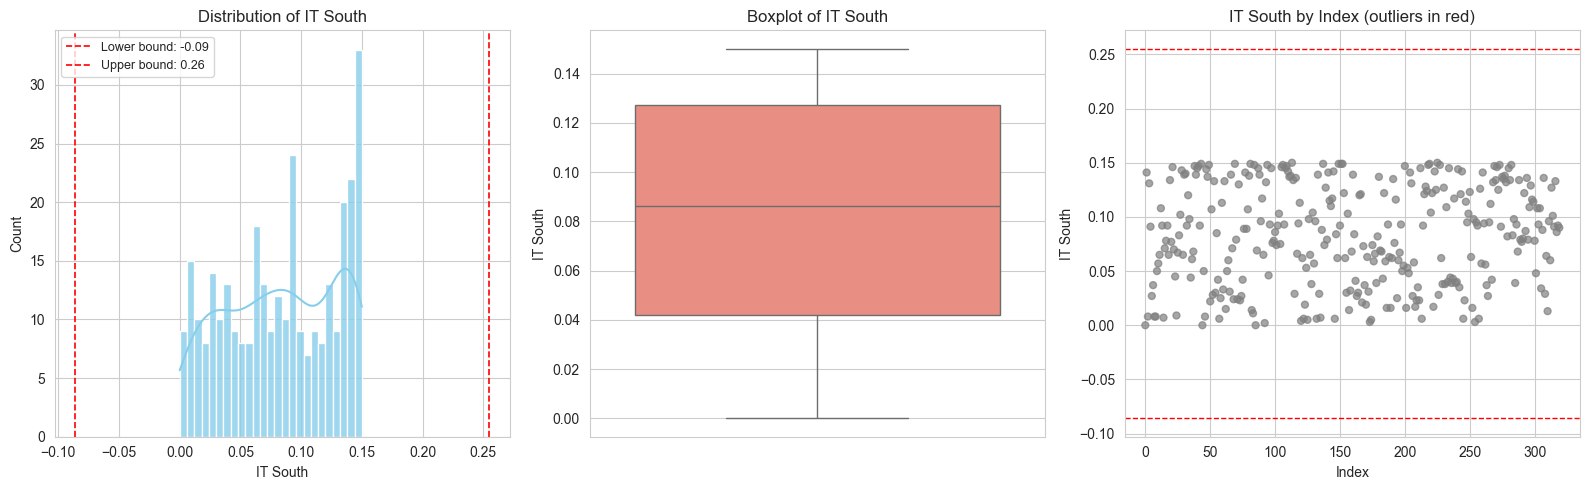

Shapiro-Wilk: p = 0.0000
Skewness: 1.974
Outliers (IQR): 35 (10.9%)
Bounds: [-0.279, 1.291]

   Outlier data points:
     Usouth
0      2.50
2      1.80
7      1.80
8      1.80
14     1.80
24     1.70
44     2.56
46     1.80
57     1.94
62     1.41
82     1.45
83     1.58
85     2.52
92     2.31
120    2.11
122    1.96
125    2.05
132    1.94
135    1.86
146    1.94
157    1.45
173    2.21
174    2.02
186    1.34
189    1.34
202    1.55
203    1.78
207    2.16
211    1.48
222    1.38
245    1.90
252    1.34
254    2.24
257    1.90
310    1.47


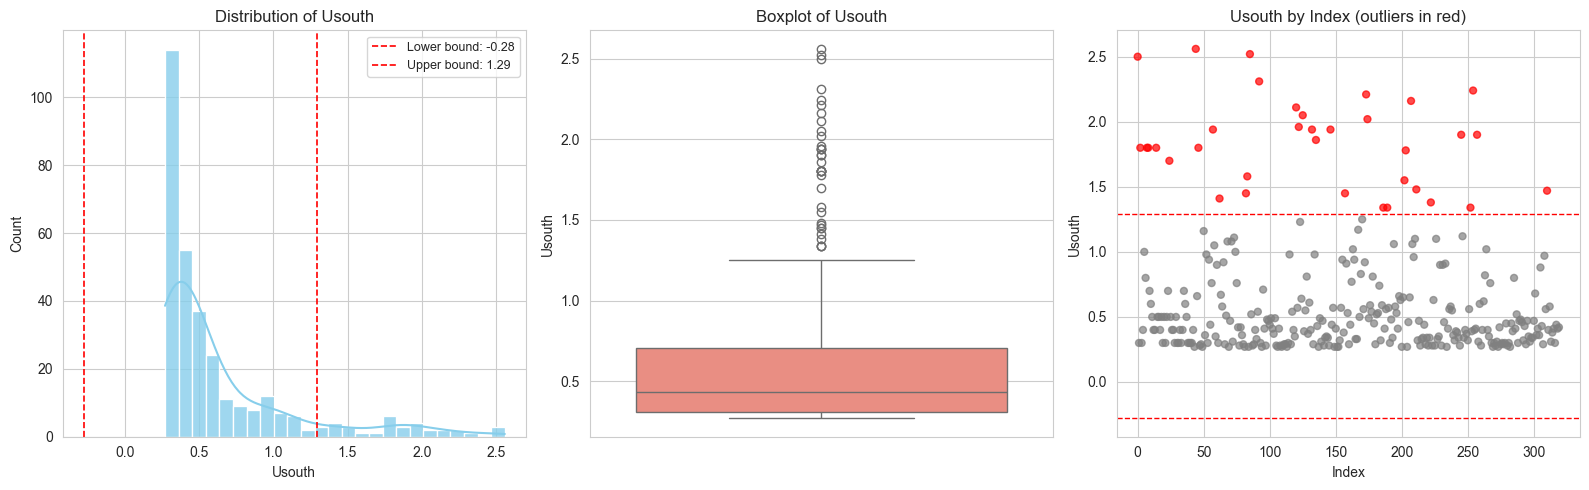

Shapiro-Wilk: p = 0.0000
Skewness: -0.099
Outliers (IQR): 0 (0.0%)
Bounds: [-0.092, 0.244]


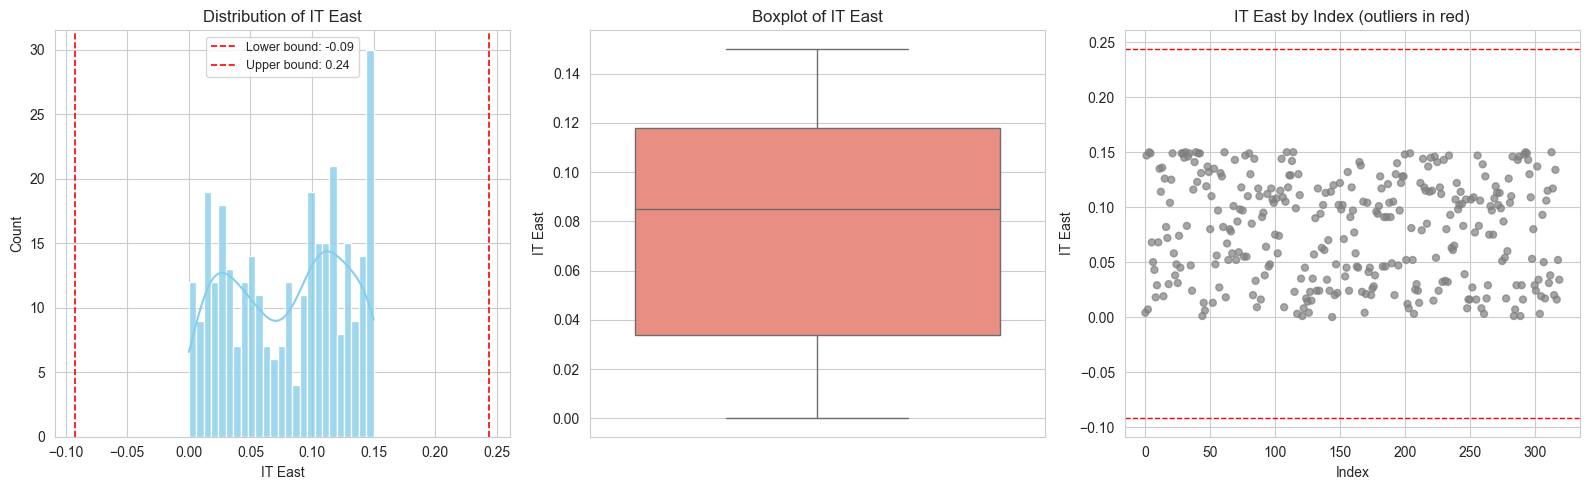

Shapiro-Wilk: p = 0.0000
Skewness: 1.667
Outliers (IQR): 23 (7.2%)
Bounds: [-0.499, 1.711]

   Outlier data points:
     Ueast
0     2.09
2     1.88
44    2.42
46    1.93
86    1.74
107   1.74
117   2.26
121   2.48
122   1.80
126   2.13
144   2.56
169   2.09
210   1.97
213   2.05
235   2.27
237   2.14
248   1.80
259   1.75
261   2.19
284   2.50
285   1.82
289   2.50
304   2.18


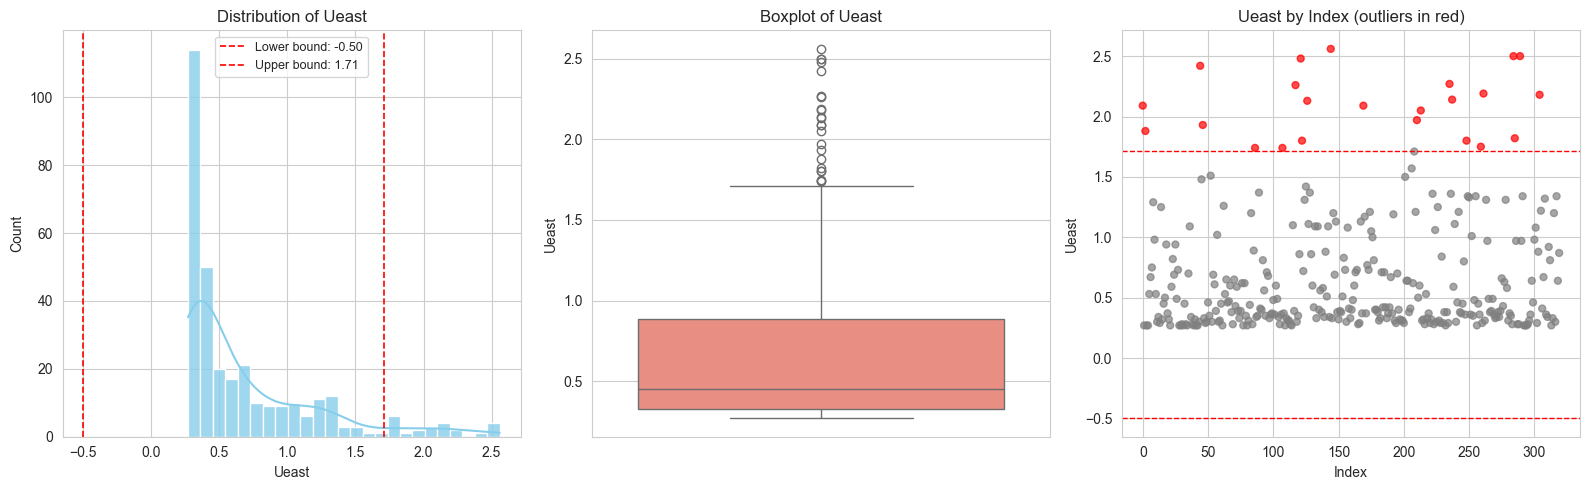

Shapiro-Wilk: p = 0.0000
Skewness: 0.099
Outliers (IQR): 0 (0.0%)
Bounds: [-0.119, 0.266]


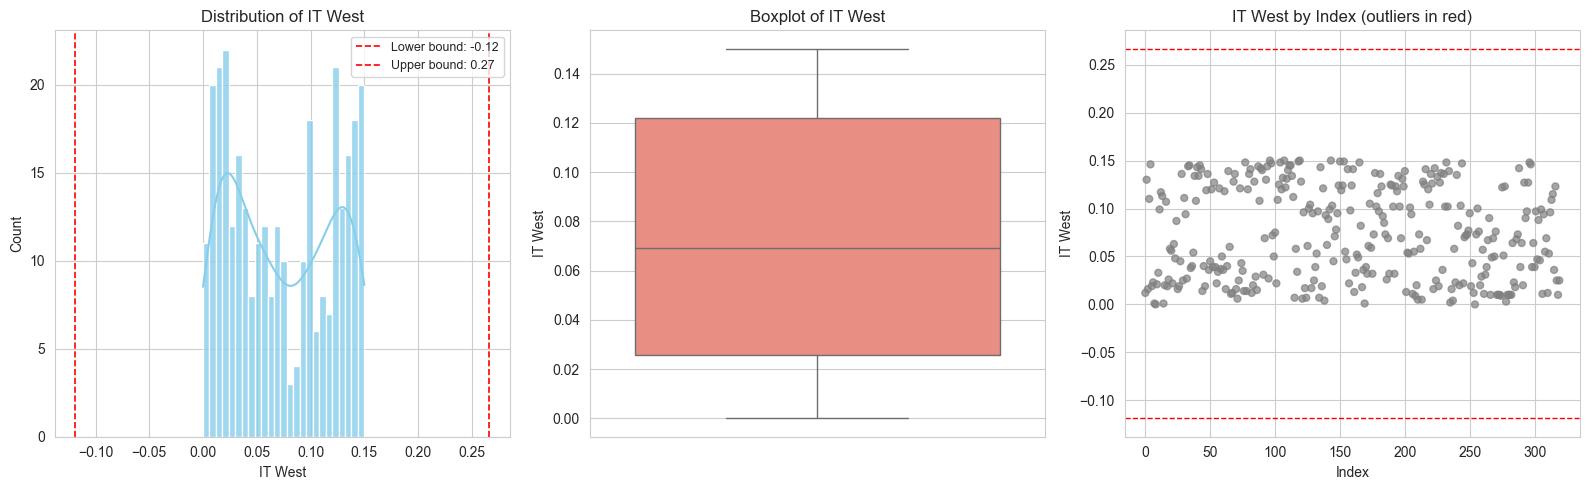

Shapiro-Wilk: p = 0.0000
Skewness: 1.426
Outliers (IQR): 8 (2.5%)
Bounds: [-0.655, 1.945]

   Outlier data points:
     Uwest
7     2.51
8     2.57
14    2.48
71    1.96
138   2.11
169   2.39
254   2.53
278   2.16


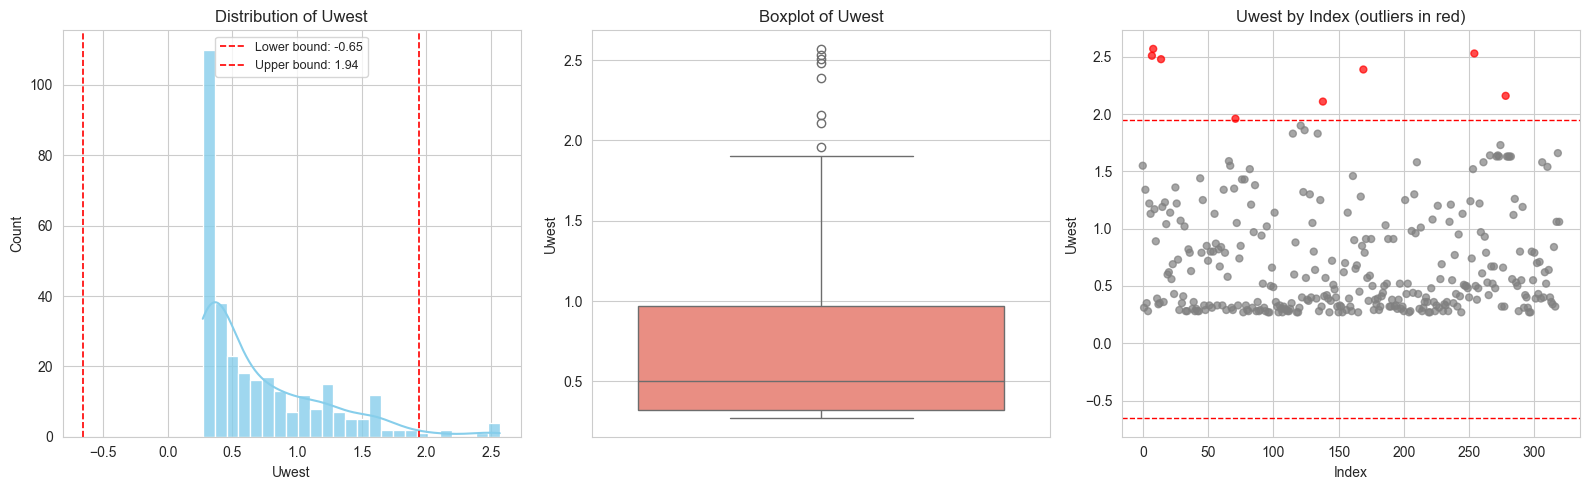

Shapiro-Wilk: p = 0.0000
Skewness: 1.112
Outliers (IQR): 4 (1.2%)
Bounds: [-0.603, 2.018]

   Outlier data points:
     Uwall
0     2.16
44    2.33
46    2.17
121   2.09


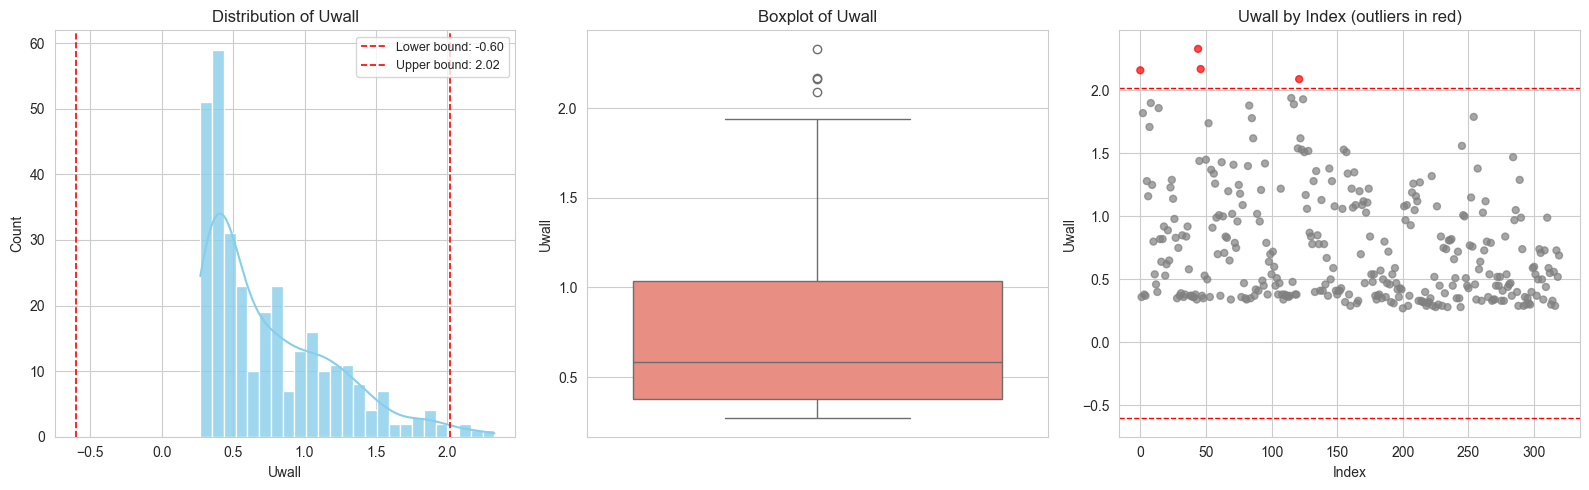

Shapiro-Wilk: p = 0.0000
Skewness: -0.390
Outliers (IQR): 0 (0.0%)
Bounds: [-0.079, 0.257]


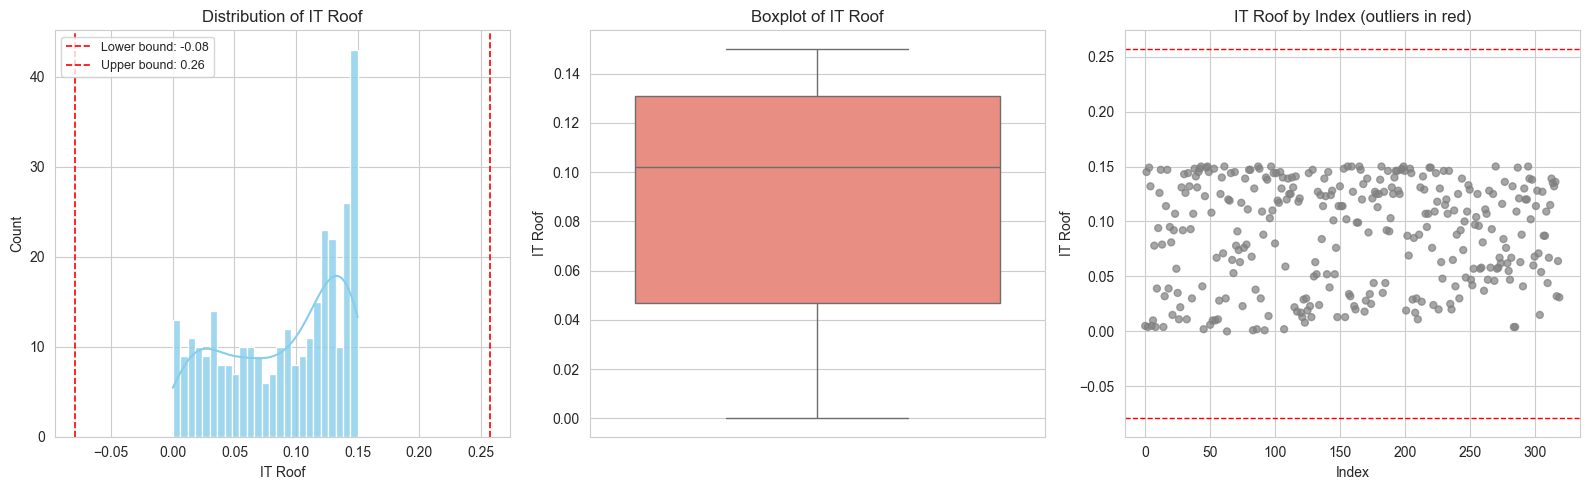

Shapiro-Wilk: p = 0.0000
Skewness: 1.946
Outliers (IQR): 29 (9.1%)
Bounds: [-0.270, 1.250]

   Outlier data points:
     Uroof
0     1.85
2     1.90
5     1.82
6     1.52
8     1.94
14    1.93
21    1.31
26    1.47
32    1.47
45    2.06
50    1.79
52    1.53
54    1.53
56    1.46
63    2.28
83    2.22
86    2.08
92    2.17
95    1.36
107   2.08
121   1.36
123   1.63
128   1.36
148   1.36
154   1.36
210   1.47
284   1.93
285   1.89
304   1.31


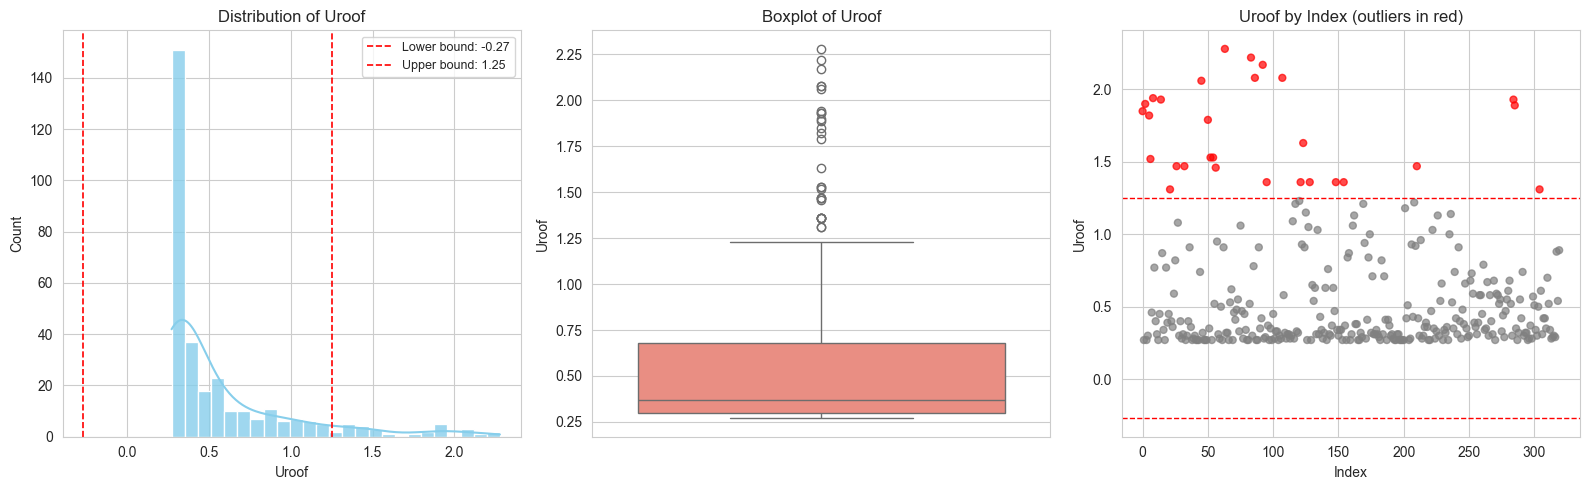

Shapiro-Wilk: p = 0.0000
Skewness: 0.918
Outliers (IQR): 0 (0.0%)
Bounds: [-0.260, 1.020]


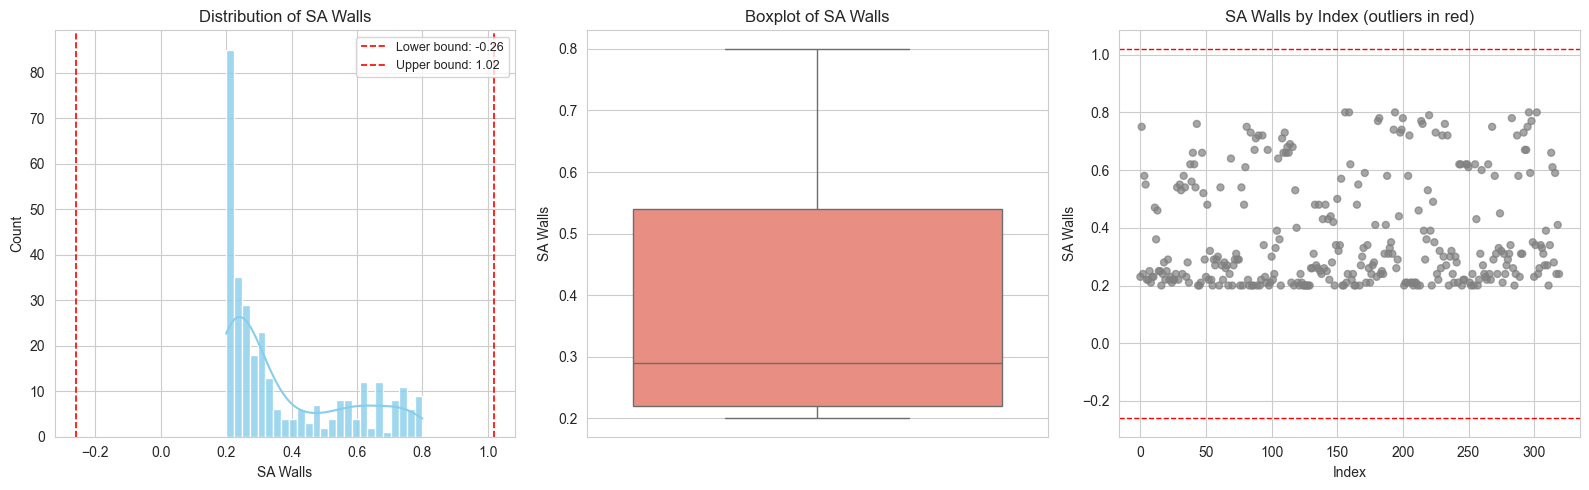

Shapiro-Wilk: p = 0.0000
Skewness: 0.761
Outliers (IQR): 0 (0.0%)
Bounds: [-0.159, 0.931]


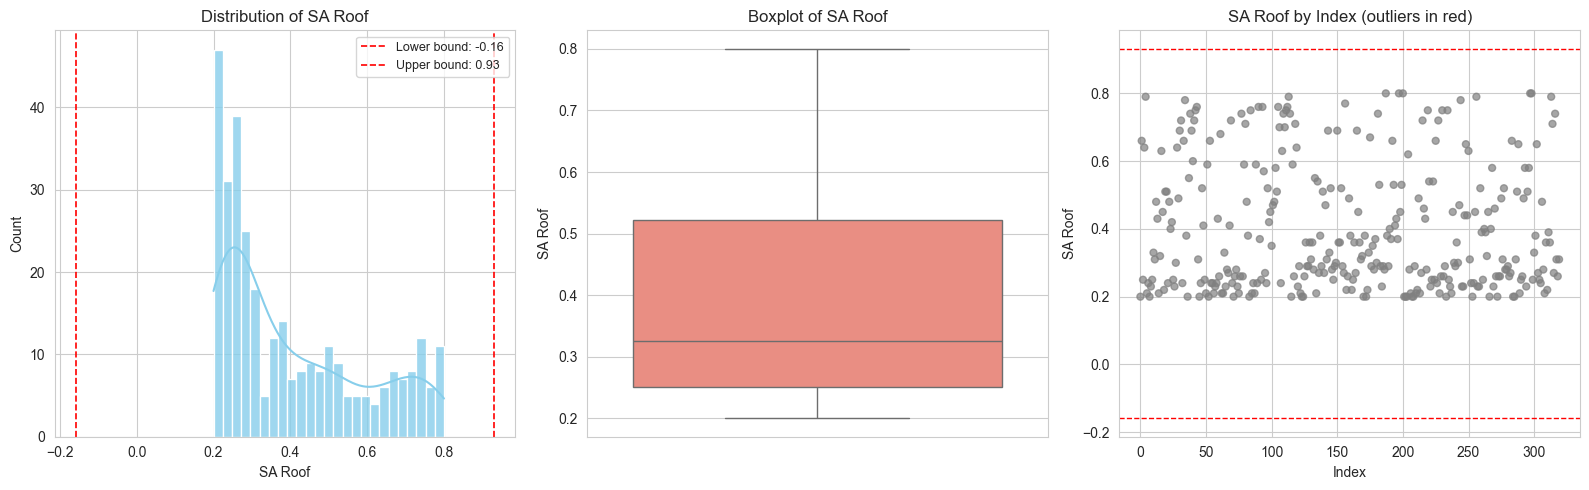

Shapiro-Wilk: p = 0.0000
Skewness: -0.005
Outliers (IQR): 0 (0.0%)
Bounds: [-0.003, 0.016]


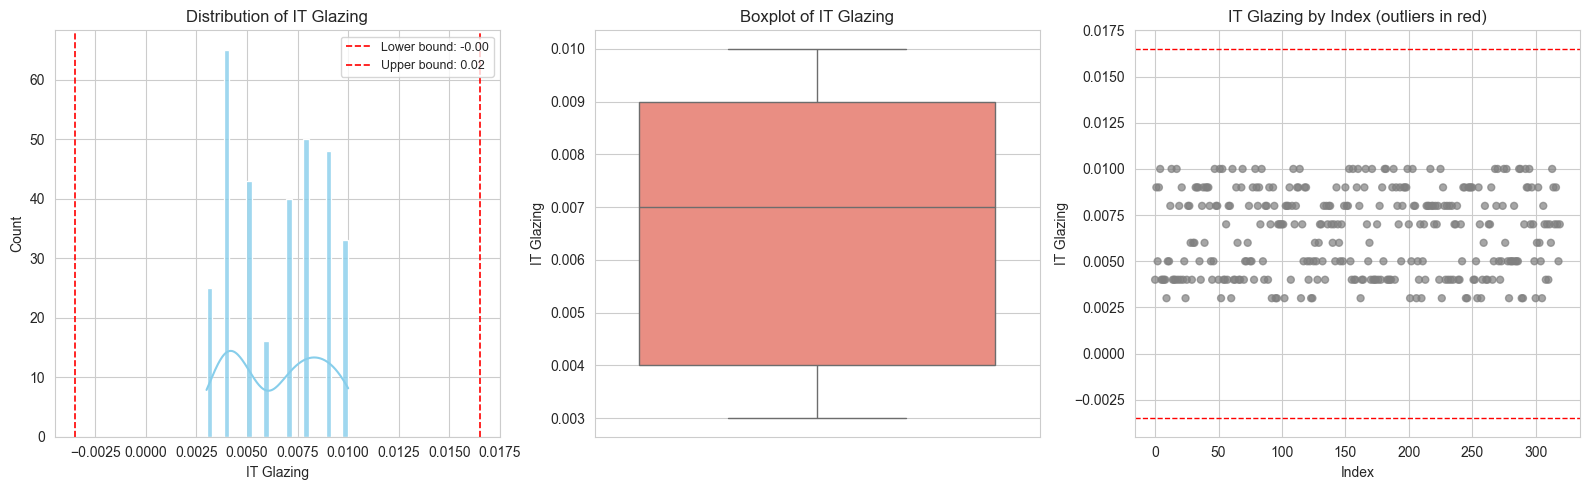

Shapiro-Wilk: p = 0.0000
Skewness: -0.070
Outliers (IQR): 47 (14.7%)
Bounds: [20.321, 24.051]

   Outlier data points:
     Setpoint
1       24.58
3       24.99
33      24.71
38      24.99
41      24.95
43      24.96
44      19.05
48      24.72
69      24.17
77      24.78
81      24.88
83      18.93
84      24.20
85      20.16
87      24.57
109     24.51
110     24.59
113     24.50
114     24.51
115     18.39
116     24.71
120     18.65
123     18.88
124     18.90
156     24.81
157     19.60
160     24.08
161     20.03
200     24.07
201     19.44
205     24.57
206     19.45
208     19.53
219     25.00
225     24.95
232     24.88
244     24.23
245     19.79
249     24.09
252     20.26
254     19.75
257     19.29
284     19.18
285     19.63
289     19.34
313     24.76
316     24.37


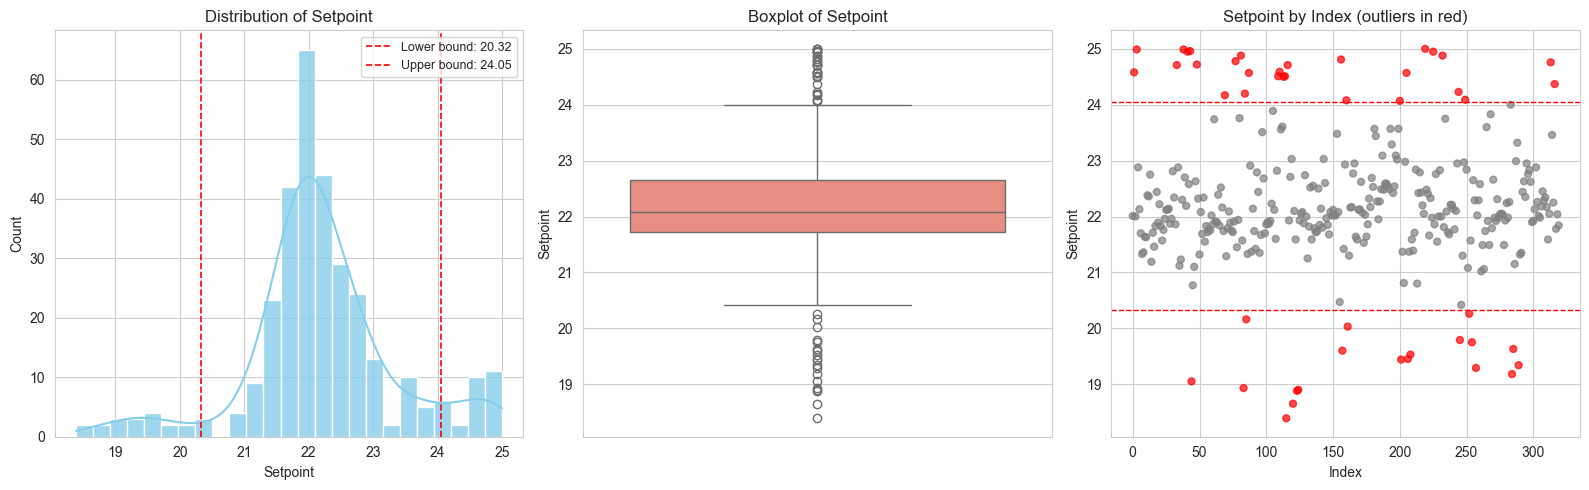

Shapiro-Wilk: p = 0.0000
Skewness: 1.132
Outliers (IQR): 25 (7.8%)
Bounds: [10.657, 62.338]

   Outlier data points:
     Cooling demand
156           66.58
160           62.83
181           66.30
182           65.25
187           63.66
193           64.93
194           64.24
197           63.89
198           64.20
199           64.99
200           66.76
205           63.35
219           64.60
225           65.69
232           63.49
234           66.21
244           67.12
249           65.09
265           65.39
268           67.05
283           68.89
288           67.63
313           68.78
314           68.14
316           68.06


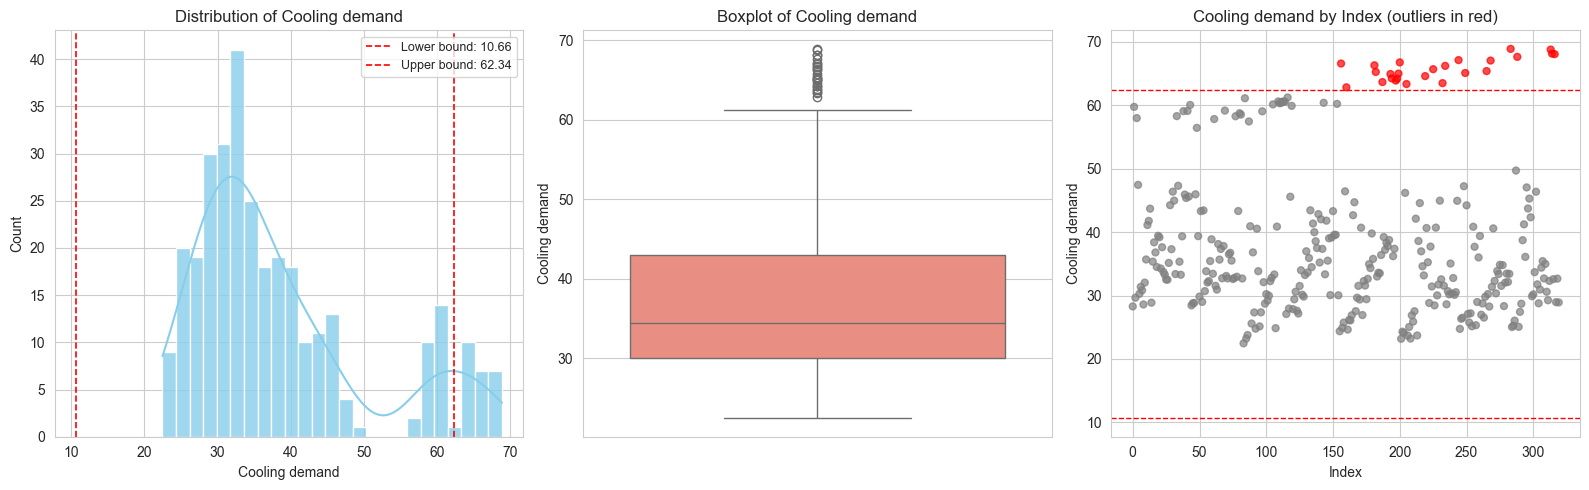

Shapiro-Wilk: p = 0.0000
Skewness: 2.863
Outliers (IQR): 33 (10.3%)
Bounds: [-8.549, 15.981]

   Outlier data points:
     Heating demand
0             19.70
2             16.48
8             17.56
14            17.53
44            32.28
45            28.13
83            52.44
85            45.23
86            16.94
115           48.61
117           24.82
120           42.57
121           18.11
123           42.93
124           48.07
155           46.51
157           39.44
158           18.19
161           44.10
201           55.26
203           44.55
206           48.55
208           54.80
213           46.70
245           49.00
246           40.86
252           42.79
254           46.28
257           44.95
284           74.29
285           56.16
286           17.17
289           63.90


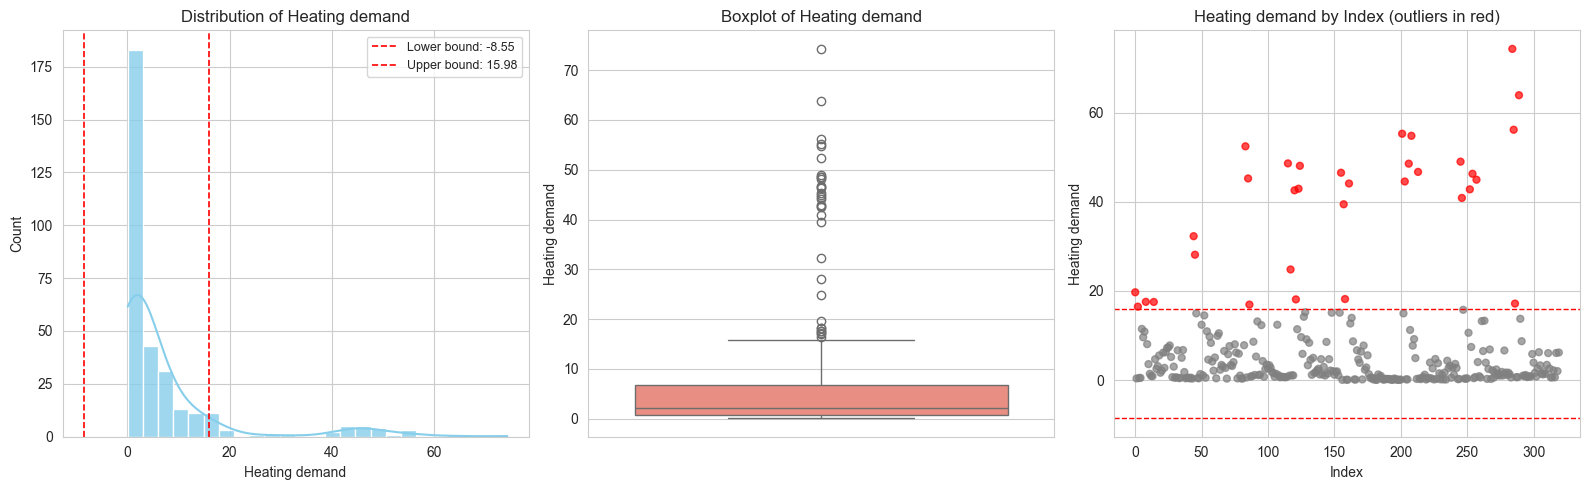

Shapiro-Wilk: p = 0.0000
Skewness: 1.291
Outliers (IQR): 34 (10.6%)
Bounds: [18.045, 65.585]

   Outlier data points:
     Total demand
83          74.90
85          68.46
115         75.70
120         70.43
123         70.54
124         75.24
155         70.89
156         66.63
161         68.74
181         66.36
200         66.90
201         78.45
203         68.66
206         72.24
208         78.02
213         70.41
225         65.83
234         66.35
244         67.38
245         73.75
246         67.20
252         68.54
254         71.44
257         70.28
265         65.68
268         67.32
283         69.50
284         99.33
285         81.42
288         68.29
289         88.97
313         69.39
314         68.76
316         68.69


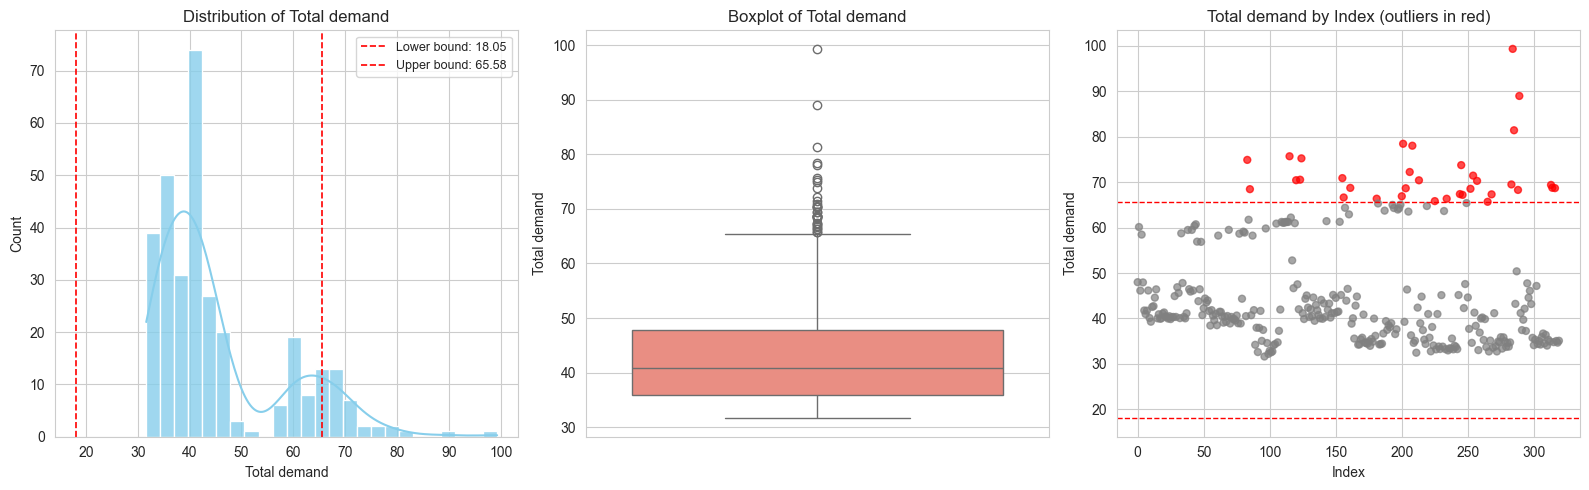

        Column  Sample_Size  Skewness  Shapiro_p Normal  Outliers Outlier_Percentage
           Gen          320     0.081        0.0     No         0               0.0%
           WWR          320     0.108        0.0     No         0               0.0%
      IT North          320    -0.135        0.0     No         0               0.0%
        Unorth          320     1.495        0.0     No        17               5.3%
      IT South          320    -0.141        0.0     No         0               0.0%
        Usouth          320     1.974        0.0     No        35              10.9%
       IT East          320    -0.099        0.0     No         0               0.0%
         Ueast          320     1.667        0.0     No        23               7.2%
       IT West          320     0.099        0.0     No         0               0.0%
         Uwest          320     1.426        0.0     No         8               2.5%
         Uwall          320     1.112        0.0     No         4

In [35]:
df_summary = analyze_outliers_and_normality(optimizations)

## Normalizing the data with RobustScaler

During the multi-objective optimization process with NSGA-II, the algorithm explores a wide range of architectural configurations, from highly insulated façades (U = 0.01 W/m²K) to poorly insulated ones (U = 2.60 W/m²K), from minimal glazing thickness to heavy envelope solutions, and from low to high window-to-wall ratios. As a result, the dataset contains extreme but physically meaningful values that emerge from specific design combinations rather than measurement errors or noise.

These extreme values are not outliers in the traditional sense, they are valid, feasible solutions generated by the evolutionary algorithm to explore the full extent of the design space. They represent critical edge cases that help define the boundaries of energy performance: how much heating demand increases when insulation is reduced, or how cooling spikes under high solar gain scenarios. Excluding them would bias the model toward average behavior and reduce its ability to generalize across realistic design conditions.

For machine learning, it is essential not to discard these boundary cases, as they contain valuable information about system behavior under stress or suboptimal conditions. However, standard scaling methods like StandardScaler (which uses mean and standard deviation) are highly sensitive to such extremes, potentially distorting feature distributions and reducing model performance.

To preserve this rich variability while ensuring numerical stability, it was chose the RobustScaler. This scaler uses the median and the interquartile range (IQR), measures inherently resistant to outliers, to center and scale the data. By doing so, it maintains the relative distances between typical and extreme values without allowing the latter to dominate the transformation.

This makes RobustScaler particularly well-suited for our dataset, where:

Features do not follow a normal distribution, outliers are informative, not erroneous, generalization across diverse architectural strategies is key.
By using RobustScaler, we ensure that the model learns from the entire spectrum of design possibilities, improving its robustness and predictive accuracy in real-world applications.

# Machine Learnig Instructions

### Models train and test

In [36]:
# Convert 'WWR' column to float
if 'WWR' in optimizations.columns and optimizations['WWR'].dtype == 'object':
    optimizations['WWR'] = optimizations['WWR'].astype(str).str.replace(',', '.', regex=False).astype(float)

X = optimizations[features_without_shape].copy()  

# Target variables (outputs)
y_cooling = optimizations['Cooling demand'].copy()   
y_heating = optimizations['Heating demand'].copy()   

In [37]:

# Create pipelines with unfitted models (no training yet)
model_cooling = Pipeline([
    ('scaler', RobustScaler()),  # Robust scaling using median and IQR (handles outliers well)
    ('rf', RandomForestRegressor(
        n_estimators=100,         # Number of trees in the forest
        random_state=42,          # Seed for reproducibility
        max_depth=None,           # No maximum depth (fully grown trees)
        min_samples_split=2,      # Minimum samples required to split a node
        min_samples_leaf=1        # Minimum samples required at each leaf
    ))
])

# Same pipeline structure for heating demand
model_heating = Pipeline([
    ('scaler', RobustScaler()),
    ('rf', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ))
])

# Polynominal Model Cooling
model_poly_cooling = Pipeline([
    ('scaler', RobustScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('rf', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ))
])

# Polynominal Model Heating
model_poly_heating = Pipeline([
    ('scaler', RobustScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('rf', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ))
])

In [38]:
# Estimator models to cross_validation: are the unfitted model objects that can be used for proper cross-validation.
model_cooling_estimator = RandomForestRegressor(random_state=42)
model_heating_estimator = RandomForestRegressor(random_state=42)
model_poly_cooling_estimator = Pipeline([('poly', PolynomialFeatures(degree=2)), ('rf', RandomForestRegressor(random_state=42))])
model_poly_heating_estimator = Pipeline([('poly', PolynomialFeatures(degree=2)), ('rf', RandomForestRegressor(random_state=42))])

print('Estimators finalized')

Estimators finalized


In [39]:
# Split the data into training (80%) and testing (20%)
X_train, X_test, y_cooling_train, y_cooling_test, y_heating_train, y_heating_test = train_test_split(
    X, y_cooling, y_heating,
    test_size=0.2,
    random_state=42
)

# Train the models
model_cooling.fit(X_train, y_cooling_train)  
model_heating.fit(X_train, y_heating_train)  

# Train polynomial models 
model_poly_cooling.fit(X_train, y_cooling_train)  
model_poly_heating.fit(X_train, y_heating_train)  

# Make predictions on test set
y_cooling_pred = model_cooling.predict(X_test) 
y_heating_pred = model_heating.predict(X_test)

y_cooling_poly_pred = model_poly_cooling.predict(X_test)
y_heating_poly_pred = model_poly_heating.predict(X_test)

print('Training, Test and Predict Done!!!')

Training, Test and Predict Done!!!


In [40]:
# RF Model Metrics
cooling_rf_rmse = np.sqrt(mean_squared_error(y_cooling_test, y_cooling_pred))
heating_rf_rmse = np.sqrt(mean_squared_error(y_heating_test, y_heating_pred))
cooling_rf_r2 = r2_score(y_cooling_test, y_cooling_pred)
heating_rf_r2 = r2_score(y_heating_test, y_heating_pred)

# Poly Model Metrics
cooling_poly_rmse = np.sqrt(mean_squared_error(y_cooling_test, y_cooling_poly_pred))
heating_poly_rmse = np.sqrt(mean_squared_error(y_heating_test, y_heating_poly_pred))
cooling_poly_r2 = r2_score(y_cooling_test, y_cooling_poly_pred)
heating_poly_r2 = r2_score(y_heating_test, y_heating_poly_pred)

# Estimator models (not trained models)
estimator_models = {
    "Cooling_RF": model_cooling_estimator,
    "Heating_RF": model_heating_estimator,
    "Cooling_RF_Poly": model_poly_cooling_estimator,
    "Heating_RF_Poly": model_poly_heating_estimator
}

scoring = {
    "mse": "neg_mean_squared_error",   # Will convert to positive
    "mae": "neg_mean_absolute_error",  # Will convert to positive
    "r2": "r2"
}

# Cross-validation results using estimators (not pre-trained models)
results = []
std_devs = {}

for name, estimator in estimator_models.items(): # HERE ESTIMATOR!!!
    y_target = y_cooling if "Cooling" in name else y_heating

    # Cross-validation on the estimators (this will train new models for each fold)
    scores = cross_validate(estimator, X, y_target, cv=5, scoring=scoring, return_train_score=False)

    # Convert negative errors to positive
    mse = -scores['test_mse']
    mae = -scores['test_mae']
    rmse = np.sqrt(mse)
    r2 = scores['test_r2']

    # Save means for table
    results.append({
        "Model": name,
        "MSE Mean": mse.mean(),
        "RMSE Mean": rmse.mean(),
        "MAE Mean": mae.mean(),
        "R² Mean": r2.mean()
    })

    # Save std deviations separately
    std_devs[name] = {
        "MSE Std": mse.std(),
        "RMSE Std": rmse.std(),
        "MAE Std": mae.std(),
        "R² Std": r2.std()
    }

# Results table (means only)
results_df = pd.DataFrame(results)
results_df

,Model,MSE Mean,RMSE Mean,MAE Mean,R² Mean
0,Cooling_RF,12.230513,3.472918,2.845478,0.898652
1,Heating_RF,16.313127,3.903315,1.910852,0.834020
2,Cooling_RF_Poly,14.202007,3.751140,3.156042,0.884159
3,Heating_RF_Poly,15.478317,3.766077,1.856465,0.854688


In [41]:
# Standard deviations reported separately
std_df = pd.DataFrame(std_devs).T
std_df

,MSE Std,RMSE Std,MAE Std,R² Std
Cooling_RF,2.999646,0.411523,0.367909,0.058846
Heating_RF,7.713273,1.037909,0.330631,0.181529
Cooling_RF_Poly,2.748581,0.361882,0.336480,0.059271
Heating_RF_Poly,8.441848,1.137974,0.303610,0.145115


In [42]:
# Function to build comparison between baseline and polynomial
def build_comparison(base, poly):
    base_row = results_df[results_df["Model"] == base].iloc[0]
    poly_row = results_df[results_df["Model"] == poly].iloc[0]

    return {
        "Target": base.split("_")[0],   # Cooling or Heating
        "Baseline R²": base_row["R² Mean"],
        "Poly R²": poly_row["R² Mean"],
        "Δ R²": poly_row["R² Mean"] - base_row["R² Mean"],
        "Baseline RMSE": base_row["RMSE Mean"],
        "Poly RMSE": poly_row["RMSE Mean"],
        "Δ RMSE": poly_row["RMSE Mean"] - base_row["RMSE Mean"]
    }

# Comparisons
comparison_data = [
    build_comparison("Cooling_RF", "Cooling_RF_Poly"),
    build_comparison("Heating_RF", "Heating_RF_Poly")
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Target,Baseline R²,Poly R²,Δ R²,Baseline RMSE,Poly RMSE,Δ RMSE
0,Cooling,0.898652,0.884159,-0.014493,3.472918,3.751140,0.278221
1,Heating,0.834020,0.854688,0.020668,3.903315,3.766077,-0.137239


# Model Evaluation

### Analysis of Model Performance: Baseline vs. Polynomial Features:

The table shows that adding selected polynomial interactions improves predictive performance for heating demand but has a slight negative impact on cooling demand.

Cooling Demand: R² decreases by -0.014493, indicating that the interaction terms do not capture meaningful nonlinear relationships and may introduce noise. RMSE increases by +0.278221, suggesting that the polynomial model performs worse overall with higher prediction errors. This suggests that cooling demand may be better modeled by linear relationships, and the polynomial transformation may be overfitting the data.

Heating Demand: R² improves by +0.020668, which is more substantial. RMSE decreases by -0.137239, meaning the model now predicts heating demand with higher accuracy and lower error. This suggests that interactions like Unorth × Setpoint or Usouth × SA Walls help the model better understand how insulation and ventilation interact in winter conditions.

For this matter, for the rest of the analysis it was chosen to use the Random Forest models with baseline features for cooling demand and polynomial features for heating demand to leverage the best performance of each approach.

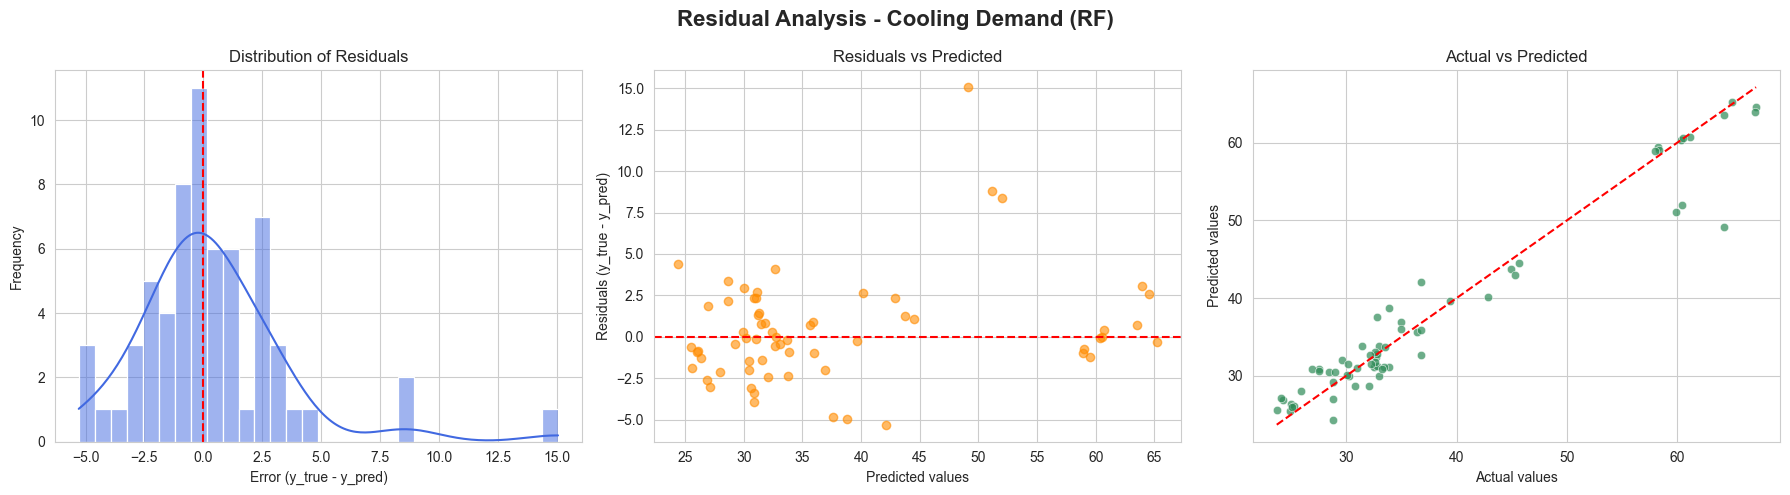

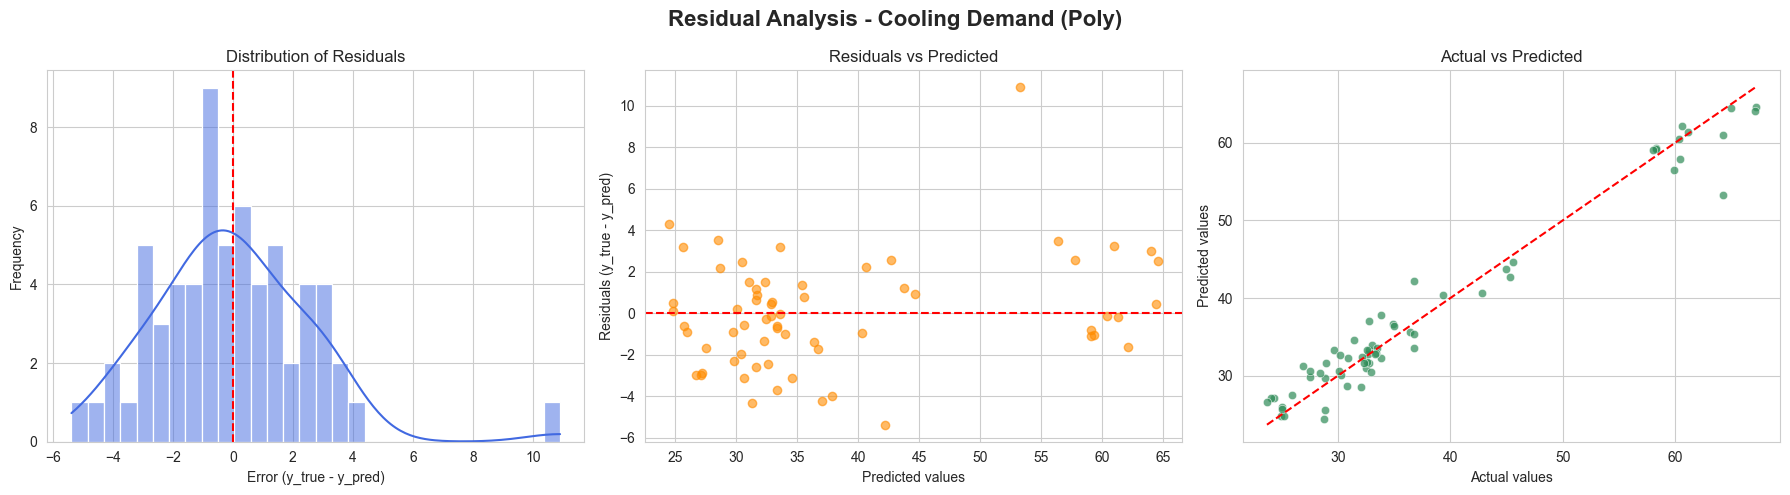

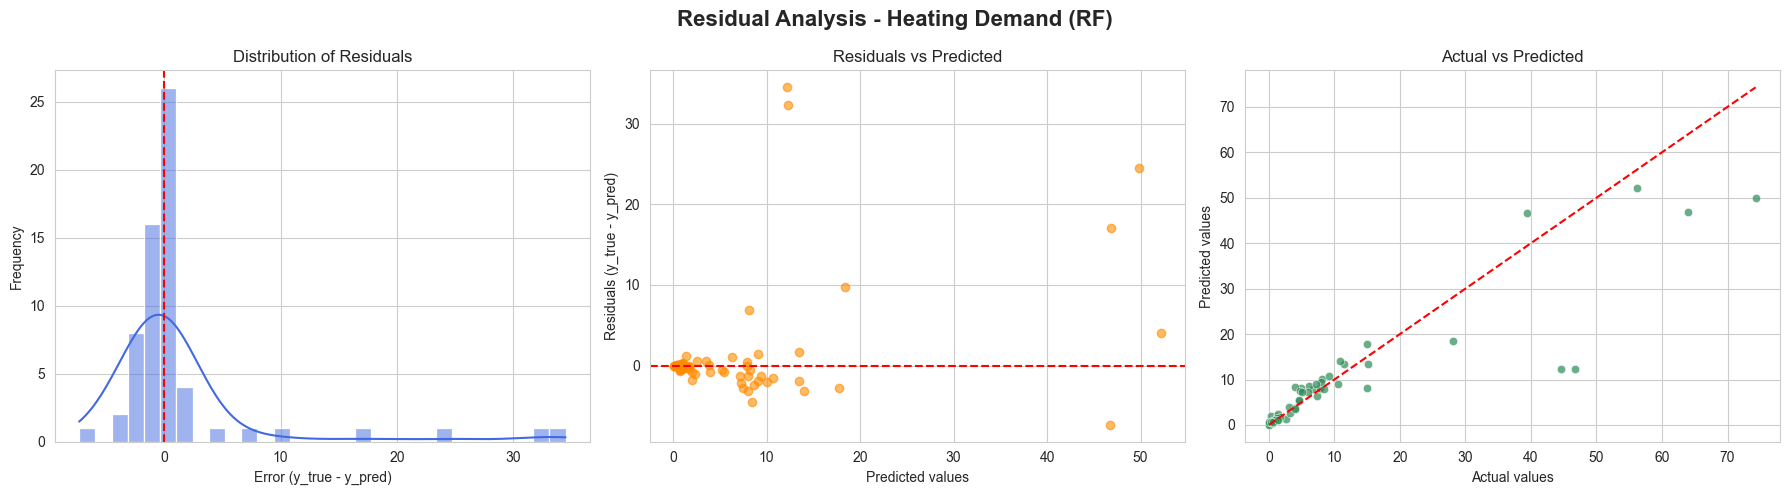

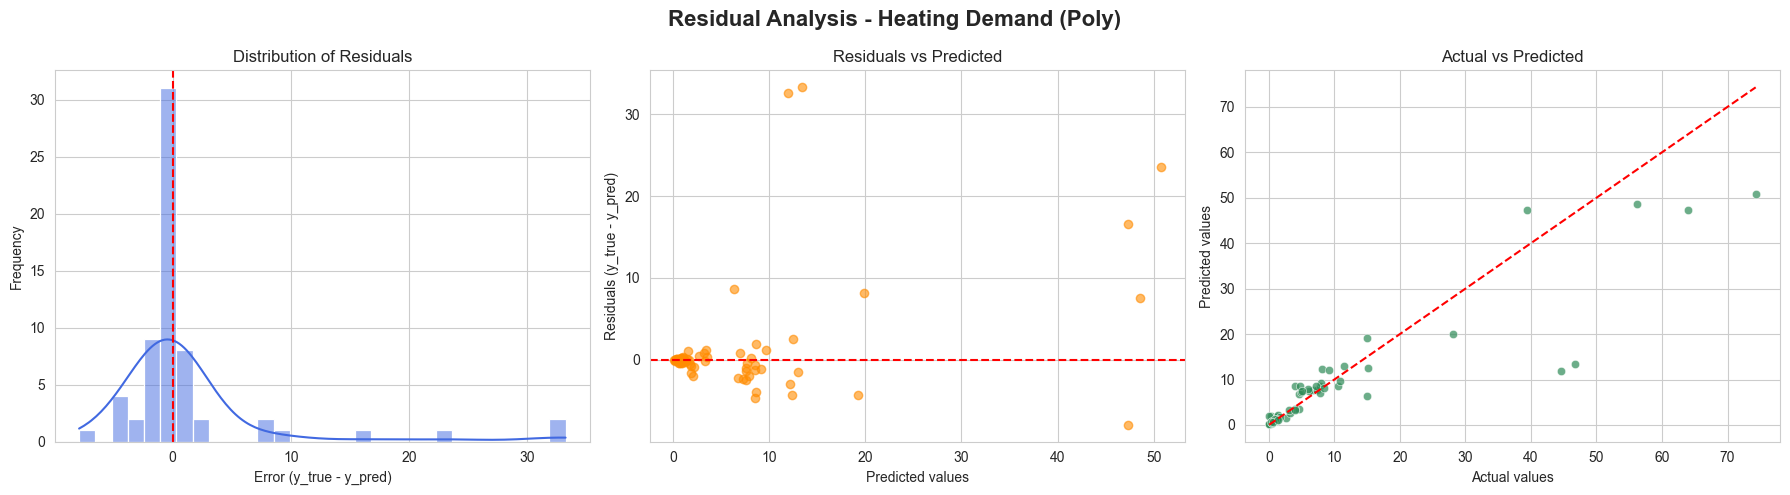

In [43]:
# Generate residual analysis trained model.
def residual_analysis(y_test, y_pred, target_name):
    
    # Calculate residuals
    residuals = y_test - y_pred

    # 3 subplots in one row
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Residual Analysis - {target_name}", fontsize=16, fontweight='bold')

    # 1. Distribution of Residuals
    sns.histplot(residuals, bins=30, kde=True, color="royalblue", ax=axes[0])
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title("Distribution of Residuals", fontsize=12)
    axes[0].set_xlabel("Error (y_true - y_pred)")
    axes[0].set_ylabel("Frequency")

    # 2. Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.6, color="darkorange")
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title("Residuals vs Predicted", fontsize=12)
    axes[1].set_xlabel("Predicted values")
    axes[1].set_ylabel("Residuals (y_true - y_pred)")

    # 3. Actual vs Predicted
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="seagreen", ax=axes[2])
    axes[2].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 color='red', linestyle='--')  # ideal line
    axes[2].set_title("Actual vs Predicted", fontsize=12)
    axes[2].set_xlabel("Actual values")
    axes[2].set_ylabel("Predicted values")

    plt.tight_layout()
    plt.show()

# Residual analysis for all models using test data only
residual_analysis(y_cooling_test, y_cooling_pred, "Cooling Demand (RF)")
residual_analysis(y_cooling_test, y_cooling_poly_pred, "Cooling Demand (Poly)")

residual_analysis(y_heating_test, y_heating_pred, "Heating Demand (RF)")
residual_analysis(y_heating_test, y_heating_poly_pred, "Heating Demand (Poly)")

Both models demonstrate strong predictive performance, with residuals generally centered around zero and no obvious patterns in the residuals vs predicted plots. The slight deviations from perfect normality and the presence of a few outliers suggest room for improvement, particularly in handling extreme values. The models appear to capture the main relationships well, with minor systematic biases that could be addressed through further refinement or feature engineering.

# Model Interpretability

## Sensivity analysis of the models

### Global Feature Importances

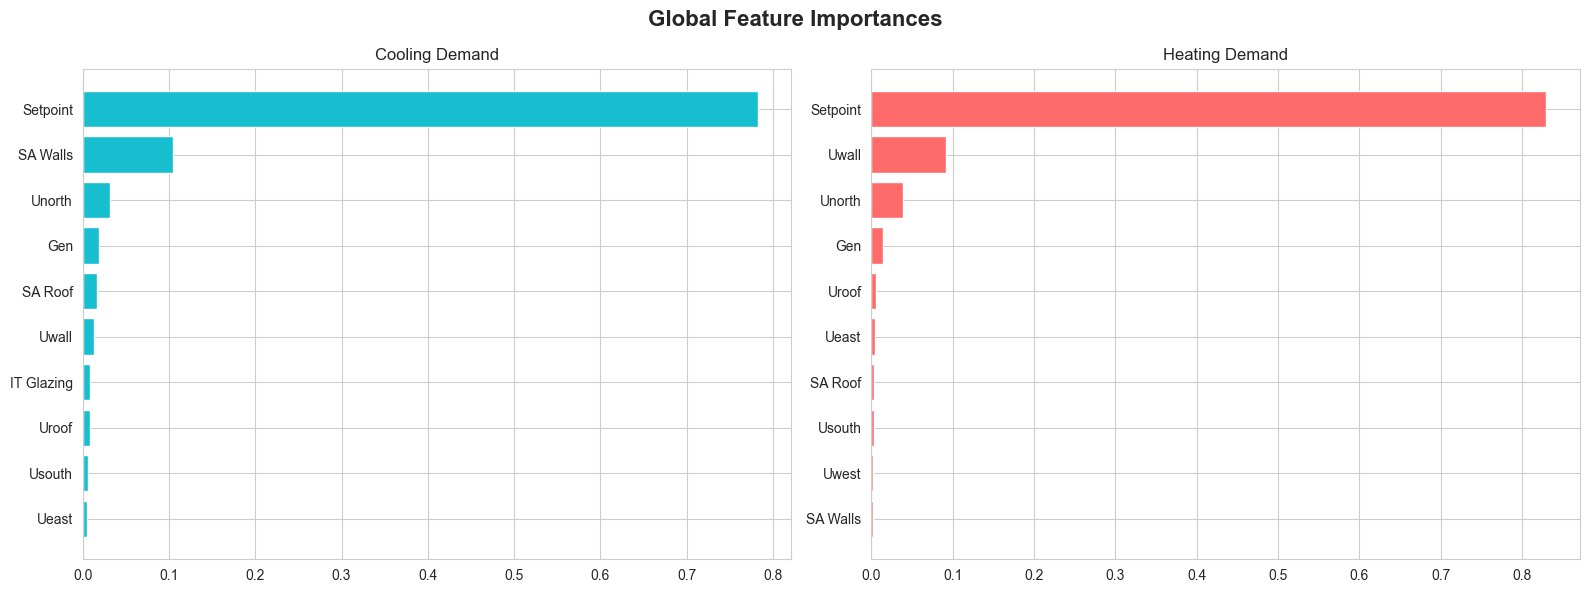

In [44]:
importance_cooling = model_cooling.named_steps['rf'].feature_importances_
importance_heating = model_heating.named_steps['rf'].feature_importances_

top_n = 10
top_cooling_idx = np.argsort(importance_cooling)[::-1][:top_n]
top_heating_idx = np.argsort(importance_heating)[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Global Feature Importances', fontsize=16, fontweight='bold')

# Cooling
axes[0].barh(range(top_n), importance_cooling[top_cooling_idx], color=color_cooling)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([features_without_shape[i] for i in top_cooling_idx])
axes[0].invert_yaxis()
axes[0].set_title("Cooling Demand")

# Heating
axes[1].barh(range(top_n), importance_heating[top_heating_idx], color=color_heating)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([features_without_shape[i] for i in top_heating_idx])
axes[1].invert_yaxis()
axes[1].set_title("Heating Demand")

plt.tight_layout()
plt.show()

The bar charts show global feature importances, computed across the entire dataset, combining both H and Linear buildings. For cooling demand, Setpoint is by far the most important feature, followed by SA Walls, indicating that indoor temperature settings and wall solar absorptance dominate cooling performance. For heating demand, Setpoint again dominates, with Uwall as the second most influential factor, highlighting that insulation quality strongly affects winter energy use.

These importances are model-level (global) because they reflect the average contribution of each feature across all samples, regardless of building shape. The feature_importances_ attribute from Random Forest is calculated during training based on mean reduction in impurity (Gini or variance) across all trees and data points. Since it’s derived from the full model, it does not vary by subset (H vs L) unless retrained separately.

Setpoint is critical for both cooling and heating — confirming its role as a key operational lever. Wall properties (SA Walls, Uwall) are major physical drivers, especially in cooling. Global importance gives a holistic picture.

### Permutation importance by building

In [45]:
# Subsets
X_test_H = X_test.loc[X_test.index.intersection(H_buildings.index)]
X_test_L = X_test.loc[X_test.index.intersection(L_buildings.index)]

# Define corresponding target variables for subsets
y_cooling_test_H = y_cooling_test.loc[y_cooling_test.index.intersection(H_buildings.index)]
y_cooling_test_L = y_cooling_test.loc[y_cooling_test.index.intersection(L_buildings.index)]
y_heating_test_H = y_heating_test.loc[y_heating_test.index.intersection(H_buildings.index)]
y_heating_test_L = y_heating_test.loc[y_heating_test.index.intersection(L_buildings.index)]

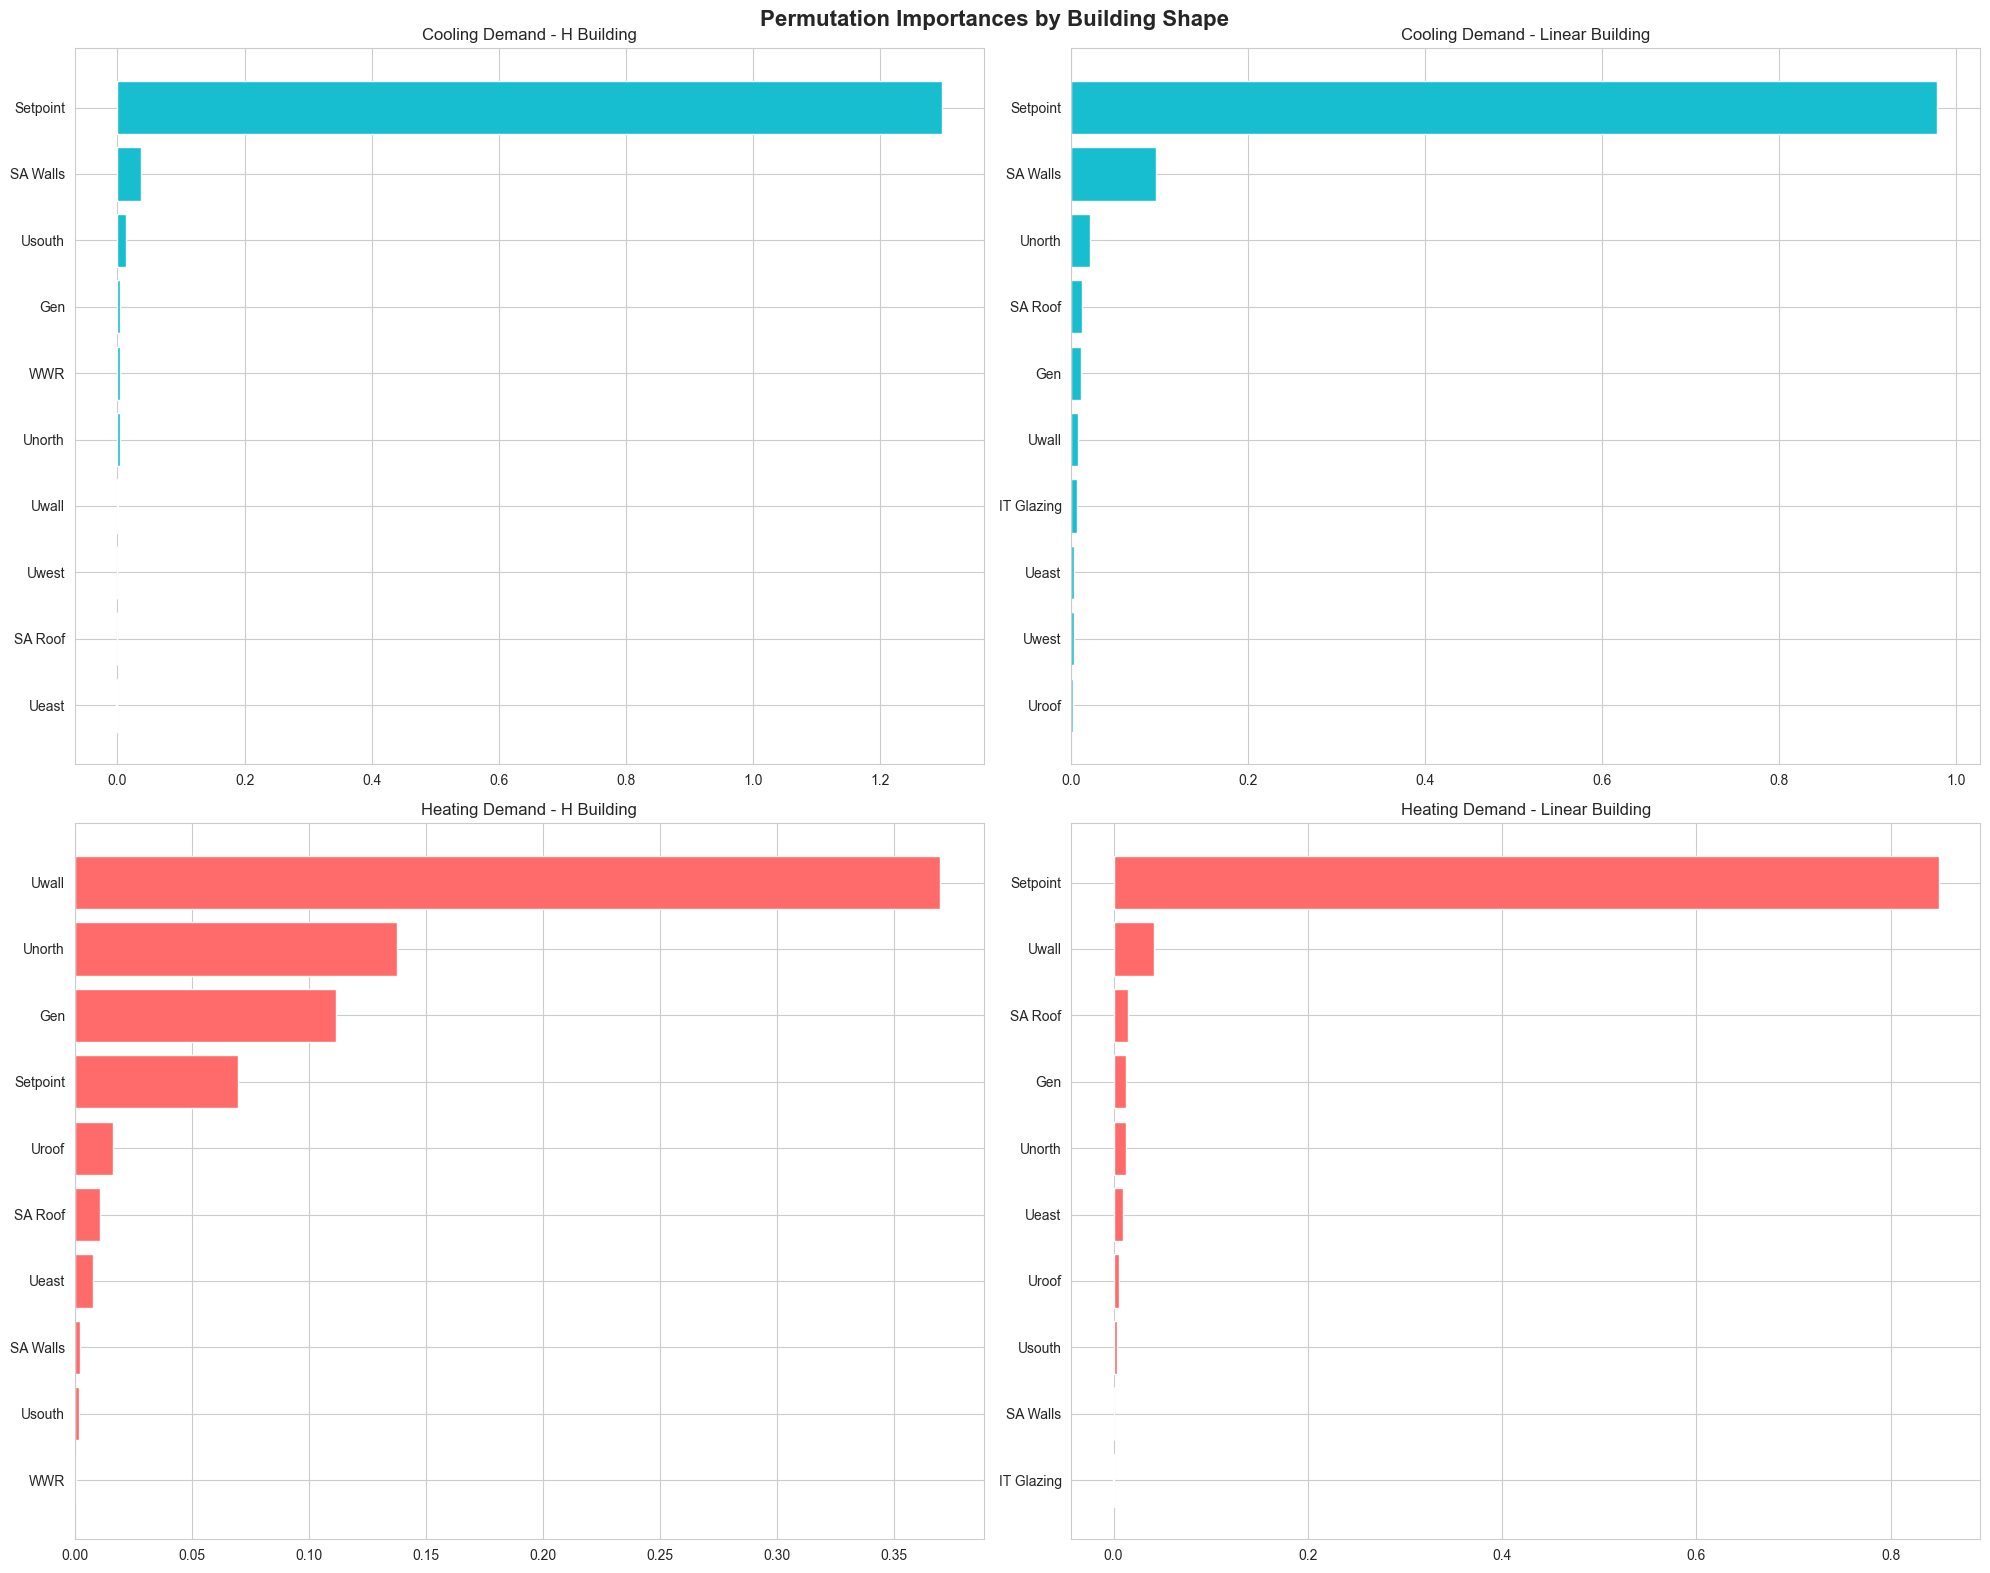

In [46]:
def get_perm_importance(model, X, y, top_n=10):
    perm = permutation_importance(model, X, y, n_repeats=20, random_state=42, n_jobs=-1)
    idx = np.argsort(perm.importances_mean)[::-1][:top_n]
    return perm.importances_mean[idx], [features_without_shape[i] for i in idx]

# Cooling
imp_cool_H, feat_cool_H = get_perm_importance(model_cooling, X_test_H, y_cooling_test_H)
imp_cool_L, feat_cool_L = get_perm_importance(model_cooling, X_test_L, y_cooling_test_L)

# Heating
imp_heat_H, feat_heat_H = get_perm_importance(model_heating, X_test_H, y_heating_test_H)
imp_heat_L, feat_heat_L = get_perm_importance(model_heating, X_test_L, y_heating_test_L)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Permutation Importances by Building Shape', fontsize=16, fontweight='bold')

# Cooling H
axes[0,0].barh(range(len(imp_cool_H)), imp_cool_H, color=color_cooling)
axes[0,0].set_yticks(range(len(imp_cool_H)))
axes[0,0].set_yticklabels(feat_cool_H)
axes[0,0].invert_yaxis()
axes[0,0].set_title("Cooling Demand - H Building")

# Cooling L
axes[0,1].barh(range(len(imp_cool_L)), imp_cool_L, color=color_cooling)
axes[0,1].set_yticks(range(len(imp_cool_L)))
axes[0,1].set_yticklabels(feat_cool_L)
axes[0,1].invert_yaxis()
axes[0,1].set_title("Cooling Demand - Linear Building")

# Heating H
axes[1,0].barh(range(len(imp_heat_H)), imp_heat_H, color=color_heating)
axes[1,0].set_yticks(range(len(imp_heat_H)))
axes[1,0].set_yticklabels(feat_heat_H)
axes[1,0].invert_yaxis()
axes[1,0].set_title("Heating Demand - H Building")

# Heating L
axes[1,1].barh(range(len(imp_heat_L)), imp_heat_L, color=color_heating)
axes[1,1].set_yticks(range(len(imp_heat_L)))
axes[1,1].set_yticklabels(feat_heat_L)
axes[1,1].invert_yaxis()
axes[1,1].set_title("Heating Demand - Linear Building")

plt.tight_layout()
plt.show()

The bar charts show permutation importances, that measures how much prediction accuracy drops when each feature is randomly shuffled. This allows us to compute importance separately for H and Linear buildings without retraining models, making it ideal for comparing shape-specific behavior.

For cooling demand, Setpoint dominates in both shapes, but SA Walls has a stronger influence in Linear buildings, suggesting that solar absorptance plays a more critical role in their thermal performance. For heating demand, Uwall is the top driver in H buildings (0.37), while Setpoint leads in Linear ones (0.85), indicating that insulation matters more in H building due to higher surface area and heat loss.

Using Permutation Importances: unlike feature_importances_, which is fixed at training time and global across all data, permutation importance can be computed on any subset (H vs L) using the same trained model. This enables local, context-aware insights, revealing how features matter differently based on building geometry, without the need to train separate models. 

## SHAP Analysis

SHAP (SHapley Additive exPlanations) is a method to explain how each feature contributes to a machine learning model’s predictions. To interpret the machine learning models, we applied SHAP, a game-theory–based method that attributes model predictions to individual features. SHAP values quantify both the magnitude and direction of each feature’s effect on heating and cooling demand. Positive values indicate increases in energy demand, while negative values represent reductions.

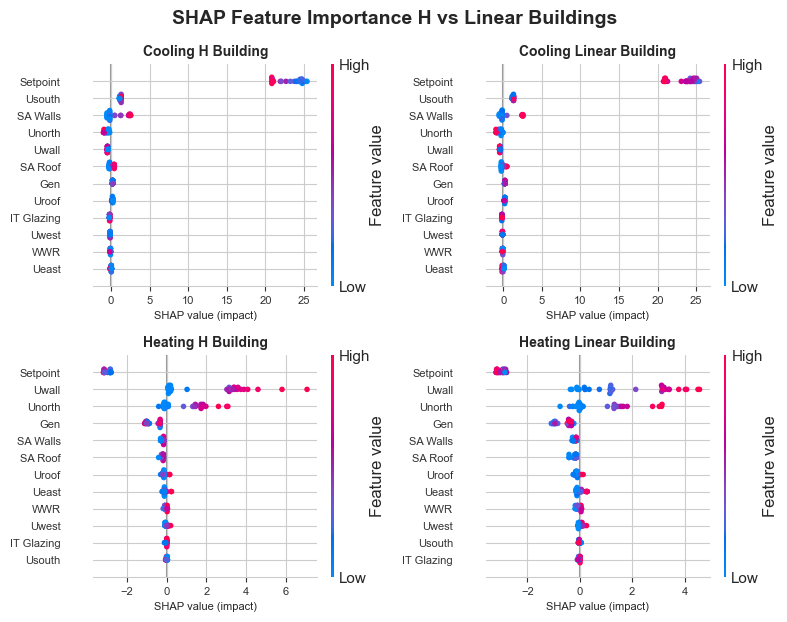

In [47]:
# Feature list (excluding "Shape")
feature_names = features_without_shape

# Explainers
explainer_cooling = shap.TreeExplainer(model_cooling.named_steps['rf'])
explainer_heating = shap.TreeExplainer(model_heating.named_steps['rf'])

# SHAP values
shap_cool_H = explainer_cooling.shap_values(X_test_H)
shap_cool_L = explainer_cooling.shap_values(X_test_L)
shap_heat_H = explainer_heating.shap_values(X_test_H)
shap_heat_L = explainer_heating.shap_values(X_test_L)

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("SHAP Feature Importance H vs Linear Buildings", fontsize=14, fontweight="bold")

def small_summary_plot(shap_values, X, feature_names, color, ax, title):
    plt.sca(ax)
    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        plot_type="dot",
        color=color,
        show=False
    )
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("SHAP value (impact)", fontsize=8)

# Cooling – H vs L
small_summary_plot(shap_cool_H, X_test_H, feature_names, color_cooling, axes[0,0], "Cooling H Building")
small_summary_plot(shap_cool_L, X_test_L, feature_names, color_cooling, axes[0,1], "Cooling Linear Building")

# Heating – H vs L
small_summary_plot(shap_heat_H, X_test_H, feature_names, color_heating, axes[1,0], "Heating H Building")
small_summary_plot(shap_heat_L, X_test_L, feature_names, color_heating, axes[1,1], "Heating Linear Building")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


SHAP reveals that while Setpoint is universally important, building shape changes how physical parameters matter:
H buildings are driven by envelope performance (insulation, absorptance).
Linear buildings are driven by operational control (setpoint), with weaker dependence on insulation.
This supports shape-specific design strategies, optimizing insulation in H buildings and focusing on thermal comfort control in Linear forms.

In this analysis, SHAP values are employed to uncover the building-shape-specific drivers of cooling and heating energy demand in H buildings and Linear buildings, revealing distinct behavioral patterns rooted in architectural form. For H buildings, cooling demand is predominantly influenced by operational setpoints and south-facing thermal transmittance (Usouth), indicating that solar exposure and indoor temperature settings are primary contributors to heat gain, while heating demand is overwhelmingly governed by wall insulation performance (Uwall), with secondary contributions from roof and north-facing envelope properties, underscoring the critical role of passive design strategies in mitigating winter heat loss. In contrast, Linear buildings exhibit a stronger dependence on operational parameters, with setpoint emerging as the dominant factor for both cooling and heating demands, while physical envelope characteristics such as wall insulation (Uwall) and solar absorptance (SA Walls) play a secondary, still significant, role, suggesting that energy performance in Linear forms is more responsive to occupant behavior and control than to passive architectural interventions. These findings highlight that building geometry fundamentally reshapes the hierarchy of energy drivers: H buildings benefit most from optimizing envelope performance, whereas Linear buildings achieve greater efficiency through thermal setpoint management, reinforcing the necessity of shape-sensitive, context-aware design guidelines in energy-efficient architecture.

# Sensitivity Analysis: Cooling and Heating Trends vs RF Model (H vs Linear Building)

In [55]:
# Create dataframe with test data and predictions
shape_col = optimizations['Shape']
df_test = X_test.copy()
df_test["Shape"] = shape_col.loc[X_test.index]
df_test["Cooling_Test"] = y_cooling_test
df_test["Cooling_Pred"] = y_cooling_pred
df_test["Heating_Test"] = y_heating_test
df_test["Heating_Pred"] = y_heating_pred

In [56]:
df_test

,Gen,WWR,Unorth,Usouth,Ueast,Uwest,Uwall,Uroof,SA Walls,SA Roof,IT Glazing,Setpoint,Shape,Cooling_Test,Cooling_Pred,Heating_Test,Heating_Pred
167,12.0,0.10,1.22,1.17,1.13,1.28,1.20,0.32,0.20,0.36,0.007,21.64,L,27.54,30.8970,6.70,8.0261
230,30.0,0.15,0.31,0.28,0.29,0.28,0.29,0.27,0.72,0.75,0.008,22.83,L,44.96,43.7065,0.18,0.2438
25,25.0,0.10,0.90,0.50,0.94,1.36,1.14,0.82,0.22,0.25,0.004,22.12,H,32.53,31.1927,7.34,6.2909
63,20.0,0.15,1.34,0.67,0.53,0.79,1.00,2.28,0.22,0.21,0.004,21.90,H,30.94,31.0535,10.51,9.0188
9,9.0,0.10,1.25,0.70,0.98,1.17,1.25,0.77,0.23,0.25,0.003,21.64,H,32.04,28.6409,8.07,10.0786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,31.0,0.20,0.30,0.30,0.27,0.35,0.37,0.30,0.69,0.74,0.010,24.51,H,60.55,60.5233,0.69,0.7012
210,10.0,0.15,0.86,1.10,1.97,1.58,1.16,1.47,0.21,0.21,0.003,21.39,L,25.89,28.0031,9.21,10.6914
148,33.0,0.25,1.49,0.57,1.13,0.40,1.08,1.36,0.20,0.29,0.005,22.08,H,30.07,30.1486,15.12,13.4492
309,26.0,0.25,0.31,0.56,0.36,0.52,0.44,0.35,0.39,0.36,0.007,22.34,L,34.99,35.9686,1.41,1.0626


In [54]:
y_cooling_test

167    27.54
230    44.96
25     32.53
63     30.94
9      32.04
       ...  
114    60.55
210    25.89
148    30.07
309    34.99
258    28.98
Name: Cooling demand, Length: 64, dtype: float64

In [61]:
y_heating_test

167     6.70
230     0.18
25      7.34
63     10.51
9       8.07
       ...  
114     0.69
210     9.21
148    15.12
309     1.41
258     4.05
Name: Heating demand, Length: 64, dtype: float64

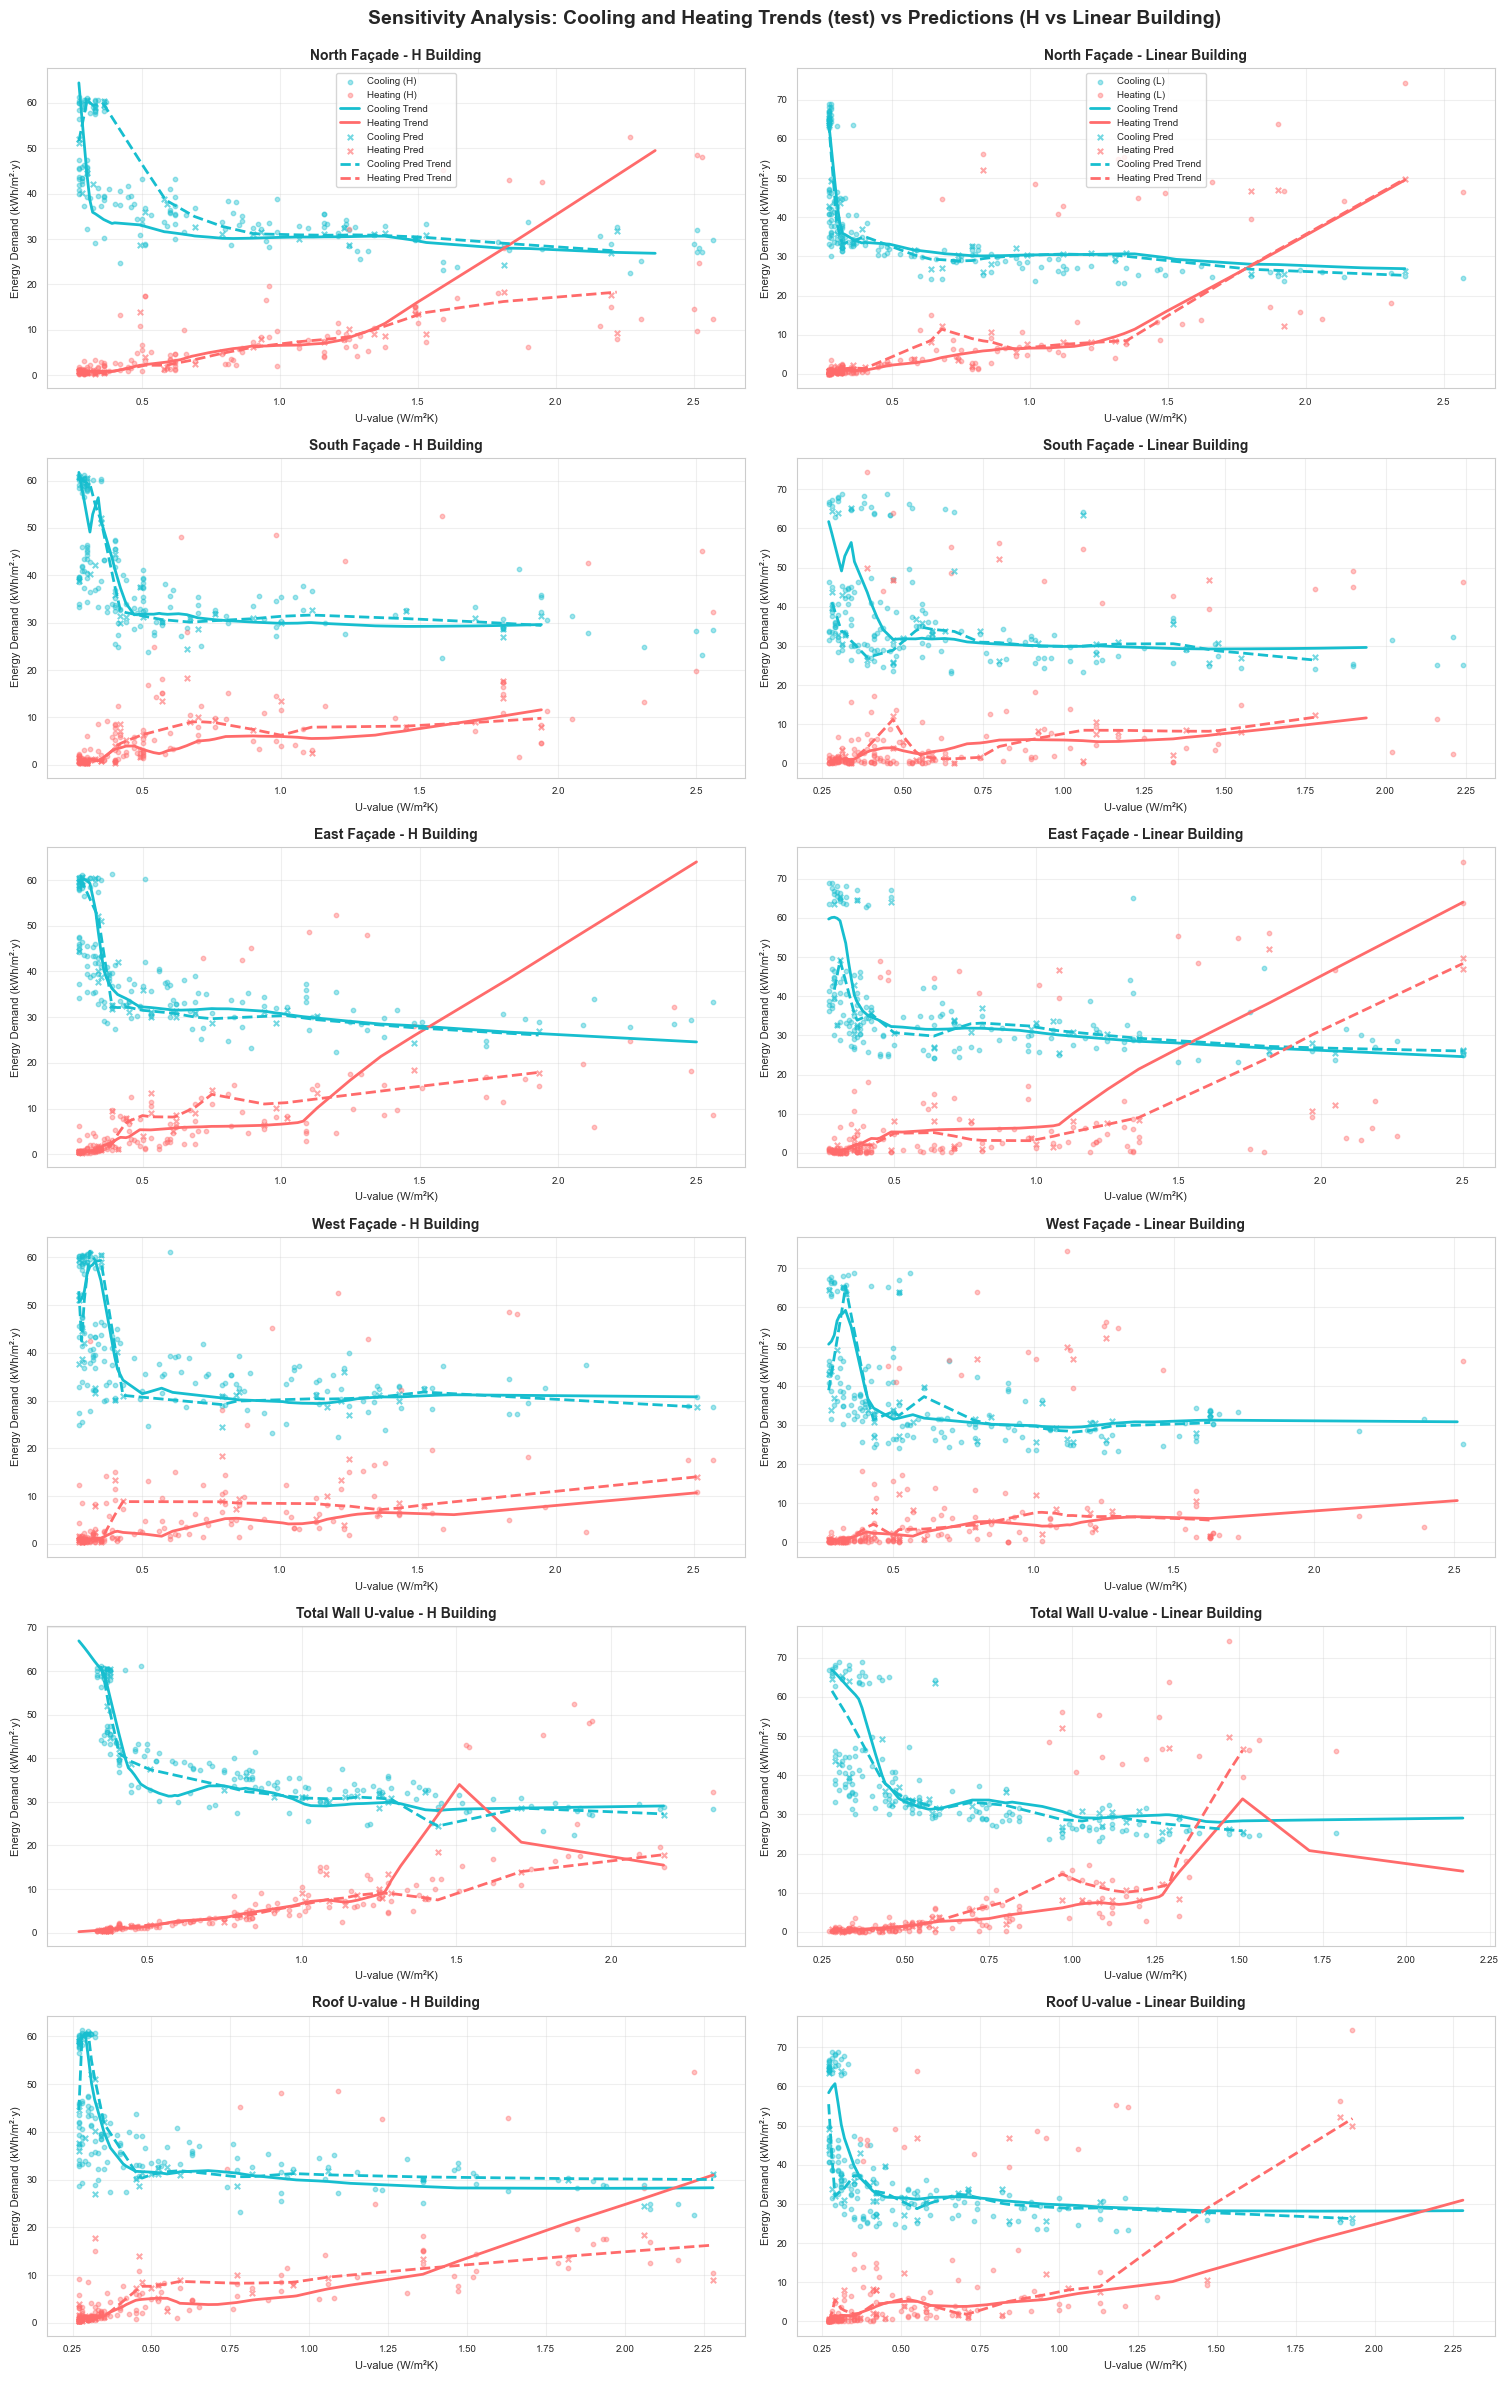

In [62]:
# Uvalues
variables = ['Unorth', 'Usouth', 'Ueast', 'Uwest', 'Uwall', 'Uroof']
titles = [
    'North Façade',
    'South Façade',
    'East Façade',
    'West Façade',
    'Total Wall U-value',
    'Roof U-value'
]

# Grid 2 columns = total of 12 graphics
fig, axes = plt.subplots(6, 2, figsize=(16, 24))
axes = axes.ravel()

for i, (var, title) in enumerate(zip(variables, titles)):

    # H building
    ax_H = axes[2*i]
    


    # Cooling and Heating division
    uvalue = X_test[var].values 
    cool = y_cooling_test.values # series
    heat = y_heating_test.values
 
    lowess_cool = lowess(cool, uvalue, frac=0.3)
    lowess_heat = lowess(heat, uvalue, frac=0.3)
    
    # Scatter H Building
    ax_H.scatter(H_buildings[var], H_buildings['Cooling demand'],
                 color=color_cooling, alpha=0.4, s=10, label="Cooling (H)")
    ax_H.scatter(H_buildings[var], H_buildings['Heating demand'],
                 color=color_heating, alpha=0.4, s=10, label="Heating (H)")

    # LOWESS H building
    ax_H.plot(lowess_cool[:, 0], lowess_cool[:, 1],
              color=color_cooling, linewidth=2, label="Cooling Trend")
    ax_H.plot(lowess_heat[:, 0], lowess_heat[:, 1],
              color=color_heating, linewidth=2, label="Heating Trend")

    # Add predicted values for H buildings
    H_test_data = df_test[df_test["Shape"] == "H"]
    if len(H_test_data) > 0:
        ax_H.scatter(H_test_data[var], H_test_data["Cooling_Pred"],
                     marker="x", color=color_cooling, alpha=0.6, s=15, label="Cooling Pred")
        ax_H.scatter(H_test_data[var], H_test_data["Heating_Pred"],
                     marker="x", color=color_heating, alpha=0.6, s=15, label="Heating Pred")
        
        # LOWESS for predictions
        if len(H_test_data) > 10: 
            lowess_cool_pred = lowess(H_test_data["Cooling_Pred"], H_test_data[var], frac=0.3)
            lowess_heat_pred = lowess(H_test_data["Heating_Pred"], H_test_data[var], frac=0.3)
            ax_H.plot(lowess_cool_pred[:, 0], lowess_cool_pred[:, 1], 
                      color=color_cooling, linestyle="--", linewidth=2, label="Cooling Pred Trend")
            ax_H.plot(lowess_heat_pred[:, 0], lowess_heat_pred[:, 1], 
                      color=color_heating, linestyle="--", linewidth=2, label="Heating Pred Trend")

    ax_H.set_title(f"{title} - H Building", fontsize=10, fontweight="bold")
    ax_H.set_xlabel("U-value (W/m²K)", fontsize=8)
    ax_H.set_ylabel("Energy Demand (kWh/m²·y)", fontsize=8)
    ax_H.grid(True, alpha=0.3)
    ax_H.tick_params(axis='both', labelsize=7)
    if i == 0:
        ax_H.legend(fontsize=7)   

    # Linear building 
    ax_L = axes[2*i + 1]
    
    # Scatter Linear Building
    ax_L.scatter(L_buildings[var], L_buildings['Cooling demand'],
                 color=color_cooling, alpha=0.4, s=10, label="Cooling (L)")
    ax_L.scatter(L_buildings[var], L_buildings['Heating demand'],
                 color=color_heating, alpha=0.4, s=10, label="Heating (L)")

    # LOWESS Linear Building
    ax_L.plot(lowess_cool[:, 0], lowess_cool[:, 1],
              color=color_cooling, linewidth=2, label="Cooling Trend")
    ax_L.plot(lowess_heat[:, 0], lowess_heat[:, 1],
              color=color_heating, linewidth=2, label="Heating Trend")

    # Add predicted values for L buildings
    L_test_data = df_test[df_test["Shape"] == "L"]
    if len(L_test_data) > 0:
        ax_L.scatter(L_test_data[var], L_test_data["Cooling_Pred"],
                     marker="x", color=color_cooling, alpha=0.6, s=15, label="Cooling Pred")
        ax_L.scatter(L_test_data[var], L_test_data["Heating_Pred"],
                     marker="x", color=color_heating, alpha=0.6, s=15, label="Heating Pred")
        
        # LOWESS for predictions
        if len(L_test_data) > 10:  
            lowess_cool_pred = lowess(L_test_data["Cooling_Pred"], L_test_data[var], frac=0.3)
            lowess_heat_pred = lowess(L_test_data["Heating_Pred"], L_test_data[var], frac=0.3)
            ax_L.plot(lowess_cool_pred[:, 0], lowess_cool_pred[:, 1], 
                      color=color_cooling, linestyle="--", linewidth=2, label="Cooling Pred Trend")
            ax_L.plot(lowess_heat_pred[:, 0], lowess_heat_pred[:, 1], 
                      color=color_heating, linestyle="--", linewidth=2, label="Heating Pred Trend")

    ax_L.set_title(f"{title} - Linear Building", fontsize=10, fontweight="bold")
    ax_L.set_xlabel("U-value (W/m²K)", fontsize=8)
    ax_L.set_ylabel("Energy Demand (kWh/m²·y)", fontsize=8)
    ax_L.grid(True, alpha=0.3)
    ax_L.tick_params(axis='both', labelsize=7)
    if i == 0:
        ax_L.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.suptitle("Sensitivity Analysis: Cooling and Heating Trends (test) vs Predictions (H vs Linear Building)",
             fontsize=14, fontweight="bold", y=0.99)
plt.show()